# Artifact-Controlled Validation for Malicious QR-Code Detection

### This notebook constructs a balanced artifact-controlled subset from the original test set and reevaluates the previously trained TabNet and MobileNetV2 models without retraining. Benign and malicious samples are matched according to payload length, character composition, QR version, error-correction level, image resolution, and available generator-related properties.

In [2]:
# ============================================================
# 1) FAST COLAB SETUP, IMPORTS, PATHS, AND REPRODUCIBILITY
# ============================================================

# zxing-cpp provides fast QR decoding and may expose more QR
# information than OpenCV for artifact inspection.
!python -m pip install -q zxing-cpp tqdm

# ------------------------------------------------------------
# Standard libraries
# ------------------------------------------------------------
import os
import gc
import re
import json
import time
import random
import warnings
from pathlib import Path

# Reduce TensorFlow console messages
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["PYTHONHASHSEED"] = "42"

# ------------------------------------------------------------
# Data and image libraries
# ------------------------------------------------------------
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import zxingcpp

from PIL import Image
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Machine-learning utilities
# ------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# ------------------------------------------------------------
# General settings
# ------------------------------------------------------------
warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

plt.rcParams["figure.figsize"] = (8, 5)

# ------------------------------------------------------------
# GPU configuration
# ------------------------------------------------------------
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass

    # Useful later during MobileNetV2 inference
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")

# ------------------------------------------------------------
# Project directories
# ------------------------------------------------------------
BASE_DIR = Path("/content/qr_project")
DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
MODELS_DIR = BASE_DIR / "saved_models"

CONTROLLED_DIR = RESULTS_DIR / "artifact_controlled_validation"
TABLES_DIR = CONTROLLED_DIR / "tables"
PLOTS_DIR = CONTROLLED_DIR / "plots"
PREDICTIONS_DIR = CONTROLLED_DIR / "predictions"
CACHE_DIR = CONTROLLED_DIR / "cache"

for folder in [
    BASE_DIR,
    DATA_DIR,
    RESULTS_DIR,
    MODELS_DIR,
    CONTROLLED_DIR,
    TABLES_DIR,
    PLOTS_DIR,
    PREDICTIONS_DIR,
    CACHE_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Fast-processing configuration
# ------------------------------------------------------------
VALID_EXTENSIONS = {
    ".png", ".jpg", ".jpeg", ".bmp", ".webp"
}

# Process the original test set only
TARGET_SPLIT = "test"

# Number of images processed together during model inference
INFERENCE_BATCH_SIZE = 512

# Number of CPU workers used by TensorFlow input pipelines
AUTOTUNE = tf.data.AUTOTUNE

# Matching seed
MATCHING_SEED = 42

# Malicious QR codes are treated as the positive class
POSITIVE_CLASS = 1
POSITIVE_CLASS_NAME = "malicious"

# ------------------------------------------------------------
# Environment summary
# ------------------------------------------------------------
print("=" * 70)
print("ARTIFACT-CONTROLLED VALIDATION ENVIRONMENT")
print("=" * 70)

print("TensorFlow version       :", tf.__version__)
print("OpenCV version           :", cv2.__version__)
print("Pandas version           :", pd.__version__)
print("GPU available            :", bool(gpus))
print("GPU devices              :", gpus)

if gpus:
    print(
        "Mixed precision policy  :",
        tf.keras.mixed_precision.global_policy()
    )

print("\nProject paths")
print("BASE_DIR                 :", BASE_DIR)
print("DATA_DIR                 :", DATA_DIR)
print("RESULTS_DIR              :", RESULTS_DIR)
print("MODELS_DIR               :", MODELS_DIR)
print("CONTROLLED_DIR           :", CONTROLLED_DIR)
print("CACHE_DIR                :", CACHE_DIR)

print("\nEvaluation configuration")
print("Target split             :", TARGET_SPLIT)
print("Positive class           :", POSITIVE_CLASS_NAME)
print("Inference batch size     :", INFERENCE_BATCH_SIZE)
print("Random seed              :", SEED)

print("\nSetup completed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 51.8 MB/s eta 0:00:00
ARTIFACT-CONTROLLED VALIDATION ENVIRONMENT
TensorFlow version       : 2.20.0
OpenCV version           : 4.13.0
Pandas version           : 2.2.2
GPU available            : True
GPU devices              : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy  : <DTypePolicy "mixed_float16">

Project paths
BASE_DIR                 : /content/qr_project
DATA_DIR                 : /content/qr_project/data
RESULTS_DIR              : /content/qr_project/results
MODELS_DIR               : /content/qr_project/saved_models
CONTROLLED_DIR           : /content/qr_project/results/artifact_controlled_validation
CACHE_DIR                : /content/qr_project/results/artifact_controlled_validation/cache

Evaluation configuration
Target split             : test
Positive class           : malicious
Inference batch size     : 512
Random seed              : 42

Setup completed successfully.


## 2. Load the Original Dataset and Fixed Test Split

The artifact-controlled subset must be constructed exclusively from the original test partition. This preserves independence from model training and ensures direct comparability with the previously reported test results.

In [3]:
# ============================================================
# 2) MOUNT DRIVE, LOCATE DATA, AND LOAD THE FIXED TEST SPLIT
# ============================================================

from google.colab import drive
import zipfile
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Mount Google Drive
# ------------------------------------------------------------
drive.mount("/content/drive")

# Change this only if the ZIP file has a different name/path.
ZIP_PATH = Path(
    "/content/drive/MyDrive/Benign and Malicious QR codes.zip"
)

EXTRACT_DIR = DATA_DIR

# Original metadata and split files
METADATA_CSV = RESULTS_DIR / "qr_dataset_paths_labels.csv"
CLEAN_METADATA_CSV = RESULTS_DIR / "cleaned_qr_metadata.csv"

TRAIN_CSV = RESULTS_DIR / "train.csv"
VAL_CSV = RESULTS_DIR / "val.csv"
TEST_CSV = RESULTS_DIR / "test.csv"

# ------------------------------------------------------------
# Helper: count image files
# ------------------------------------------------------------
def count_images(root):
    root = Path(root)

    if not root.exists():
        return 0

    return sum(
        1
        for path in root.rglob("*")
        if path.is_file()
        and path.suffix.lower() in VALID_EXTENSIONS
    )


# ------------------------------------------------------------
# Extract only when the dataset is not already available
# ------------------------------------------------------------
existing_image_count = count_images(EXTRACT_DIR)

if existing_image_count > 0:
    print(
        f"Dataset already extracted: "
        f"{existing_image_count:,} images found."
    )

else:
    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            "Dataset ZIP was not found.\n"
            f"Expected path: {ZIP_PATH}\n"
            "Edit ZIP_PATH if the file has another name."
        )

    print("Extracting dataset ZIP...")

    start_time = time.perf_counter()

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    extraction_time = time.perf_counter() - start_time
    existing_image_count = count_images(EXTRACT_DIR)

    print(
        f"Extraction completed in "
        f"{extraction_time:.2f} seconds."
    )
    print(
        f"Images discovered: "
        f"{existing_image_count:,}"
    )


# ------------------------------------------------------------
# Find benign and malicious folders automatically
# ------------------------------------------------------------
def find_class_folders(root):
    benign_folders = []
    malicious_folders = []

    benign_terms = {
        "benign",
        "normal",
        "legitimate",
        "legit",
        "safe"
    }

    malicious_terms = {
        "malicious",
        "malware",
        "phishing",
        "attack"
    }

    for folder in Path(root).rglob("*"):
        if not folder.is_dir():
            continue

        folder_name = folder.name.lower().strip()

        if folder_name in benign_terms:
            benign_folders.append(folder)

        if folder_name in malicious_terms:
            malicious_folders.append(folder)

    return benign_folders, malicious_folders


benign_folders, malicious_folders = find_class_folders(
    EXTRACT_DIR
)

print("\nDetected class folders")

print("Benign folders:")
for folder in benign_folders:
    print(" -", folder)

print("Malicious folders:")
for folder in malicious_folders:
    print(" -", folder)

if not benign_folders:
    raise FileNotFoundError(
        "No benign image folder was detected."
    )

if not malicious_folders:
    raise FileNotFoundError(
        "No malicious image folder was detected."
    )


# ------------------------------------------------------------
# Build metadata only when an existing file is unavailable
# ------------------------------------------------------------
def collect_images(folders, label_name):
    rows = []

    for folder in folders:
        for image_path in folder.rglob("*"):
            if (
                image_path.is_file()
                and image_path.suffix.lower()
                in VALID_EXTENSIONS
            ):
                rows.append(
                    {
                        "image_path": str(image_path),
                        "label": label_name
                    }
                )

    return rows


if CLEAN_METADATA_CSV.exists():
    print(
        "\nLoading cleaned metadata:",
        CLEAN_METADATA_CSV
    )

    full_df = pd.read_csv(CLEAN_METADATA_CSV)

elif METADATA_CSV.exists():
    print(
        "\nLoading original metadata:",
        METADATA_CSV
    )

    full_df = pd.read_csv(METADATA_CSV)

else:
    print(
        "\nNo metadata file was found. "
        "Building metadata from image folders..."
    )

    rows = []

    rows.extend(
        collect_images(
            benign_folders,
            "benign"
        )
    )

    rows.extend(
        collect_images(
            malicious_folders,
            "malicious"
        )
    )

    full_df = pd.DataFrame(rows)

    full_df.to_csv(
        METADATA_CSV,
        index=False
    )

    print(
        "Metadata saved to:",
        METADATA_CSV
    )


# ------------------------------------------------------------
# Standardize metadata columns
# ------------------------------------------------------------
if "image_path" in full_df.columns:
    PATH_COLUMN = "image_path"

elif "image" in full_df.columns:
    PATH_COLUMN = "image"
    full_df = full_df.rename(
        columns={"image": "image_path"}
    )
    PATH_COLUMN = "image_path"

else:
    raise KeyError(
        "No image-path column was found. "
        "Expected 'image_path' or 'image'."
    )


if "label" not in full_df.columns:
    raise KeyError(
        "The metadata must contain a 'label' column."
    )


# Normalize labels
full_df["label"] = (
    full_df["label"]
    .astype(str)
    .str.lower()
    .str.strip()
)

label_mapping = {
    "benign": 0,
    "normal": 0,
    "legitimate": 0,
    "legit": 0,
    "safe": 0,
    "0": 0,

    "malicious": 1,
    "malware": 1,
    "phishing": 1,
    "attack": 1,
    "1": 1
}

full_df["label_id"] = (
    full_df["label"]
    .map(label_mapping)
)

# Remove invalid rows
full_df = full_df[
    full_df["label_id"].notna()
].copy()

full_df["label_id"] = (
    full_df["label_id"]
    .astype(int)
)

full_df["image_path"] = (
    full_df["image_path"]
    .astype(str)
)

full_df = (
    full_df
    .dropna(subset=["image_path"])
    .drop_duplicates(subset=["image_path"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Load the exact original test split
# ------------------------------------------------------------
if TEST_CSV.exists():
    print(
        "\nLoading existing fixed test split:",
        TEST_CSV
    )

    test_df = pd.read_csv(TEST_CSV)

    if "image" in test_df.columns:
        test_df = test_df.rename(
            columns={"image": "image_path"}
        )

    if "label_id" not in test_df.columns:
        test_df["label"] = (
            test_df["label"]
            .astype(str)
            .str.lower()
            .str.strip()
        )

        test_df["label_id"] = (
            test_df["label"]
            .map(label_mapping)
            .astype(int)
        )

else:
    print(
        "\nExisting split files were not found."
    )
    print(
        "Reconstructing the original stratified "
        "70/15/15 split using seed 42."
    )

    train_df, temp_df = train_test_split(
        full_df,
        test_size=0.30,
        random_state=SEED,
        stratify=full_df["label_id"]
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=SEED,
        stratify=temp_df["label_id"]
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    train_df.to_csv(TRAIN_CSV, index=False)
    val_df.to_csv(VAL_CSV, index=False)
    test_df.to_csv(TEST_CSV, index=False)

    print("Split files created and saved.")


# ------------------------------------------------------------
# Repair paths only when extracted directory changed
# ------------------------------------------------------------
def repair_image_path(old_path):
    old_path = Path(str(old_path))

    if old_path.exists():
        return str(old_path)

    # Search using filename only.
    matches = list(
        EXTRACT_DIR.rglob(old_path.name)
    )

    if len(matches) == 1:
        return str(matches[0])

    return str(old_path)


path_exists = test_df["image_path"].map(
    os.path.exists
)

missing_before = int(
    (~path_exists).sum()
)

if missing_before > 0:
    print(
        f"\nRepairing {missing_before:,} "
        "missing test image paths..."
    )

    test_df["image_path"] = (
        test_df["image_path"]
        .map(repair_image_path)
    )


# ------------------------------------------------------------
# Keep valid test records
# ------------------------------------------------------------
test_df["path_exists"] = (
    test_df["image_path"]
    .map(os.path.exists)
)

missing_after = int(
    (~test_df["path_exists"]).sum()
)

if missing_after > 0:
    print(
        f"Warning: {missing_after:,} test paths "
        "remain unavailable."
    )

test_df = (
    test_df[
        test_df["path_exists"]
    ]
    .drop(columns=["path_exists"])
    .reset_index(drop=True)
)


# Ensure normalized labels
if "label" not in test_df.columns:
    test_df["label"] = test_df["label_id"].map(
        {
            0: "benign",
            1: "malicious"
        }
    )

test_df["label_id"] = (
    test_df["label_id"]
    .astype(int)
)


# ------------------------------------------------------------
# Assign stable sample identifiers
# ------------------------------------------------------------
test_df["sample_id"] = [
    f"test_{index:05d}"
    for index in range(len(test_df))
]


# ------------------------------------------------------------
# Save the verified test manifest
# ------------------------------------------------------------
VERIFIED_TEST_CSV = (
    CACHE_DIR
    / "verified_original_test_split.csv"
)

test_df.to_csv(
    VERIFIED_TEST_CSV,
    index=False
)


# ------------------------------------------------------------
# Verification summary
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("ORIGINAL TEST SPLIT VERIFICATION")
print("=" * 70)

print(
    "Full metadata samples :",
    f"{len(full_df):,}"
)

print(
    "Test samples retained :",
    f"{len(test_df):,}"
)

print(
    "\nTest class distribution:"
)

print(
    test_df["label"]
    .value_counts()
    .to_string()
)

print(
    "\nNumeric label distribution:"
)

print(
    test_df["label_id"]
    .value_counts()
    .sort_index()
    .to_string()
)

print(
    "\nAll test paths valid  :",
    test_df["image_path"]
    .map(os.path.exists)
    .all()
)

print(
    "Duplicate test paths  :",
    test_df["image_path"]
    .duplicated()
    .sum()
)

print(
    "Verified manifest     :",
    VERIFIED_TEST_CSV
)

print("\nFirst five records:")
display(
    test_df[
        [
            "sample_id",
            "image_path",
            "label",
            "label_id"
        ]
    ].head()
)

Mounted at /content/drive
Extracting dataset ZIP...
Extraction completed in 21.55 seconds.
Images discovered: 200,000

Detected class folders
Benign folders:
 - /content/qr_project/data/QR codes/benign
 - /content/qr_project/data/QR codes/benign/benign
Malicious folders:
 - /content/qr_project/data/QR codes/malicious
 - /content/qr_project/data/QR codes/malicious/malicious

No metadata file was found. Building metadata from image folders...
Metadata saved to: /content/qr_project/results/qr_dataset_paths_labels.csv

Existing split files were not found.
Reconstructing the original stratified 70/15/15 split using seed 42.
Split files created and saved.

ORIGINAL TEST SPLIT VERIFICATION
Full metadata samples : 200,000
Test samples retained : 30,000

Test class distribution:
label
benign       15000
malicious    15000

Numeric label distribution:
label_id
0    15000
1    15000

All test paths valid  : True
Duplicate test paths  : 0
Verified manifest     : /content/qr_project/results/artifac

,sample_id,image_path,label,label_id
0,test_00000,/content/qr_project/data/QR codes/benign/benig...,benign,0
1,test_00001,/content/qr_project/data/QR codes/benign/benig...,benign,0
2,test_00002,/content/qr_project/data/QR codes/benign/benig...,benign,0
3,test_00003,/content/qr_project/data/QR codes/benign/benig...,benign,0
4,test_00004,/content/qr_project/data/QR codes/malicious/ma...,malicious,1


## 3. Fast QR Payload and Artifact Attribute Extraction

Each test image is decoded to recover payload-related properties while preserving the original class labels. The extracted variables include payload length, character composition, image resolution, decoder status, QR format information, and error-correction metadata when exposed by the decoder. Results are cached incrementally for efficient recovery and reproducibility.

In [4]:
# ============================================================
# 3) FAST PARALLEL QR DECODING AND ARTIFACT EXTRACTION
# ============================================================

from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter
import unicodedata

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
ARTIFACT_CACHE_CSV = (
    CACHE_DIR / "test_artifact_attributes.csv"
)

CHECKPOINT_EVERY = 1000

# Threading is generally effective because image reading and
# ZXing decoding execute mostly outside Python.
MAX_WORKERS = min(
    16,
    max(4, (os.cpu_count() or 4))
)

print("Parallel workers:", MAX_WORKERS)
print("Checkpoint every:", CHECKPOINT_EVERY, "samples")
print("Artifact cache   :", ARTIFACT_CACHE_CSV)


# ------------------------------------------------------------
# Safe object-attribute reader
# ------------------------------------------------------------
def safe_attribute(obj, attribute, default=None):
    try:
        value = getattr(obj, attribute, default)

        if callable(value):
            value = value()

        return value

    except Exception:
        return default


# ------------------------------------------------------------
# Convert decoder objects to readable strings
# ------------------------------------------------------------
def clean_decoder_value(value):
    if value is None:
        return None

    try:
        text = str(value).strip()
    except Exception:
        return None

    if not text or text.lower() in {
        "none",
        "nan",
        "unknown"
    }:
        return None

    return text


# ------------------------------------------------------------
# Character-composition extraction
# ------------------------------------------------------------
def extract_character_features(payload):
    payload = "" if payload is None else str(payload)

    length = len(payload)

    digit_count = 0
    alpha_count = 0
    uppercase_count = 0
    lowercase_count = 0
    whitespace_count = 0
    punctuation_count = 0
    special_count = 0
    ascii_count = 0
    non_ascii_count = 0
    hexadecimal_count = 0

    for character in payload:
        if character.isdigit():
            digit_count += 1

        if character.isalpha():
            alpha_count += 1

        if character.isupper():
            uppercase_count += 1

        if character.islower():
            lowercase_count += 1

        if character.isspace():
            whitespace_count += 1

        if character.isascii():
            ascii_count += 1
        else:
            non_ascii_count += 1

        if character in "0123456789abcdefABCDEF":
            hexadecimal_count += 1

        category = unicodedata.category(character)

        if category.startswith("P"):
            punctuation_count += 1

        elif (
            not character.isalnum()
            and not character.isspace()
        ):
            special_count += 1

    unique_character_count = len(set(payload))

    # URL-related characters are retained because the reviewer
    # explicitly requested control of character distribution.
    url_separator_count = sum(
        payload.count(character)
        for character in "/:?&=._-%#@"
    )

    return {
        "payload_length": length,
        "digit_count": digit_count,
        "alpha_count": alpha_count,
        "uppercase_count": uppercase_count,
        "lowercase_count": lowercase_count,
        "whitespace_count": whitespace_count,
        "punctuation_count": punctuation_count,
        "special_count": special_count,
        "ascii_count": ascii_count,
        "non_ascii_count": non_ascii_count,
        "hexadecimal_count": hexadecimal_count,
        "unique_character_count": unique_character_count,
        "url_separator_count": url_separator_count,

        # Ratios allow matching across slightly different lengths.
        "digit_ratio": digit_count / max(length, 1),
        "alpha_ratio": alpha_count / max(length, 1),
        "uppercase_ratio": uppercase_count / max(length, 1),
        "lowercase_ratio": lowercase_count / max(length, 1),
        "punctuation_ratio": punctuation_count / max(length, 1),
        "special_ratio": special_count / max(length, 1),
        "url_separator_ratio": (
            url_separator_count / max(length, 1)
        )
    }


# ------------------------------------------------------------
# Optional OpenCV fallback decoder
# ------------------------------------------------------------
opencv_detector = cv2.QRCodeDetector()


def decode_with_opencv(image):
    try:
        text, points, straight = (
            opencv_detector.detectAndDecode(image)
        )

        if text:
            return text

    except Exception:
        pass

    return None


# ------------------------------------------------------------
# Decode one QR image and extract attributes
# ------------------------------------------------------------
def process_single_sample(record):
    sample_id = record["sample_id"]
    image_path = record["image_path"]
    label = record["label"]
    label_id = int(record["label_id"])

    output = {
        "sample_id": sample_id,
        "image_path": image_path,
        "label": label,
        "label_id": label_id,
        "readable": False,
        "decoded": False,
        "decoder": None,
        "payload": None,
        "width": np.nan,
        "height": np.nan,
        "channels": np.nan,
        "resolution": None,
        "barcode_format": None,
        "content_type": None,
        "symbology_identifier": None,
        "error_correction_level": None,
        "decoder_orientation": None,
        "decode_error": None
    }

    try:
        image = cv2.imread(
            image_path,
            cv2.IMREAD_UNCHANGED
        )

        if image is None:
            output["decode_error"] = "unreadable_image"
            return output

        output["readable"] = True

        height, width = image.shape[:2]
        channels = (
            1 if image.ndim == 2 else image.shape[2]
        )

        output["width"] = int(width)
        output["height"] = int(height)
        output["channels"] = int(channels)
        output["resolution"] = f"{width}x{height}"

        # Convert to grayscale for faster QR decoding.
        if image.ndim == 3:
            if channels == 4:
                gray = cv2.cvtColor(
                    image,
                    cv2.COLOR_BGRA2GRAY
                )
            else:
                gray = cv2.cvtColor(
                    image,
                    cv2.COLOR_BGR2GRAY
                )
        else:
            gray = image

        payload = None

        # ----------------------------------------------------
        # Primary decoder: ZXing-C++
        # ----------------------------------------------------
        try:
            results = zxingcpp.read_barcodes(gray)

            if results:
                result = results[0]

                payload = safe_attribute(
                    result,
                    "text",
                    None
                )

                output["barcode_format"] = (
                    clean_decoder_value(
                        safe_attribute(
                            result,
                            "format",
                            None
                        )
                    )
                )

                output["content_type"] = (
                    clean_decoder_value(
                        safe_attribute(
                            result,
                            "content_type",
                            None
                        )
                    )
                )

                output["symbology_identifier"] = (
                    clean_decoder_value(
                        safe_attribute(
                            result,
                            "symbology_identifier",
                            None
                        )
                    )
                )

                # Attribute names may vary between package versions.
                error_correction = None

                for attribute_name in [
                    "ec_level",
                    "error_correction_level",
                    "ecc_level"
                ]:
                    error_correction = safe_attribute(
                        result,
                        attribute_name,
                        None
                    )

                    if error_correction is not None:
                        break

                output["error_correction_level"] = (
                    clean_decoder_value(
                        error_correction
                    )
                )

                orientation = safe_attribute(
                    result,
                    "orientation",
                    None
                )

                output["decoder_orientation"] = (
                    clean_decoder_value(
                        orientation
                    )
                )

                if payload:
                    output["decoder"] = "zxingcpp"

        except Exception as error:
            output["decode_error"] = (
                f"zxingcpp:{type(error).__name__}"
            )

        # ----------------------------------------------------
        # Fallback decoder: OpenCV
        # ----------------------------------------------------
        if not payload:
            payload = decode_with_opencv(gray)

            if payload:
                output["decoder"] = "opencv"

        # ----------------------------------------------------
        # Save decoded payload features
        # ----------------------------------------------------
        if payload:
            payload = str(payload)

            output["decoded"] = True
            output["payload"] = payload
            output.update(
                extract_character_features(payload)
            )

        else:
            output.update(
                extract_character_features("")
            )

    except Exception as error:
        output["decode_error"] = (
            f"{type(error).__name__}: {str(error)[:100]}"
        )

    return output


# ------------------------------------------------------------
# Load previous checkpoint, when available
# ------------------------------------------------------------
if ARTIFACT_CACHE_CSV.exists():
    artifact_df = pd.read_csv(
        ARTIFACT_CACHE_CSV
    )

    completed_ids = set(
        artifact_df["sample_id"]
        .astype(str)
    )

    print(
        f"Loaded cached results for "
        f"{len(completed_ids):,} samples."
    )

else:
    artifact_df = pd.DataFrame()
    completed_ids = set()

    print("No previous artifact cache found.")


# ------------------------------------------------------------
# Select only unfinished samples
# ------------------------------------------------------------
pending_df = test_df[
    ~test_df["sample_id"]
    .astype(str)
    .isin(completed_ids)
].copy()

records = pending_df[
    [
        "sample_id",
        "image_path",
        "label",
        "label_id"
    ]
].to_dict("records")

print(
    f"Samples remaining: {len(records):,}"
)


# ------------------------------------------------------------
# Parallel execution with incremental checkpointing
# ------------------------------------------------------------
if records:
    start_time = time.perf_counter()

    new_rows = []

    with ThreadPoolExecutor(
        max_workers=MAX_WORKERS
    ) as executor:

        futures = {
            executor.submit(
                process_single_sample,
                record
            ): record["sample_id"]
            for record in records
        }

        progress_bar = tqdm(
            total=len(futures),
            desc="Extracting QR artifacts",
            unit="image"
        )

        for future in as_completed(futures):
            sample_id = futures[future]

            try:
                result = future.result()

            except Exception as error:
                result = {
                    "sample_id": sample_id,
                    "decode_error": (
                        f"worker_error:"
                        f"{type(error).__name__}"
                    )
                }

            new_rows.append(result)
            progress_bar.update(1)

            # Save checkpoint periodically.
            if len(new_rows) >= CHECKPOINT_EVERY:
                checkpoint_df = pd.DataFrame(
                    new_rows
                )

                artifact_df = pd.concat(
                    [
                        artifact_df,
                        checkpoint_df
                    ],
                    ignore_index=True
                )

                artifact_df = (
                    artifact_df
                    .drop_duplicates(
                        subset=["sample_id"],
                        keep="last"
                    )
                    .sort_values("sample_id")
                    .reset_index(drop=True)
                )

                artifact_df.to_csv(
                    ARTIFACT_CACHE_CSV,
                    index=False
                )

                new_rows = []

        progress_bar.close()

    # Save final incomplete checkpoint.
    if new_rows:
        artifact_df = pd.concat(
            [
                artifact_df,
                pd.DataFrame(new_rows)
            ],
            ignore_index=True
        )

    artifact_df = (
        artifact_df
        .drop_duplicates(
            subset=["sample_id"],
            keep="last"
        )
        .sort_values("sample_id")
        .reset_index(drop=True)
    )

    artifact_df.to_csv(
        ARTIFACT_CACHE_CSV,
        index=False
    )

    elapsed_time = (
        time.perf_counter() - start_time
    )

    print(
        f"\nExtraction completed in "
        f"{elapsed_time / 60:.2f} minutes."
    )

else:
    print(
        "All test samples were already processed."
    )


# ------------------------------------------------------------
# Final integrity checks
# ------------------------------------------------------------
artifact_df = pd.read_csv(
    ARTIFACT_CACHE_CSV
)

artifact_df["decoded"] = (
    artifact_df["decoded"]
    .fillna(False)
    .astype(bool)
)

artifact_df["readable"] = (
    artifact_df["readable"]
    .fillna(False)
    .astype(bool)
)

decoded_count = int(
    artifact_df["decoded"].sum()
)

decode_rate = (
    decoded_count
    / max(len(artifact_df), 1)
)

print("\n" + "=" * 70)
print("ARTIFACT EXTRACTION SUMMARY")
print("=" * 70)

print(
    "Samples processed       :",
    f"{len(artifact_df):,}"
)

print(
    "Readable images         :",
    f"{artifact_df['readable'].sum():,}"
)

print(
    "Successfully decoded    :",
    f"{decoded_count:,}"
)

print(
    "Overall decode rate     :",
    f"{decode_rate:.2%}"
)

print("\nDecode rate by class:")

decode_by_class = (
    artifact_df
    .groupby("label")["decoded"]
    .agg(["count", "sum", "mean"])
    .rename(
        columns={
            "count": "samples",
            "sum": "decoded",
            "mean": "decode_rate"
        }
    )
)

decode_by_class["decode_rate"] = (
    decode_by_class["decode_rate"]
    .map(lambda value: f"{value:.2%}")
)

display(decode_by_class)

print("\nImage resolutions:")

display(
    artifact_df["resolution"]
    .value_counts(dropna=False)
    .head(10)
    .rename_axis("resolution")
    .reset_index(name="count")
)

print("\nError-correction values exposed by decoder:")

display(
    artifact_df[
        "error_correction_level"
    ]
    .value_counts(dropna=False)
    .head(10)
    .rename_axis("error_correction_level")
    .reset_index(name="count")
)

print("\nDecoder usage:")

display(
    artifact_df["decoder"]
    .value_counts(dropna=False)
    .rename_axis("decoder")
    .reset_index(name="count")
)

print(
    "\nSaved artifact metadata:",
    ARTIFACT_CACHE_CSV
)

display(
    artifact_df[
        [
            "sample_id",
            "label",
            "decoded",
            "decoder",
            "payload_length",
            "digit_ratio",
            "alpha_ratio",
            "punctuation_ratio",
            "resolution",
            "error_correction_level"
        ]
    ].head()
)

Parallel workers: 12
Checkpoint every: 1000 samples
Artifact cache   : /content/qr_project/results/artifact_controlled_validation/cache/test_artifact_attributes.csv
No previous artifact cache found.
Samples remaining: 30,000


Extracting QR artifacts:   0%|          | 0/30000 [00:00<?, ?image/s]


Extraction completed in 0.61 minutes.

ARTIFACT EXTRACTION SUMMARY
Samples processed       : 30,000
Readable images         : 30,000
Successfully decoded    : 30,000
Overall decode rate     : 100.00%

Decode rate by class:


,samples,decoded,decode_rate
label,,,
benign,15000,15000,100.00%
malicious,15000,15000,100.00%



Image resolutions:


...

,error_correction_level,count
0,M,30000



Decoder usage:


,decoder,count
0,zxingcpp,30000



Saved artifact metadata: /content/qr_project/results/artifact_controlled_validation/cache/test_artifact_attributes.csv


,sample_id,label,decoded,decoder,payload_length,digit_ratio,alpha_ratio,punctuation_ratio,resolution,error_correction_level
0,test_00000,benign,True,zxingcpp,82,0.048780,0.670732,0.182927,410x410,M
1,test_00001,benign,True,zxingcpp,77,0.064935,0.688312,0.142857,410x410,M
2,test_00002,benign,True,zxingcpp,62,0.080645,0.629032,0.161290,370x370,M
3,test_00003,benign,True,zxingcpp,82,0.048780,0.634146,0.219512,410x410,M
4,test_00004,malicious,True,zxingcpp,61,0.114754,0.622951,0.131148,370x370,M


## 4. QR Version, Encoding Pattern, and Extended Artifact Derivation

QR version is inferred from the rendered symbol dimensions by identifying the common module scale and applying the standard QR-grid relationship. Additional payload-composition variables are derived to support artifact-controlled matching and descriptive analysis.

In [5]:
# ============================================================
# 4) DERIVE QR VERSION, PAYLOAD MODE, AND EXTENDED ARTIFACTS
# ============================================================

from math import gcd
from functools import reduce
from urllib.parse import urlparse

# ------------------------------------------------------------
# Load cached artifact attributes
# ------------------------------------------------------------
artifact_df = pd.read_csv(ARTIFACT_CACHE_CSV)

print("Loaded artifact records:", f"{len(artifact_df):,}")

required_columns = {
    "sample_id",
    "image_path",
    "label",
    "label_id",
    "payload",
    "payload_length",
    "width",
    "height",
    "resolution",
    "error_correction_level"
}

missing_columns = required_columns - set(artifact_df.columns)

if missing_columns:
    raise KeyError(
        "Missing required artifact columns: "
        f"{sorted(missing_columns)}"
    )


# ------------------------------------------------------------
# Infer the common rendered module scale
#
# A QR symbol without quiet zone contains:
#     21 + 4 × (version - 1)
#   = 17 + 4 × version modules
#
# With the standard four-module quiet zone on each side:
#     total modules = 25 + 4 × version
#
# Therefore:
#     image dimension = box_size × (25 + 4 × version)
# ------------------------------------------------------------
def valid_qr_candidates(dimension, max_box_size=30):
    candidates = []

    if pd.isna(dimension):
        return candidates

    dimension = int(dimension)

    for box_size in range(1, max_box_size + 1):
        if dimension % box_size != 0:
            continue

        total_modules = dimension // box_size

        # Four-module quiet zone included
        difference = total_modules - 25

        if difference < 4:
            continue

        if difference % 4 != 0:
            continue

        version = difference // 4

        if 1 <= version <= 40:
            candidates.append(
                {
                    "box_size": box_size,
                    "total_modules": total_modules,
                    "qr_version": version
                }
            )

    return candidates


# Test every observed square-image dimension
unique_dimensions = sorted(
    artifact_df.loc[
        artifact_df["width"] == artifact_df["height"],
        "width"
    ]
    .dropna()
    .astype(int)
    .unique()
)

candidate_rows = []

for dimension in unique_dimensions:
    for candidate in valid_qr_candidates(dimension):
        candidate_rows.append(
            {
                "dimension": dimension,
                **candidate
            }
        )

candidate_df = pd.DataFrame(candidate_rows)

print("\nPossible QR-grid interpretations:")
display(candidate_df)


# ------------------------------------------------------------
# Select the box size that explains the greatest number of
# images across all observed dimensions.
# ------------------------------------------------------------
box_size_coverage = []

for box_size in sorted(candidate_df["box_size"].unique()):
    supported_dimensions = set(
        candidate_df.loc[
            candidate_df["box_size"] == box_size,
            "dimension"
        ]
    )

    supported_images = artifact_df[
        artifact_df["width"].isin(supported_dimensions)
        & (artifact_df["width"] == artifact_df["height"])
    ].shape[0]

    box_size_coverage.append(
        {
            "box_size": int(box_size),
            "supported_dimensions": len(
                supported_dimensions
            ),
            "supported_images": int(
                supported_images
            )
        }
    )

box_size_coverage_df = (
    pd.DataFrame(box_size_coverage)
    .sort_values(
        [
            "supported_images",
            "supported_dimensions",
            "box_size"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

print("\nCandidate box-size coverage:")
display(box_size_coverage_df)

INFERRED_BOX_SIZE = int(
    box_size_coverage_df.iloc[0]["box_size"]
)

print(
    "\nSelected common box size:",
    INFERRED_BOX_SIZE,
    "pixels per module"
)


# ------------------------------------------------------------
# Infer QR version from each square image
# ------------------------------------------------------------
def infer_qr_grid(width, height, box_size):
    result = {
        "box_size": np.nan,
        "total_modules": np.nan,
        "qr_symbol_modules": np.nan,
        "qr_version": np.nan,
        "version_inference_valid": False
    }

    if pd.isna(width) or pd.isna(height):
        return pd.Series(result)

    width = int(width)
    height = int(height)

    if width != height:
        return pd.Series(result)

    if width % box_size != 0:
        return pd.Series(result)

    total_modules = width // box_size
    difference = total_modules - 25

    if difference < 4 or difference % 4 != 0:
        return pd.Series(result)

    version = difference // 4

    if not 1 <= version <= 40:
        return pd.Series(result)

    qr_symbol_modules = 17 + 4 * version

    result.update(
        {
            "box_size": int(box_size),
            "total_modules": int(total_modules),
            "qr_symbol_modules": int(
                qr_symbol_modules
            ),
            "qr_version": int(version),
            "version_inference_valid": True
        }
    )

    return pd.Series(result)


grid_features = artifact_df.apply(
    lambda row: infer_qr_grid(
        row["width"],
        row["height"],
        INFERRED_BOX_SIZE
    ),
    axis=1
)

# Replace existing fields if the cell is rerun
for column in grid_features.columns:
    artifact_df[column] = grid_features[column]


# ------------------------------------------------------------
# Detect broad payload encoding pattern
#
# These categories are descriptive approximations of the
# decoded content, not direct decoder-reported QR mode fields.
# ------------------------------------------------------------
ALPHANUMERIC_CHARSET = set(
    "0123456789"
    "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    " $%*+-./:"
)


def infer_payload_pattern(payload):
    payload = "" if pd.isna(payload) else str(payload)

    if payload == "":
        return "empty"

    if payload.isdigit():
        return "numeric_only"

    if all(character in ALPHANUMERIC_CHARSET for character in payload):
        return "qr_alphanumeric_compatible"

    if payload.isascii():
        return "ascii_byte_content"

    return "non_ascii_byte_content"


artifact_df["payload_pattern"] = (
    artifact_df["payload"]
    .map(infer_payload_pattern)
)


# ------------------------------------------------------------
# Derive URL-related descriptors
# ------------------------------------------------------------
def extract_url_features(payload):
    payload = "" if pd.isna(payload) else str(payload)
    lower_payload = payload.lower().strip()

    result = {
        "looks_like_url": False,
        "has_http_scheme": False,
        "has_https_scheme": False,
        "has_ip_host": False,
        "has_query": False,
        "has_fragment": False,
        "has_port": False,
        "domain_length": 0,
        "path_length": 0,
        "query_length": 0
    }

    has_http = lower_payload.startswith("http://")
    has_https = lower_payload.startswith("https://")

    result["has_http_scheme"] = has_http
    result["has_https_scheme"] = has_https

    looks_like_url = (
        has_http
        or has_https
        or lower_payload.startswith("www.")
    )

    result["looks_like_url"] = looks_like_url

    if not looks_like_url:
        return pd.Series(result)

    parse_target = payload

    if lower_payload.startswith("www."):
        parse_target = "http://" + payload

    try:
        parsed = urlparse(parse_target)

        hostname = parsed.hostname or ""

        result["domain_length"] = len(hostname)
        result["path_length"] = len(parsed.path or "")
        result["query_length"] = len(parsed.query or "")
        result["has_query"] = bool(parsed.query)
        result["has_fragment"] = bool(parsed.fragment)
        result["has_port"] = parsed.port is not None

        # IPv4-style host check
        host_parts = hostname.split(".")

        result["has_ip_host"] = (
            len(host_parts) == 4
            and all(
                part.isdigit()
                and 0 <= int(part) <= 255
                for part in host_parts
            )
        )

    except Exception:
        pass

    return pd.Series(result)


url_features = artifact_df["payload"].apply(
    extract_url_features
)

for column in url_features.columns:
    artifact_df[column] = url_features[column]


# ------------------------------------------------------------
# Add further character-distribution variables
# ------------------------------------------------------------
def extended_character_features(payload):
    payload = "" if pd.isna(payload) else str(payload)
    length = max(len(payload), 1)

    counts = {
        "slash_count": payload.count("/"),
        "dot_count": payload.count("."),
        "hyphen_count": payload.count("-"),
        "underscore_count": payload.count("_"),
        "question_mark_count": payload.count("?"),
        "ampersand_count": payload.count("&"),
        "equal_sign_count": payload.count("="),
        "percent_sign_count": payload.count("%"),
        "colon_count": payload.count(":"),
        "at_sign_count": payload.count("@"),
        "hash_sign_count": payload.count("#")
    }

    ratios = {
        column.replace("_count", "_ratio"): value / length
        for column, value in counts.items()
    }

    return pd.Series(
        {
            **counts,
            **ratios
        }
    )


extended_features = artifact_df["payload"].apply(
    extended_character_features
)

for column in extended_features.columns:
    artifact_df[column] = extended_features[column]


# ------------------------------------------------------------
# Create controlled bins for later matching
# ------------------------------------------------------------

# Exact payload length will remain available. These bins are
# used only for fallback matching when exact matches are scarce.
artifact_df["payload_length_bin_2"] = (
    artifact_df["payload_length"]
    .floordiv(2)
    .mul(2)
    .astype(int)
)

artifact_df["payload_length_bin_5"] = (
    artifact_df["payload_length"]
    .floordiv(5)
    .mul(5)
    .astype(int)
)

# Rounded composition ratios support close matching while
# preserving interpretable artifact groups.
ratio_columns = [
    "digit_ratio",
    "alpha_ratio",
    "uppercase_ratio",
    "lowercase_ratio",
    "punctuation_ratio",
    "special_ratio",
    "url_separator_ratio"
]

for column in ratio_columns:
    artifact_df[f"{column}_r2"] = (
        artifact_df[column]
        .fillna(0)
        .round(2)
    )


# ------------------------------------------------------------
# Create generator-style signature
#
# The original generating software is not stored in the image
# metadata. The signature below represents observable rendering
# settings rather than claiming the exact software identity.
# ------------------------------------------------------------
artifact_df["rendering_signature"] = (
    artifact_df["resolution"].astype(str)
    + "|box"
    + artifact_df["box_size"]
      .fillna(-1)
      .astype(int)
      .astype(str)
    + "|ecc"
    + artifact_df[
        "error_correction_level"
    ].astype(str)
)


# ------------------------------------------------------------
# Save enriched artifact metadata
# ------------------------------------------------------------
ENRICHED_ARTIFACT_CSV = (
    CACHE_DIR
    / "test_artifact_attributes_enriched.csv"
)

artifact_df.to_csv(
    ENRICHED_ARTIFACT_CSV,
    index=False
)


# ------------------------------------------------------------
# Integrity and descriptive summaries
# ------------------------------------------------------------
print("\n" + "=" * 72)
print("EXTENDED ARTIFACT DERIVATION SUMMARY")
print("=" * 72)

print(
    "Samples:",
    f"{len(artifact_df):,}"
)

print(
    "Valid version inference:",
    f"{artifact_df['version_inference_valid'].sum():,}",
    f"({artifact_df['version_inference_valid'].mean():.2%})"
)

print(
    "Inferred module scale:",
    INFERRED_BOX_SIZE,
    "pixels/module"
)

print("\nQR-version distribution:")
display(
    artifact_df[
        "qr_version"
    ]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("qr_version")
    .reset_index(name="count")
)

print("\nQR version by class:")
version_by_class = pd.crosstab(
    artifact_df["qr_version"],
    artifact_df["label"],
    margins=True
)

display(version_by_class)

print("\nResolution and inferred version:")
display(
    artifact_df.groupby(
        [
            "resolution",
            "qr_version",
            "box_size",
            "total_modules"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False
    )
)

print("\nPayload-pattern distribution:")
display(
    pd.crosstab(
        artifact_df["payload_pattern"],
        artifact_df["label"],
        margins=True
    )
)

print("\nRendering-signature distribution:")
display(
    pd.crosstab(
        artifact_df["rendering_signature"],
        artifact_df["label"],
        margins=True
    )
)

print("\nSelected artifact statistics by class:")

summary_columns = [
    "payload_length",
    "digit_ratio",
    "alpha_ratio",
    "uppercase_ratio",
    "lowercase_ratio",
    "punctuation_ratio",
    "special_ratio",
    "url_separator_ratio",
    "unique_character_count",
    "domain_length",
    "path_length",
    "query_length"
]

artifact_summary = (
    artifact_df
    .groupby("label")[summary_columns]
    .agg(["mean", "std", "median", "min", "max"])
    .round(4)
)

display(artifact_summary)

print(
    "\nEnriched artifact metadata saved to:",
    ENRICHED_ARTIFACT_CSV
)

display(
    artifact_df[
        [
            "sample_id",
            "label",
            "payload_length",
            "payload_pattern",
            "qr_version",
            "error_correction_level",
            "resolution",
            "box_size",
            "digit_ratio",
            "alpha_ratio",
            "punctuation_ratio",
            "rendering_signature"
        ]
    ].head(10)
)

Loaded artifact records: 30,000

Possible QR-grid interpretations:


,dimension,box_size,total_modules,qr_version
0,370,2,185,40
1,370,10,37,3
2,410,10,41,4
3,450,10,45,5



Candidate box-size coverage:


,box_size,supported_dimensions,supported_images
0,10,3,30000
1,2,1,2343



Selected common box size: 10 pixels per module

EXTENDED ARTIFACT DERIVATION SUMMARY
Samples: 30,000
Valid version inference: 30,000 (100.00%)
Inferred module scale: 10 pixels/module

QR-version distribution:


...

label,benign,malicious,All
rendering_signature,,,
370x370|box10|eccM,816,1527,2343
410x410|box10|eccM,14184,13470,27654
450x450|box10|eccM,0,3,3
All,15000,15000,30000



Selected artifact statistics by class:


payload_length                        digit_ratio                  \
                    mean     std median min max        mean     std  median   
label                                                                         
benign           78.1567  7.2737   83.0  48  83      0.0765  0.0288  0.0633   
malicious        76.8884  9.1186   84.0  47  84      0.1054  0.0505  0.0857   

                           ... path_length                     query_length  \
              min     max  ...        mean  std median min max         mean   
label                      ...                                                
benign     0.0192  0.2651  ...         0.0  0.0    0.0   0   0          0.0   
malicious  0.0714  0.4286  ...         0.0  0.0    0.0   0   0          0.0   

                               
           std median min max  
label                          
benign     0.0    0.0   0   0  
malicious  0.0    0.0   0   0  

[2 rows x 60 columns]


Enriched artifact metadata saved to: /content/qr_project/results/artifact_controlled_validation/cache/test_artifact_attributes_enriched.csv


,sample_id,label,payload_length,payload_pattern,qr_version,error_correction_level,resolution,box_size,digit_ratio,alpha_ratio,punctuation_ratio,rendering_signature
0,test_00000,benign,82,ascii_byte_content,4,M,410x410,10,0.048780,0.670732,0.182927,410x410|box10|eccM
1,test_00001,benign,77,ascii_byte_content,4,M,410x410,10,0.064935,0.688312,0.142857,410x410|box10|eccM
2,test_00002,benign,62,ascii_byte_content,3,M,370x370,10,0.080645,0.629032,0.161290,370x370|box10|eccM
3,test_00003,benign,82,ascii_byte_content,4,M,410x410,10,0.048780,0.634146,0.219512,410x410|box10|eccM
4,test_00004,malicious,61,ascii_byte_content,3,M,370x370,10,0.114754,0.622951,0.131148,370x370|box10|eccM
5,test_00005,benign,83,ascii_byte_content,4,M,410x410,10,0.060241,0.674699,0.168675,410x410|box10|eccM
6,test_00006,malicious,73,ascii_byte_content,4,M,410x410,10,0.082192,0.671233,0.136986,410x410|box10|eccM
7,test_00007,benign,73,ascii_byte_content,4,M,410x410,10,0.068493,0.657534,0.164384,410x410|box10|eccM
8,test_00008,benign,71,ascii_byte_content,4,M,410x410,10,0.112676,0.619718,0.140845,410x410|box10|eccM
9,test_00009,benign,83,ascii_byte_content,4,M,410x410,10,0.060241,0.662651,0.180723,410x410|box10|eccM


## 5. Construction of the Strict Artifact-Controlled Test Subset

Benign and malicious samples are matched exactly by payload length, inferred QR version, error-correction level, image resolution, and observable rendering settings. Within each exact stratum, one-to-one nearest-neighbor matching without replacement is performed using standardized character-composition descriptors. The malicious class is treated as the positive class, but neither class is preferentially retained during matching.

In [6]:
# ============================================================
# 5) STRICT ARTIFACT-CONTROLLED ONE-TO-ONE MATCHING
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# ------------------------------------------------------------
# Load enriched artifact metadata
# ------------------------------------------------------------
artifact_df = pd.read_csv(
    ENRICHED_ARTIFACT_CSV
)

print(
    "Loaded enriched artifact records:",
    f"{len(artifact_df):,}"
)


# ------------------------------------------------------------
# Matching configuration
# ------------------------------------------------------------

# Exact variables requested by the editor.
#
# rendering_signature incorporates observable generator-related
# properties:
#   resolution + module scale + ECC convention
#
# We retain the individual fields as explicit audit variables,
# even though some are logically related.
EXACT_MATCH_COLUMNS = [
    "payload_length",
    "qr_version",
    "error_correction_level",
    "resolution",
    "rendering_signature"
]

# Character-composition variables used for nearest-neighbor
# matching inside every exact artifact stratum.
CHARACTER_MATCH_COLUMNS = [
    "digit_ratio",
    "alpha_ratio",
    "uppercase_ratio",
    "lowercase_ratio",
    "punctuation_ratio",
    "special_ratio",
    "url_separator_ratio",
    "unique_character_count"
]

# Number of candidate neighbors initially inspected.
# A larger value improves the number and quality of unique
# matches while remaining fast for this dataset.
INITIAL_NEIGHBORS = 25

# Random seed used only for deterministic tie breaking.
MATCH_SEED = 42

rng = np.random.default_rng(MATCH_SEED)


# ------------------------------------------------------------
# Validate required fields
# ------------------------------------------------------------
required_matching_columns = (
    {
        "sample_id",
        "image_path",
        "label",
        "label_id"
    }
    | set(EXACT_MATCH_COLUMNS)
    | set(CHARACTER_MATCH_COLUMNS)
)

missing_matching_columns = (
    required_matching_columns
    - set(artifact_df.columns)
)

if missing_matching_columns:
    raise KeyError(
        "Missing matching columns: "
        f"{sorted(missing_matching_columns)}"
    )


# ------------------------------------------------------------
# Clean matching variables
# ------------------------------------------------------------
matching_df = artifact_df.copy()

# Keep only decoded, valid records.
matching_df = matching_df[
    matching_df["decoded"].fillna(False).astype(bool)
].copy()

matching_df = matching_df[
    matching_df["version_inference_valid"]
    .fillna(False)
    .astype(bool)
].copy()

# Ensure exact variables are available.
matching_df = matching_df.dropna(
    subset=EXACT_MATCH_COLUMNS
).copy()

# Numeric conversion for character variables.
for column in CHARACTER_MATCH_COLUMNS:
    matching_df[column] = pd.to_numeric(
        matching_df[column],
        errors="coerce"
    )

# Median imputation is only a safety step. The decoded dataset
# is expected to contain complete character descriptors.
for column in CHARACTER_MATCH_COLUMNS:
    median_value = matching_df[column].median()

    matching_df[column] = (
        matching_df[column]
        .fillna(median_value)
    )

# Normalize exact-match data types.
matching_df["payload_length"] = (
    matching_df["payload_length"]
    .astype(int)
)

matching_df["qr_version"] = (
    matching_df["qr_version"]
    .astype(int)
)

matching_df["label_id"] = (
    matching_df["label_id"]
    .astype(int)
)

matching_df = matching_df.reset_index(drop=True)

print(
    "Eligible records for strict matching:",
    f"{len(matching_df):,}"
)

print("\nEligible class distribution:")

display(
    matching_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)


# ------------------------------------------------------------
# Build exact artifact strata
# ------------------------------------------------------------
matching_df["exact_stratum"] = (
    matching_df[
        EXACT_MATCH_COLUMNS
    ]
    .astype(str)
    .agg("||".join, axis=1)
)

stratum_counts = (
    matching_df
    .groupby(
        EXACT_MATCH_COLUMNS + ["label"],
        dropna=False
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)

# Ensure both class columns exist.
for class_name in ["benign", "malicious"]:
    if class_name not in stratum_counts.columns:
        stratum_counts[class_name] = 0

stratum_counts["possible_pairs"] = (
    stratum_counts[
        ["benign", "malicious"]
    ]
    .min(axis=1)
)

eligible_strata = stratum_counts[
    stratum_counts["possible_pairs"] > 0
].copy()

print("\n" + "=" * 72)
print("STRICT EXACT-STRATUM AVAILABILITY")
print("=" * 72)

print(
    "Total exact strata:",
    f"{len(stratum_counts):,}"
)

print(
    "Strata containing both classes:",
    f"{len(eligible_strata):,}"
)

print(
    "Maximum possible strict pairs:",
    f"{eligible_strata['possible_pairs'].sum():,}"
)

print(
    "Maximum possible controlled samples:",
    f"{2 * eligible_strata['possible_pairs'].sum():,}"
)

print("\nLargest eligible strata:")

display(
    eligible_strata
    .sort_values(
        "possible_pairs",
        ascending=False
    )
    .head(20)
)


# ------------------------------------------------------------
# Greedy one-to-one nearest-neighbor matching without replacement
# ------------------------------------------------------------
def match_one_stratum(
    stratum_df,
    feature_columns,
    initial_neighbors=25,
    random_seed=42
):
    """
    Perform deterministic one-to-one matching without replacement.

    Exact artifact equality is already guaranteed by the stratum.
    Matching distance is calculated only from standardized
    character-composition variables.
    """

    local_rng = np.random.default_rng(random_seed)

    benign_df = (
        stratum_df[
            stratum_df["label_id"] == 0
        ]
        .copy()
        .reset_index(drop=True)
    )

    malicious_df = (
        stratum_df[
            stratum_df["label_id"] == 1
        ]
        .copy()
        .reset_index(drop=True)
    )

    maximum_pairs = min(
        len(benign_df),
        len(malicious_df)
    )

    if maximum_pairs == 0:
        return []

    # Match the smaller group against the larger group to retain
    # the maximum possible number of unique pairs.
    if len(benign_df) <= len(malicious_df):
        query_df = benign_df
        reference_df = malicious_df
        query_label = 0
    else:
        query_df = malicious_df
        reference_df = benign_df
        query_label = 1

    combined_features = pd.concat(
        [
            query_df[feature_columns],
            reference_df[feature_columns]
        ],
        axis=0,
        ignore_index=True
    )

    scaler = StandardScaler()

    combined_scaled = scaler.fit_transform(
        combined_features
    )

    query_scaled = combined_scaled[
        :len(query_df)
    ]

    reference_scaled = combined_scaled[
        len(query_df):
    ]

    # Add very small deterministic jitter to break identical
    # distance ties reproducibly.
    query_scaled = (
        query_scaled
        + local_rng.normal(
            0,
            1e-10,
            query_scaled.shape
        )
    )

    reference_scaled = (
        reference_scaled
        + local_rng.normal(
            0,
            1e-10,
            reference_scaled.shape
        )
    )

    n_neighbors = min(
        initial_neighbors,
        len(reference_df)
    )

    neighbor_model = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric="euclidean",
        algorithm="auto",
        n_jobs=-1
    )

    neighbor_model.fit(
        reference_scaled
    )

    distances, neighbor_indices = (
        neighbor_model.kneighbors(
            query_scaled
        )
    )

    # Create candidate edges and sort globally by distance.
    candidate_edges = []

    for query_index in range(len(query_df)):
        for rank in range(n_neighbors):
            candidate_edges.append(
                (
                    float(
                        distances[
                            query_index,
                            rank
                        ]
                    ),
                    int(query_index),
                    int(
                        neighbor_indices[
                            query_index,
                            rank
                        ]
                    )
                )
            )

    candidate_edges.sort(
        key=lambda item: (
            item[0],
            item[1],
            item[2]
        )
    )

    used_queries = set()
    used_references = set()
    selected_edges = []

    for distance, query_index, reference_index in candidate_edges:
        if query_index in used_queries:
            continue

        if reference_index in used_references:
            continue

        used_queries.add(query_index)
        used_references.add(reference_index)

        selected_edges.append(
            (
                query_index,
                reference_index,
                distance
            )
        )

        if len(selected_edges) == maximum_pairs:
            break

    # In rare cases, the initial candidate-neighbor list may not
    # achieve the maximum number of unique pairs. Complete the
    # remaining matches using the nearest unused reference.
    if len(selected_edges) < maximum_pairs:
        remaining_queries = [
            index
            for index in range(len(query_df))
            if index not in used_queries
        ]

        remaining_references = [
            index
            for index in range(len(reference_df))
            if index not in used_references
        ]

        for query_index in remaining_queries:
            if not remaining_references:
                break

            available_matrix = reference_scaled[
                remaining_references
            ]

            local_distances = np.linalg.norm(
                available_matrix
                - query_scaled[query_index],
                axis=1
            )

            best_local_position = int(
                np.argmin(local_distances)
            )

            reference_index = (
                remaining_references[
                    best_local_position
                ]
            )

            distance = float(
                local_distances[
                    best_local_position
                ]
            )

            selected_edges.append(
                (
                    query_index,
                    reference_index,
                    distance
                )
            )

            used_queries.add(query_index)
            used_references.add(reference_index)

            remaining_references.pop(
                best_local_position
            )

            if len(selected_edges) == maximum_pairs:
                break

    matched_rows = []

    for pair_number, (
        query_index,
        reference_index,
        distance
    ) in enumerate(
        selected_edges,
        start=1
    ):
        query_row = query_df.iloc[
            query_index
        ]

        reference_row = reference_df.iloc[
            reference_index
        ]

        if query_label == 0:
            benign_row = query_row
            malicious_row = reference_row
        else:
            malicious_row = query_row
            benign_row = reference_row

        matched_rows.append(
            {
                "benign_sample_id": (
                    benign_row["sample_id"]
                ),
                "malicious_sample_id": (
                    malicious_row["sample_id"]
                ),
                "matching_distance": distance
            }
        )

    return matched_rows


# ------------------------------------------------------------
# Match all eligible exact strata
# ------------------------------------------------------------
pair_records = []

eligible_groups = (
    matching_df
    .groupby(
        "exact_stratum",
        sort=True
    )
)

start_time = time.perf_counter()

for stratum_number, (
    exact_stratum,
    stratum_df
) in enumerate(
    tqdm(
        eligible_groups,
        total=matching_df[
            "exact_stratum"
        ].nunique(),
        desc="Matching exact artifact strata"
    ),
    start=1
):
    if stratum_df["label_id"].nunique() < 2:
        continue

    local_matches = match_one_stratum(
        stratum_df=stratum_df,
        feature_columns=CHARACTER_MATCH_COLUMNS,
        initial_neighbors=INITIAL_NEIGHBORS,
        random_seed=(
            MATCH_SEED
            + stratum_number
        )
    )

    for local_pair_index, pair in enumerate(
        local_matches,
        start=1
    ):
        pair_records.append(
            {
                "pair_id": (
                    f"pair_{len(pair_records):05d}"
                ),
                "exact_stratum": exact_stratum,
                **pair
            }
        )

matching_time = (
    time.perf_counter()
    - start_time
)

matched_pairs_df = pd.DataFrame(
    pair_records
)

if matched_pairs_df.empty:
    raise RuntimeError(
        "No strict artifact-controlled pairs were created."
    )

print(
    f"\nStrict matching completed in "
    f"{matching_time:.2f} seconds."
)

print(
    "Matched pairs:",
    f"{len(matched_pairs_df):,}"
)

print(
    "Controlled samples:",
    f"{2 * len(matched_pairs_df):,}"
)


# ------------------------------------------------------------
# Convert pair table to a sample-level controlled manifest
# ------------------------------------------------------------
sample_lookup = (
    matching_df
    .set_index("sample_id")
)

controlled_rows = []

for pair in matched_pairs_df.itertuples(
    index=False
):
    benign_row = sample_lookup.loc[
        pair.benign_sample_id
    ].copy()

    malicious_row = sample_lookup.loc[
        pair.malicious_sample_id
    ].copy()

    benign_record = benign_row.to_dict()
    malicious_record = malicious_row.to_dict()

    benign_record.update(
        {
            "pair_id": pair.pair_id,
            "matching_distance": (
                pair.matching_distance
            ),
            "matched_role": "benign"
        }
    )

    malicious_record.update(
        {
            "pair_id": pair.pair_id,
            "matching_distance": (
                pair.matching_distance
            ),
            "matched_role": "malicious"
        }
    )

    controlled_rows.extend(
        [
            benign_record,
            malicious_record
        ]
    )

controlled_df = pd.DataFrame(
    controlled_rows
)

controlled_df = (
    controlled_df
    .sort_values(
        [
            "pair_id",
            "label_id"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Verify strict exact equality inside every pair
# ------------------------------------------------------------
pair_exact_checks = []

for column in EXACT_MATCH_COLUMNS:
    pair_values = (
        controlled_df
        .pivot(
            index="pair_id",
            columns="label",
            values=column
        )
    )

    column_valid = (
        pair_values["benign"].astype(str)
        == pair_values["malicious"].astype(str)
    )

    pair_exact_checks.append(
        {
            "variable": column,
            "pairs_checked": len(
                column_valid
            ),
            "exactly_matched_pairs": int(
                column_valid.sum()
            ),
            "exact_match_rate": float(
                column_valid.mean()
            )
        }
    )

exact_check_df = pd.DataFrame(
    pair_exact_checks
)


# ------------------------------------------------------------
# Standardized mean difference
# ------------------------------------------------------------
def standardized_mean_difference(
    data,
    variable,
    label_column="label_id"
):
    benign_values = pd.to_numeric(
        data.loc[
            data[label_column] == 0,
            variable
        ],
        errors="coerce"
    ).dropna()

    malicious_values = pd.to_numeric(
        data.loc[
            data[label_column] == 1,
            variable
        ],
        errors="coerce"
    ).dropna()

    benign_mean = benign_values.mean()
    malicious_mean = malicious_values.mean()

    benign_variance = benign_values.var(
        ddof=1
    )

    malicious_variance = malicious_values.var(
        ddof=1
    )

    pooled_standard_deviation = np.sqrt(
        (
            benign_variance
            + malicious_variance
        )
        / 2
    )

    if (
        pd.isna(pooled_standard_deviation)
        or pooled_standard_deviation == 0
    ):
        if np.isclose(
            benign_mean,
            malicious_mean
        ):
            return 0.0

        return np.nan

    return float(
        (
            malicious_mean
            - benign_mean
        )
        / pooled_standard_deviation
    )


balance_variables = [
    "payload_length",
    "qr_version",
    "width",
    "height",
    "box_size",
    "digit_ratio",
    "alpha_ratio",
    "uppercase_ratio",
    "lowercase_ratio",
    "punctuation_ratio",
    "special_ratio",
    "url_separator_ratio",
    "unique_character_count"
]

balance_rows = []

for variable in balance_variables:
    original_smd = standardized_mean_difference(
        matching_df,
        variable
    )

    matched_smd = standardized_mean_difference(
        controlled_df,
        variable
    )

    balance_rows.append(
        {
            "variable": variable,
            "original_benign_mean": (
                matching_df.loc[
                    matching_df["label_id"] == 0,
                    variable
                ].mean()
            ),
            "original_malicious_mean": (
                matching_df.loc[
                    matching_df["label_id"] == 1,
                    variable
                ].mean()
            ),
            "original_SMD": original_smd,
            "matched_benign_mean": (
                controlled_df.loc[
                    controlled_df["label_id"] == 0,
                    variable
                ].mean()
            ),
            "matched_malicious_mean": (
                controlled_df.loc[
                    controlled_df["label_id"] == 1,
                    variable
                ].mean()
            ),
            "matched_SMD": matched_smd,
            "absolute_original_SMD": (
                abs(original_smd)
                if pd.notna(original_smd)
                else np.nan
            ),
            "absolute_matched_SMD": (
                abs(matched_smd)
                if pd.notna(matched_smd)
                else np.nan
            )
        }
    )

balance_df = pd.DataFrame(
    balance_rows
)

balance_df = balance_df.round(6)


# ------------------------------------------------------------
# Pairwise absolute differences for character composition
# ------------------------------------------------------------
pairwise_difference_rows = []

for variable in CHARACTER_MATCH_COLUMNS:
    pair_values = controlled_df.pivot(
        index="pair_id",
        columns="label",
        values=variable
    )

    absolute_difference = (
        pair_values["malicious"]
        - pair_values["benign"]
    ).abs()

    pairwise_difference_rows.append(
        {
            "variable": variable,
            "mean_absolute_pair_difference": (
                absolute_difference.mean()
            ),
            "median_absolute_pair_difference": (
                absolute_difference.median()
            ),
            "maximum_absolute_pair_difference": (
                absolute_difference.max()
            )
        }
    )

pairwise_difference_df = pd.DataFrame(
    pairwise_difference_rows
).round(6)


# ------------------------------------------------------------
# Distribution audit after exact matching
# ------------------------------------------------------------
version_distribution_matched = pd.crosstab(
    controlled_df["qr_version"],
    controlled_df["label"],
    margins=True
)

resolution_distribution_matched = pd.crosstab(
    controlled_df["resolution"],
    controlled_df["label"],
    margins=True
)

ecc_distribution_matched = pd.crosstab(
    controlled_df[
        "error_correction_level"
    ],
    controlled_df["label"],
    margins=True
)

rendering_distribution_matched = pd.crosstab(
    controlled_df[
        "rendering_signature"
    ],
    controlled_df["label"],
    margins=True
)


# ------------------------------------------------------------
# Save all controlled-validation artifacts
# ------------------------------------------------------------
MATCHED_PAIRS_CSV = (
    TABLES_DIR
    / "strict_artifact_controlled_pairs.csv"
)

CONTROLLED_MANIFEST_CSV = (
    TABLES_DIR
    / "strict_artifact_controlled_test_subset.csv"
)

BALANCE_TABLE_CSV = (
    TABLES_DIR
    / "artifact_balance_before_after_matching.csv"
)

EXACT_CHECK_CSV = (
    TABLES_DIR
    / "strict_exact_matching_verification.csv"
)

PAIRWISE_DIFFERENCE_CSV = (
    TABLES_DIR
    / "matched_character_pair_differences.csv"
)

matched_pairs_df.to_csv(
    MATCHED_PAIRS_CSV,
    index=False
)

controlled_df.to_csv(
    CONTROLLED_MANIFEST_CSV,
    index=False
)

balance_df.to_csv(
    BALANCE_TABLE_CSV,
    index=False
)

exact_check_df.to_csv(
    EXACT_CHECK_CSV,
    index=False
)

pairwise_difference_df.to_csv(
    PAIRWISE_DIFFERENCE_CSV,
    index=False
)


# ------------------------------------------------------------
# Final matching report
# ------------------------------------------------------------
print("\n" + "=" * 72)
print("STRICT ARTIFACT-CONTROLLED SUBSET SUMMARY")
print("=" * 72)

print(
    "Matched pairs:",
    f"{len(matched_pairs_df):,}"
)

print(
    "Total controlled samples:",
    f"{len(controlled_df):,}"
)

print(
    "Benign samples:",
    f"{(controlled_df['label_id'] == 0).sum():,}"
)

print(
    "Malicious samples:",
    f"{(controlled_df['label_id'] == 1).sum():,}"
)

print(
    "Percentage of original test set retained:",
    f"{len(controlled_df) / len(matching_df):.2%}"
)

print(
    "Mean nearest-neighbor distance:",
    f"{matched_pairs_df['matching_distance'].mean():.6f}"
)

print(
    "Median nearest-neighbor distance:",
    f"{matched_pairs_df['matching_distance'].median():.6f}"
)

print(
    "Maximum nearest-neighbor distance:",
    f"{matched_pairs_df['matching_distance'].max():.6f}"
)


print("\nExact matching verification:")

display(
    exact_check_df
)


print("\nBalance before and after matching:")

display(
    balance_df[
        [
            "variable",
            "original_benign_mean",
            "original_malicious_mean",
            "original_SMD",
            "matched_benign_mean",
            "matched_malicious_mean",
            "matched_SMD",
            "absolute_original_SMD",
            "absolute_matched_SMD"
        ]
    ]
)


print("\nCharacter-composition pair differences:")

display(
    pairwise_difference_df
)


print("\nMatched QR-version distribution:")

display(
    version_distribution_matched
)


print("\nMatched resolution distribution:")

display(
    resolution_distribution_matched
)


print("\nMatched ECC distribution:")

display(
    ecc_distribution_matched
)


print("\nMatched rendering-signature distribution:")

display(
    rendering_distribution_matched
)


print("\nSaved outputs:")

print(
    "Pair table             :",
    MATCHED_PAIRS_CSV
)

print(
    "Controlled manifest    :",
    CONTROLLED_MANIFEST_CSV
)

print(
    "Balance table          :",
    BALANCE_TABLE_CSV
)

print(
    "Exact-match audit      :",
    EXACT_CHECK_CSV
)

print(
    "Pair-difference table  :",
    PAIRWISE_DIFFERENCE_CSV
)


print("\nFirst matched pairs:")

display(
    controlled_df[
        [
            "pair_id",
            "sample_id",
            "label",
            "payload_length",
            "qr_version",
            "error_correction_level",
            "resolution",
            "rendering_signature",
            "digit_ratio",
            "alpha_ratio",
            "punctuation_ratio",
            "special_ratio",
            "matching_distance"
        ]
    ].head(12)
)

Loaded enriched artifact records: 30,000
Eligible records for strict matching: 30,000

Eligible class distribution:


,label,count
0,benign,15000
1,malicious,15000



STRICT EXACT-STRATUM AVAILABILITY
Total exact strata: 45
Strata containing both classes: 34
Maximum possible strict pairs: 5,727
Maximum possible controlled samples: 11,454

Largest eligible strata:


label,payload_length,qr_version,error_correction_level,resolution,rendering_signature,benign,malicious,possible_pairs
32,73,4,M,410x410,410x410|box10|eccM,293,279,279
38,79,4,M,410x410,410x410|box10|eccM,380,278,278
30,71,4,M,410x410,410x410|box10|eccM,271,283,271
35,76,4,M,410x410,410x410|box10|eccM,329,264,264
33,74,4,M,410x410,410x410|box10|eccM,307,259,259
37,78,4,M,410x410,410x410|box10|eccM,355,258,258
31,72,4,M,410x410,410x410|box10|eccM,255,335,255
39,80,4,M,410x410,410x410|box10|eccM,380,248,248
19,64,4,M,410x410,410x410|box10|eccM,239,302,239
36,77,4,M,410x410,410x410|box10|eccM,339,237,237


Matching exact artifact strata:   0%|          | 0/45 [00:00<?, ?it/s]

...

label,benign,malicious,All
error_correction_level,,,
M,5727,5727,11454
All,5727,5727,11454



Matched rendering-signature distribution:


label,benign,malicious,All
rendering_signature,,,
370x370|box10|eccM,803,803,1606
410x410|box10|eccM,4924,4924,9848
All,5727,5727,11454



Saved outputs:
Pair table             : /content/qr_project/results/artifact_controlled_validation/tables/strict_artifact_controlled_pairs.csv
Controlled manifest    : /content/qr_project/results/artifact_controlled_validation/tables/strict_artifact_controlled_test_subset.csv
Balance table          : /content/qr_project/results/artifact_controlled_validation/tables/artifact_balance_before_after_matching.csv
Exact-match audit      : /content/qr_project/results/artifact_controlled_validation/tables/strict_exact_matching_verification.csv
Pair-difference table  : /content/qr_project/results/artifact_controlled_validation/tables/matched_character_pair_differences.csv

First matched pairs:


KeyError: "['sample_id'] not in index"

In [7]:
# ============================================================
# REPAIR SAMPLE_ID COLUMN IN THE CONTROLLED MANIFEST
# No rematching is required
# ============================================================

# Reload the pair table and enriched sample metadata
matched_pairs_df = pd.read_csv(
    TABLES_DIR / "strict_artifact_controlled_pairs.csv"
)

matching_df = pd.read_csv(
    ENRICHED_ARTIFACT_CSV
)

sample_lookup = matching_df.set_index(
    "sample_id",
    drop=True
)

controlled_rows = []

for pair in matched_pairs_df.itertuples(index=False):

    benign_sample_id = str(
        pair.benign_sample_id
    )

    malicious_sample_id = str(
        pair.malicious_sample_id
    )

    benign_record = (
        sample_lookup
        .loc[benign_sample_id]
        .to_dict()
    )

    malicious_record = (
        sample_lookup
        .loc[malicious_sample_id]
        .to_dict()
    )

    # Restore sample_id because it was used as the lookup index
    benign_record["sample_id"] = benign_sample_id
    malicious_record["sample_id"] = malicious_sample_id

    benign_record.update(
        {
            "pair_id": pair.pair_id,
            "matching_distance": (
                pair.matching_distance
            ),
            "matched_role": "benign"
        }
    )

    malicious_record.update(
        {
            "pair_id": pair.pair_id,
            "matching_distance": (
                pair.matching_distance
            ),
            "matched_role": "malicious"
        }
    )

    controlled_rows.extend(
        [
            benign_record,
            malicious_record
        ]
    )

controlled_df = pd.DataFrame(
    controlled_rows
)

controlled_df = (
    controlled_df
    .sort_values(
        [
            "pair_id",
            "label_id"
        ]
    )
    .reset_index(drop=True)
)

# Put identifiers first for readability
identifier_columns = [
    "pair_id",
    "sample_id",
    "matched_role",
    "matching_distance"
]

remaining_columns = [
    column
    for column in controlled_df.columns
    if column not in identifier_columns
]

controlled_df = controlled_df[
    identifier_columns
    + remaining_columns
]

# Overwrite the previously saved manifest with the repaired version
CONTROLLED_MANIFEST_CSV = (
    TABLES_DIR
    / "strict_artifact_controlled_test_subset.csv"
)

controlled_df.to_csv(
    CONTROLLED_MANIFEST_CSV,
    index=False
)

# Verify integrity
assert "sample_id" in controlled_df.columns
assert len(controlled_df) == 2 * len(matched_pairs_df)
assert controlled_df["sample_id"].is_unique
assert controlled_df["pair_id"].value_counts().eq(2).all()

print("=" * 72)
print("CONTROLLED MANIFEST REPAIRED SUCCESSFULLY")
print("=" * 72)

print(
    "Matched pairs          :",
    f"{len(matched_pairs_df):,}"
)

print(
    "Controlled samples     :",
    f"{len(controlled_df):,}"
)

print(
    "Unique sample IDs      :",
    f"{controlled_df['sample_id'].nunique():,}"
)

print(
    "Pairs with two members :",
    controlled_df[
        "pair_id"
    ].value_counts().eq(2).all()
)

print(
    "Repaired manifest      :",
    CONTROLLED_MANIFEST_CSV
)

display(
    controlled_df[
        [
            "pair_id",
            "sample_id",
            "label",
            "payload_length",
            "qr_version",
            "error_correction_level",
            "resolution",
            "rendering_signature",
            "digit_ratio",
            "alpha_ratio",
            "punctuation_ratio",
            "special_ratio",
            "matching_distance"
        ]
    ].head(12)
)


CONTROLLED MANIFEST REPAIRED SUCCESSFULLY
Matched pairs          : 5,727
Controlled samples     : 11,454
Unique sample IDs      : 11,454
Pairs with two members : True
Repaired manifest      : /content/qr_project/results/artifact_controlled_validation/tables/strict_artifact_controlled_test_subset.csv


,pair_id,sample_id,label,payload_length,qr_version,error_correction_level,resolution,rendering_signature,digit_ratio,alpha_ratio,punctuation_ratio,special_ratio,matching_distance
0,pair_00000,test_23568,benign,50,3,M,370x370,370x370|box10|eccM,0.060000,0.620000,0.160000,0.0,3.470965
1,pair_00000,test_04379,malicious,50,3,M,370x370,370x370|box10|eccM,0.120000,0.560000,0.160000,0.0,3.470965
2,pair_00001,test_06573,benign,50,3,M,370x370,370x370|box10|eccM,0.060000,0.620000,0.160000,0.0,4.672196
3,pair_00001,test_23765,malicious,50,3,M,370x370,370x370|box10|eccM,0.120000,0.580000,0.140000,0.0,4.672196
4,pair_00002,test_07410,benign,50,3,M,370x370,370x370|box10|eccM,0.060000,0.620000,0.160000,0.0,4.903550
5,pair_00002,test_22097,malicious,50,3,M,370x370,370x370|box10|eccM,0.120000,0.580000,0.140000,0.0,4.903550
6,pair_00003,test_22331,benign,50,3,M,370x370,370x370|box10|eccM,0.060000,0.620000,0.160000,0.0,6.173237
7,pair_00003,test_29519,malicious,50,3,M,370x370,370x370|box10|eccM,0.140000,0.540000,0.160000,0.0,6.173237
8,pair_00004,test_02208,benign,51,3,M,370x370,370x370|box10|eccM,0.117647,0.568627,0.156863,0.0,2.421386
9,pair_00004,test_21067,malicious,51,3,M,370x370,370x370|box10|eccM,0.176471,0.509804,0.156863,0.0,2.421386


## 6. Refined Character-Controlled Matching

To satisfy the minimum artifact-control requirement more strictly, a refined subset is constructed by matching benign and malicious samples exactly on payload length and principal character-composition counts, in addition to QR version, error-correction level, image resolution, and observable rendering configuration. Exact character-count matching is preferred over approximate ratio matching because paired samples already have identical payload lengths.

In [8]:
# ============================================================
# 6) FINAL STRICT MATCHING WITH EXACT CHARACTER DISTRIBUTION
# ============================================================

# ------------------------------------------------------------
# Load the complete enriched metadata
# ------------------------------------------------------------
artifact_df = pd.read_csv(
    ENRICHED_ARTIFACT_CSV
)

print(
    "Loaded artifact records:",
    f"{len(artifact_df):,}"
)


# ------------------------------------------------------------
# Final exact-control variables
# ------------------------------------------------------------
FINAL_EXACT_COLUMNS = [
    # Encoding and rendering artifacts
    "payload_length",
    "qr_version",
    "error_correction_level",
    "resolution",
    "rendering_signature",

    # Principal character-distribution variables
    "digit_count",
    "alpha_count",
    "punctuation_count",
    "special_count"
]

# Secondary variables retained for balance auditing.
SECONDARY_CHARACTER_COLUMNS = [
    "uppercase_count",
    "lowercase_count",
    "whitespace_count",
    "non_ascii_count",
    "hexadecimal_count",
    "unique_character_count",
    "url_separator_count",

    "digit_ratio",
    "alpha_ratio",
    "uppercase_ratio",
    "lowercase_ratio",
    "punctuation_ratio",
    "special_ratio",
    "url_separator_ratio"
]


# ------------------------------------------------------------
# Validate columns
# ------------------------------------------------------------
required_columns = (
    {
        "sample_id",
        "image_path",
        "label",
        "label_id",
        "decoded",
        "version_inference_valid"
    }
    | set(FINAL_EXACT_COLUMNS)
    | set(SECONDARY_CHARACTER_COLUMNS)
)

missing_columns = (
    required_columns
    - set(artifact_df.columns)
)

if missing_columns:
    raise KeyError(
        "Missing columns required for refined matching: "
        f"{sorted(missing_columns)}"
    )


# ------------------------------------------------------------
# Prepare eligible records
# ------------------------------------------------------------
refined_source_df = artifact_df.copy()

refined_source_df = refined_source_df[
    refined_source_df["decoded"]
    .fillna(False)
    .astype(bool)
].copy()

refined_source_df = refined_source_df[
    refined_source_df["version_inference_valid"]
    .fillna(False)
    .astype(bool)
].copy()

refined_source_df = refined_source_df.dropna(
    subset=FINAL_EXACT_COLUMNS
).copy()

# Normalize numeric columns.
numeric_count_columns = [
    "payload_length",
    "qr_version",
    "digit_count",
    "alpha_count",
    "punctuation_count",
    "special_count",
    "uppercase_count",
    "lowercase_count",
    "whitespace_count",
    "non_ascii_count",
    "hexadecimal_count",
    "unique_character_count",
    "url_separator_count"
]

for column in numeric_count_columns:
    refined_source_df[column] = pd.to_numeric(
        refined_source_df[column],
        errors="coerce"
    )

refined_source_df = refined_source_df.dropna(
    subset=numeric_count_columns
).copy()

for column in numeric_count_columns:
    refined_source_df[column] = (
        refined_source_df[column]
        .astype(int)
    )

refined_source_df["label_id"] = (
    refined_source_df["label_id"]
    .astype(int)
)

refined_source_df = (
    refined_source_df
    .sort_values("sample_id")
    .reset_index(drop=True)
)

print(
    "Eligible records:",
    f"{len(refined_source_df):,}"
)


# ------------------------------------------------------------
# Calculate exact-stratum availability
# ------------------------------------------------------------
refined_counts = (
    refined_source_df
    .groupby(
        FINAL_EXACT_COLUMNS + ["label"],
        dropna=False
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for class_name in ["benign", "malicious"]:
    if class_name not in refined_counts.columns:
        refined_counts[class_name] = 0

refined_counts["possible_pairs"] = (
    refined_counts[
        ["benign", "malicious"]
    ]
    .min(axis=1)
)

refined_eligible_strata = refined_counts[
    refined_counts["possible_pairs"] > 0
].copy()

maximum_refined_pairs = int(
    refined_eligible_strata[
        "possible_pairs"
    ].sum()
)

print("\n" + "=" * 74)
print("REFINED EXACT CHARACTER-STRATUM AVAILABILITY")
print("=" * 74)

print(
    "Total exact strata:",
    f"{len(refined_counts):,}"
)

print(
    "Strata containing both classes:",
    f"{len(refined_eligible_strata):,}"
)

print(
    "Maximum exact-character pairs:",
    f"{maximum_refined_pairs:,}"
)

print(
    "Maximum controlled samples:",
    f"{2 * maximum_refined_pairs:,}"
)

print(
    "Maximum test-set retention:",
    f"{(2 * maximum_refined_pairs) / len(refined_source_df):.2%}"
)

print("\nLargest exact-character strata:")

display(
    refined_eligible_strata
    .sort_values(
        "possible_pairs",
        ascending=False
    )
    .head(20)
)


# ------------------------------------------------------------
# Create deterministic one-to-one pairs inside each exact stratum
# ------------------------------------------------------------
refined_pair_records = []

grouped_strata = refined_source_df.groupby(
    FINAL_EXACT_COLUMNS,
    dropna=False,
    sort=True
)

for stratum_number, (
    stratum_values,
    stratum_df
) in enumerate(
    tqdm(
        grouped_strata,
        total=refined_source_df[
            FINAL_EXACT_COLUMNS
        ].drop_duplicates().shape[0],
        desc="Pairing exact character strata"
    )
):
    benign_df = (
        stratum_df[
            stratum_df["label_id"] == 0
        ]
        .sort_values("sample_id")
        .reset_index(drop=True)
    )

    malicious_df = (
        stratum_df[
            stratum_df["label_id"] == 1
        ]
        .sort_values("sample_id")
        .reset_index(drop=True)
    )

    number_of_pairs = min(
        len(benign_df),
        len(malicious_df)
    )

    if number_of_pairs == 0:
        continue

    # Deterministic shuffling avoids systematic filename-order
    # pairing while preserving full reproducibility.
    local_rng = np.random.default_rng(
        SEED + stratum_number
    )

    benign_indices = local_rng.permutation(
        len(benign_df)
    )[:number_of_pairs]

    malicious_indices = local_rng.permutation(
        len(malicious_df)
    )[:number_of_pairs]

    for local_index in range(number_of_pairs):
        benign_row = benign_df.iloc[
            benign_indices[local_index]
        ]

        malicious_row = malicious_df.iloc[
            malicious_indices[local_index]
        ]

        refined_pair_records.append(
            {
                "pair_id": (
                    f"refined_pair_"
                    f"{len(refined_pair_records):05d}"
                ),
                "benign_sample_id": (
                    benign_row["sample_id"]
                ),
                "malicious_sample_id": (
                    malicious_row["sample_id"]
                )
            }
        )


refined_pairs_df = pd.DataFrame(
    refined_pair_records
)

if refined_pairs_df.empty:
    raise RuntimeError(
        "No refined exact-character pairs were created."
    )

print(
    "\nRefined matched pairs:",
    f"{len(refined_pairs_df):,}"
)


# ------------------------------------------------------------
# Create final sample-level manifest
# ------------------------------------------------------------
sample_lookup = refined_source_df.set_index(
    "sample_id",
    drop=True
)

refined_controlled_rows = []

for pair in refined_pairs_df.itertuples(
    index=False
):
    benign_id = str(
        pair.benign_sample_id
    )

    malicious_id = str(
        pair.malicious_sample_id
    )

    benign_record = (
        sample_lookup
        .loc[benign_id]
        .to_dict()
    )

    malicious_record = (
        sample_lookup
        .loc[malicious_id]
        .to_dict()
    )

    benign_record.update(
        {
            "sample_id": benign_id,
            "pair_id": pair.pair_id,
            "matched_role": "benign"
        }
    )

    malicious_record.update(
        {
            "sample_id": malicious_id,
            "pair_id": pair.pair_id,
            "matched_role": "malicious"
        }
    )

    refined_controlled_rows.extend(
        [
            benign_record,
            malicious_record
        ]
    )


refined_controlled_df = pd.DataFrame(
    refined_controlled_rows
)

refined_controlled_df = (
    refined_controlled_df
    .sort_values(
        [
            "pair_id",
            "label_id"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Verify exact equality within every pair
# ------------------------------------------------------------
refined_exact_checks = []

for column in FINAL_EXACT_COLUMNS:
    pivoted = refined_controlled_df.pivot(
        index="pair_id",
        columns="label",
        values=column
    )

    exact_equal = (
        pivoted["benign"].astype(str)
        == pivoted["malicious"].astype(str)
    )

    refined_exact_checks.append(
        {
            "variable": column,
            "pairs_checked": len(
                exact_equal
            ),
            "exactly_matched_pairs": int(
                exact_equal.sum()
            ),
            "exact_match_rate": float(
                exact_equal.mean()
            )
        }
    )

refined_exact_check_df = pd.DataFrame(
    refined_exact_checks
)


# ------------------------------------------------------------
# SMD function
# ------------------------------------------------------------
def calculate_smd(
    data,
    variable,
    label_column="label_id"
):
    benign = pd.to_numeric(
        data.loc[
            data[label_column] == 0,
            variable
        ],
        errors="coerce"
    ).dropna()

    malicious = pd.to_numeric(
        data.loc[
            data[label_column] == 1,
            variable
        ],
        errors="coerce"
    ).dropna()

    mean_benign = benign.mean()
    mean_malicious = malicious.mean()

    pooled_sd = np.sqrt(
        (
            benign.var(ddof=1)
            + malicious.var(ddof=1)
        )
        / 2
    )

    if pd.isna(pooled_sd) or pooled_sd == 0:
        if np.isclose(
            mean_benign,
            mean_malicious
        ):
            return 0.0

        return np.nan

    return float(
        (
            mean_malicious
            - mean_benign
        )
        / pooled_sd
    )


# ------------------------------------------------------------
# Comprehensive balance assessment
# ------------------------------------------------------------
REFINED_BALANCE_VARIABLES = [
    "payload_length",
    "qr_version",
    "width",
    "height",
    "box_size",

    "digit_count",
    "alpha_count",
    "punctuation_count",
    "special_count",

    "uppercase_count",
    "lowercase_count",
    "whitespace_count",
    "non_ascii_count",
    "hexadecimal_count",
    "unique_character_count",
    "url_separator_count",

    "digit_ratio",
    "alpha_ratio",
    "uppercase_ratio",
    "lowercase_ratio",
    "punctuation_ratio",
    "special_ratio",
    "url_separator_ratio"
]

refined_balance_rows = []

for variable in REFINED_BALANCE_VARIABLES:
    original_smd = calculate_smd(
        refined_source_df,
        variable
    )

    matched_smd = calculate_smd(
        refined_controlled_df,
        variable
    )

    refined_balance_rows.append(
        {
            "variable": variable,

            "original_benign_mean": (
                refined_source_df.loc[
                    refined_source_df[
                        "label_id"
                    ] == 0,
                    variable
                ].mean()
            ),

            "original_malicious_mean": (
                refined_source_df.loc[
                    refined_source_df[
                        "label_id"
                    ] == 1,
                    variable
                ].mean()
            ),

            "original_SMD": original_smd,

            "matched_benign_mean": (
                refined_controlled_df.loc[
                    refined_controlled_df[
                        "label_id"
                    ] == 0,
                    variable
                ].mean()
            ),

            "matched_malicious_mean": (
                refined_controlled_df.loc[
                    refined_controlled_df[
                        "label_id"
                    ] == 1,
                    variable
                ].mean()
            ),

            "matched_SMD": matched_smd,

            "absolute_original_SMD": (
                abs(original_smd)
                if pd.notna(original_smd)
                else np.nan
            ),

            "absolute_matched_SMD": (
                abs(matched_smd)
                if pd.notna(matched_smd)
                else np.nan
            )
        }
    )

refined_balance_df = pd.DataFrame(
    refined_balance_rows
).round(6)


# ------------------------------------------------------------
# Pairwise secondary-character differences
# ------------------------------------------------------------
secondary_difference_rows = []

for variable in SECONDARY_CHARACTER_COLUMNS:
    pivoted = refined_controlled_df.pivot(
        index="pair_id",
        columns="label",
        values=variable
    )

    absolute_difference = (
        pd.to_numeric(
            pivoted["malicious"],
            errors="coerce"
        )
        - pd.to_numeric(
            pivoted["benign"],
            errors="coerce"
        )
    ).abs()

    secondary_difference_rows.append(
        {
            "variable": variable,
            "mean_absolute_pair_difference": (
                absolute_difference.mean()
            ),
            "median_absolute_pair_difference": (
                absolute_difference.median()
            ),
            "maximum_absolute_pair_difference": (
                absolute_difference.max()
            )
        }
    )

secondary_difference_df = pd.DataFrame(
    secondary_difference_rows
).round(6)


# ------------------------------------------------------------
# Class-distribution audits
# ------------------------------------------------------------
refined_version_table = pd.crosstab(
    refined_controlled_df["qr_version"],
    refined_controlled_df["label"],
    margins=True
)

refined_resolution_table = pd.crosstab(
    refined_controlled_df["resolution"],
    refined_controlled_df["label"],
    margins=True
)

refined_ecc_table = pd.crosstab(
    refined_controlled_df[
        "error_correction_level"
    ],
    refined_controlled_df["label"],
    margins=True
)

refined_rendering_table = pd.crosstab(
    refined_controlled_df[
        "rendering_signature"
    ],
    refined_controlled_df["label"],
    margins=True
)


# ------------------------------------------------------------
# Save final controlled subset and audit tables
# ------------------------------------------------------------
FINAL_PAIRS_CSV = (
    TABLES_DIR
    / "final_character_controlled_pairs.csv"
)

FINAL_CONTROLLED_CSV = (
    TABLES_DIR
    / "final_artifact_controlled_test_subset.csv"
)

FINAL_EXACT_AUDIT_CSV = (
    TABLES_DIR
    / "final_exact_matching_verification.csv"
)

FINAL_BALANCE_CSV = (
    TABLES_DIR
    / "final_artifact_balance_table.csv"
)

FINAL_SECONDARY_DIFFERENCE_CSV = (
    TABLES_DIR
    / "final_secondary_character_differences.csv"
)

refined_pairs_df.to_csv(
    FINAL_PAIRS_CSV,
    index=False
)

refined_controlled_df.to_csv(
    FINAL_CONTROLLED_CSV,
    index=False
)

refined_exact_check_df.to_csv(
    FINAL_EXACT_AUDIT_CSV,
    index=False
)

refined_balance_df.to_csv(
    FINAL_BALANCE_CSV,
    index=False
)

secondary_difference_df.to_csv(
    FINAL_SECONDARY_DIFFERENCE_CSV,
    index=False
)


# ------------------------------------------------------------
# Integrity assertions
# ------------------------------------------------------------
assert (
    refined_controlled_df[
        "sample_id"
    ].is_unique
)

assert (
    refined_controlled_df[
        "pair_id"
    ].value_counts().eq(2).all()
)

assert (
    refined_controlled_df[
        "label_id"
    ].value_counts().nunique() == 1
)

assert (
    refined_exact_check_df[
        "exact_match_rate"
    ].eq(1.0).all()
)


# ------------------------------------------------------------
# Final report
# ------------------------------------------------------------
print("\n" + "=" * 74)
print("FINAL ARTIFACT- AND CHARACTER-CONTROLLED SUBSET")
print("=" * 74)

print(
    "Matched pairs:",
    f"{len(refined_pairs_df):,}"
)

print(
    "Controlled samples:",
    f"{len(refined_controlled_df):,}"
)

print(
    "Benign samples:",
    f"{(refined_controlled_df['label_id'] == 0).sum():,}"
)

print(
    "Malicious samples:",
    f"{(refined_controlled_df['label_id'] == 1).sum():,}"
)

print(
    "Original test-set retention:",
    f"{len(refined_controlled_df) / len(refined_source_df):.2%}"
)

print("\nExact matching verification:")

display(
    refined_exact_check_df
)

print("\nBalance before and after refined matching:")

display(
    refined_balance_df
)

print("\nSecondary character differences:")

display(
    secondary_difference_df
)

print("\nMatched QR-version distribution:")

display(
    refined_version_table
)

print("\nMatched resolution distribution:")

display(
    refined_resolution_table
)

print("\nMatched ECC distribution:")

display(
    refined_ecc_table
)

print("\nMatched rendering configuration:")

display(
    refined_rendering_table
)

print("\nSaved final outputs:")

print(
    "Pairs:",
    FINAL_PAIRS_CSV
)

print(
    "Controlled subset:",
    FINAL_CONTROLLED_CSV
)

print(
    "Exact audit:",
    FINAL_EXACT_AUDIT_CSV
)

print(
    "Balance table:",
    FINAL_BALANCE_CSV
)

print(
    "Secondary differences:",
    FINAL_SECONDARY_DIFFERENCE_CSV
)

print("\nFirst refined matched pairs:")

display(
    refined_controlled_df[
        [
            "pair_id",
            "sample_id",
            "label",
            "payload_length",
            "qr_version",
            "error_correction_level",
            "resolution",
            "digit_count",
            "alpha_count",
            "punctuation_count",
            "special_count",
            "digit_ratio",
            "alpha_ratio",
            "punctuation_ratio"
        ]
    ].head(12)
)

Loaded artifact records: 30,000
Eligible records: 30,000

REFINED EXACT CHARACTER-STRATUM AVAILABILITY
Total exact strata: 2,175
Strata containing both classes: 329
Maximum exact-character pairs: 628
Maximum controlled samples: 1,256
Maximum test-set retention: 4.19%

Largest exact-character strata:


label,payload_length,qr_version,error_correction_level,resolution,rendering_signature,digit_count,alpha_count,punctuation_count,special_count,benign,malicious,possible_pairs
1707,83,4,M,410x410,410x410|box10|eccM,6,57,12,0,46,36,36
1705,83,4,M,410x410,410x410|box10|eccM,6,56,13,0,40,31,31
559,68,4,M,410x410,410x410|box10|eccM,7,43,10,0,7,8,7
357,64,4,M,410x410,410x410|box10|eccM,7,40,9,0,6,10,6
1703,83,4,M,410x410,410x410|box10|eccM,6,55,14,0,61,6,6
351,64,4,M,410x410,410x410|box10|eccM,6,41,9,0,5,59,5
1261,78,4,M,410x410,410x410|box10|eccM,7,52,11,0,5,6,5
1333,79,4,M,410x410,410x410|box10|eccM,6,54,11,0,5,70,5
552,68,4,M,410x410,410x410|box10|eccM,6,44,10,0,5,62,5
1020,75,4,M,410x410,410x410|box10|eccM,7,49,11,0,5,10,5


Pairing exact character strata:   0%|          | 0/2175 [00:00<?, ?it/s]


Refined matched pairs: 628

FINAL ARTIFACT- AND CHARACTER-CONTROLLED SUBSET
Matched pairs: 628
Controlled samples: 1,256
Benign samples: 628
Malicious samples: 628
Original test-set retention: 4.19%

Exact matching verification:


,variable,pairs_checked,exactly_matched_pairs,exact_match_rate
0,payload_length,628,628,1.0
1,qr_version,628,628,1.0
2,error_correction_level,628,628,1.0
3,resolution,628,628,1.0
4,rendering_signature,628,628,1.0
5,digit_count,628,628,1.0
6,alpha_count,628,628,1.0
7,punctuation_count,628,628,1.0
8,special_count,628,628,1.0


...

label,benign,malicious,All
error_correction_level,,,
M,628,628,1256
All,628,628,1256



Matched rendering configuration:


label,benign,malicious,All
rendering_signature,,,
370x370|box10|eccM,65,65,130
410x410|box10|eccM,563,563,1126
All,628,628,1256



Saved final outputs:
Pairs: /content/qr_project/results/artifact_controlled_validation/tables/final_character_controlled_pairs.csv
Controlled subset: /content/qr_project/results/artifact_controlled_validation/tables/final_artifact_controlled_test_subset.csv
Exact audit: /content/qr_project/results/artifact_controlled_validation/tables/final_exact_matching_verification.csv
Balance table: /content/qr_project/results/artifact_controlled_validation/tables/final_artifact_balance_table.csv
Secondary differences: /content/qr_project/results/artifact_controlled_validation/tables/final_secondary_character_differences.csv

First refined matched pairs:


,pair_id,sample_id,label,payload_length,qr_version,error_correction_level,resolution,digit_count,alpha_count,punctuation_count,special_count,digit_ratio,alpha_ratio,punctuation_ratio
0,refined_pair_00000,test_02066,benign,55,3,M,370x370,6,32,9,0,0.109091,0.581818,0.163636
1,refined_pair_00000,test_17345,malicious,55,3,M,370x370,6,32,9,0,0.109091,0.581818,0.163636
2,refined_pair_00001,test_23971,benign,56,3,M,370x370,6,33,9,0,0.107143,0.589286,0.160714
3,refined_pair_00001,test_03662,malicious,56,3,M,370x370,6,33,9,0,0.107143,0.589286,0.160714
4,refined_pair_00002,test_04225,benign,56,3,M,370x370,6,33,9,0,0.107143,0.589286,0.160714
5,refined_pair_00002,test_05147,malicious,56,3,M,370x370,6,33,9,0,0.107143,0.589286,0.160714
6,refined_pair_00003,test_08357,benign,56,3,M,370x370,7,32,9,0,0.125000,0.571429,0.160714
7,refined_pair_00003,test_12066,malicious,56,3,M,370x370,7,32,9,0,0.125000,0.571429,0.160714
8,refined_pair_00004,test_02260,benign,57,3,M,370x370,6,34,9,0,0.105263,0.596491,0.157895
9,refined_pair_00004,test_27406,malicious,57,3,M,370x370,6,34,9,0,0.105263,0.596491,0.157895


## 7. Prepare the Final Inference Manifest

The final artifact-controlled subset is reduced to identifiers, image paths, class labels, and matched-pair membership. Artifact variables are excluded from the inference manifest to ensure that neither proposed model receives payload-derived matching attributes as prediction inputs.

In [9]:
# ============================================================
# 7) CREATE CLEAN ARTIFACT-CONTROLLED INFERENCE MANIFEST
# ============================================================

# ------------------------------------------------------------
# Load the final strict controlled subset
# ------------------------------------------------------------
FINAL_CONTROLLED_CSV = (
    TABLES_DIR
    / "final_artifact_controlled_test_subset.csv"
)

if not FINAL_CONTROLLED_CSV.exists():
    raise FileNotFoundError(
        "The final controlled subset was not found:\n"
        f"{FINAL_CONTROLLED_CSV}"
    )

final_controlled_df = pd.read_csv(
    FINAL_CONTROLLED_CSV
)

print(
    "Loaded final controlled samples:",
    f"{len(final_controlled_df):,}"
)


# ------------------------------------------------------------
# Validate required columns
# ------------------------------------------------------------
required_manifest_columns = [
    "pair_id",
    "sample_id",
    "image_path",
    "label",
    "label_id"
]

missing_manifest_columns = [
    column
    for column in required_manifest_columns
    if column not in final_controlled_df.columns
]

if missing_manifest_columns:
    raise KeyError(
        "Missing required manifest columns: "
        f"{missing_manifest_columns}"
    )


# ------------------------------------------------------------
# Create inference-only manifest
# ------------------------------------------------------------
inference_df = (
    final_controlled_df[
        required_manifest_columns
    ]
    .copy()
)

# Normalize data types
inference_df["pair_id"] = (
    inference_df["pair_id"]
    .astype(str)
)

inference_df["sample_id"] = (
    inference_df["sample_id"]
    .astype(str)
)

inference_df["image_path"] = (
    inference_df["image_path"]
    .astype(str)
)

inference_df["label"] = (
    inference_df["label"]
    .astype(str)
    .str.lower()
    .str.strip()
)

inference_df["label_id"] = (
    pd.to_numeric(
        inference_df["label_id"],
        errors="raise"
    )
    .astype(int)
)

# Sort pairs consistently: benign first, malicious second
inference_df = (
    inference_df
    .sort_values(
        [
            "pair_id",
            "label_id"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Verify image paths and pair integrity
# ------------------------------------------------------------
inference_df["path_exists"] = (
    inference_df["image_path"]
    .map(os.path.exists)
)

missing_images = int(
    (~inference_df["path_exists"]).sum()
)

if missing_images > 0:
    missing_examples = (
        inference_df.loc[
            ~inference_df["path_exists"],
            "image_path"
        ]
        .head(10)
        .tolist()
    )

    raise FileNotFoundError(
        f"{missing_images:,} controlled images are missing.\n"
        f"Examples: {missing_examples}"
    )

inference_df = inference_df.drop(
    columns=["path_exists"]
)

pair_sizes = (
    inference_df["pair_id"]
    .value_counts()
)

pair_label_counts = (
    inference_df
    .groupby("pair_id")["label_id"]
    .nunique()
)

assert inference_df["sample_id"].is_unique
assert pair_sizes.eq(2).all()
assert pair_label_counts.eq(2).all()
assert set(inference_df["label_id"].unique()) == {0, 1}


# ------------------------------------------------------------
# Save the clean manifest
# ------------------------------------------------------------
INFERENCE_MANIFEST_CSV = (
    TABLES_DIR
    / "artifact_controlled_inference_subset.csv"
)

inference_df.to_csv(
    INFERENCE_MANIFEST_CSV,
    index=False
)


# ------------------------------------------------------------
# Also save model-specific lightweight manifests
# ------------------------------------------------------------
MOBILENET_INFERENCE_CSV = (
    TABLES_DIR
    / "mobilenetv2_artifact_controlled_subset.csv"
)

TABNET_INFERENCE_CSV = (
    TABLES_DIR
    / "tabnet_artifact_controlled_subset.csv"
)

# MobileNetV2 requires image paths and labels
mobilenet_manifest_df = inference_df[
    [
        "pair_id",
        "sample_id",
        "image_path",
        "label",
        "label_id"
    ]
].copy()

mobilenet_manifest_df.to_csv(
    MOBILENET_INFERENCE_CSV,
    index=False
)

# TabNet will later use sample/image identifiers to locate
# the original handcrafted fused-feature rows.
tabnet_manifest_df = inference_df[
    [
        "pair_id",
        "sample_id",
        "image_path",
        "label",
        "label_id"
    ]
].copy()

tabnet_manifest_df.to_csv(
    TABNET_INFERENCE_CSV,
    index=False
)


# ------------------------------------------------------------
# Save pair-level lookup table
# ------------------------------------------------------------
PAIR_LOOKUP_CSV = (
    TABLES_DIR
    / "artifact_controlled_pair_lookup.csv"
)

pair_lookup_df = (
    inference_df
    .pivot(
        index="pair_id",
        columns="label",
        values="sample_id"
    )
    .reset_index()
)

pair_lookup_df = pair_lookup_df.rename(
    columns={
        "benign": "benign_sample_id",
        "malicious": "malicious_sample_id"
    }
)

pair_lookup_df.to_csv(
    PAIR_LOOKUP_CSV,
    index=False
)


# ------------------------------------------------------------
# Final verification summary
# ------------------------------------------------------------
print("\n" + "=" * 74)
print("ARTIFACT-CONTROLLED INFERENCE MANIFEST")
print("=" * 74)

print(
    "Total samples:",
    f"{len(inference_df):,}"
)

print(
    "Matched pairs:",
    f"{inference_df['pair_id'].nunique():,}"
)

print(
    "Benign samples:",
    f"{(inference_df['label_id'] == 0).sum():,}"
)

print(
    "Malicious samples:",
    f"{(inference_df['label_id'] == 1).sum():,}"
)

print(
    "All image paths valid:",
    inference_df["image_path"]
    .map(os.path.exists)
    .all()
)

print(
    "Unique sample IDs:",
    inference_df["sample_id"].is_unique
)

print(
    "Exactly two samples per pair:",
    pair_sizes.eq(2).all()
)

print(
    "Both classes in every pair:",
    pair_label_counts.eq(2).all()
)

print("\nSaved files:")

print(
    "General inference manifest :",
    INFERENCE_MANIFEST_CSV
)

print(
    "MobileNetV2 manifest      :",
    MOBILENET_INFERENCE_CSV
)

print(
    "TabNet manifest           :",
    TABNET_INFERENCE_CSV
)

print(
    "Pair lookup               :",
    PAIR_LOOKUP_CSV
)

print("\nManifest columns:")

print(
    inference_df.columns.tolist()
)

print("\nFirst controlled inference records:")

display(
    inference_df.head(12)
)

print("\nFirst pair lookup records:")

display(
    pair_lookup_df.head(10)
)

Loaded final controlled samples: 1,256

ARTIFACT-CONTROLLED INFERENCE MANIFEST
Total samples: 1,256
Matched pairs: 628
Benign samples: 628
Malicious samples: 628
All image paths valid: True
Unique sample IDs: True
Exactly two samples per pair: True
Both classes in every pair: True

Saved files:
General inference manifest : /content/qr_project/results/artifact_controlled_validation/tables/artifact_controlled_inference_subset.csv
MobileNetV2 manifest      : /content/qr_project/results/artifact_controlled_validation/tables/mobilenetv2_artifact_controlled_subset.csv
TabNet manifest           : /content/qr_project/results/artifact_controlled_validation/tables/tabnet_artifact_controlled_subset.csv
Pair lookup               : /content/qr_project/results/artifact_controlled_validation/tables/artifact_controlled_pair_lookup.csv

Manifest columns:
['pair_id', 'sample_id', 'image_path', 'label', 'label_id']

First controlled inference records:


,pair_id,sample_id,image_path,label,label_id
0,refined_pair_00000,test_02066,/content/qr_project/data/QR codes/benign/benig...,benign,0
1,refined_pair_00000,test_17345,/content/qr_project/data/QR codes/malicious/ma...,malicious,1
2,refined_pair_00001,test_23971,/content/qr_project/data/QR codes/benign/benig...,benign,0
3,refined_pair_00001,test_03662,/content/qr_project/data/QR codes/malicious/ma...,malicious,1
4,refined_pair_00002,test_04225,/content/qr_project/data/QR codes/benign/benig...,benign,0
5,refined_pair_00002,test_05147,/content/qr_project/data/QR codes/malicious/ma...,malicious,1
6,refined_pair_00003,test_08357,/content/qr_project/data/QR codes/benign/benig...,benign,0
7,refined_pair_00003,test_12066,/content/qr_project/data/QR codes/malicious/ma...,malicious,1
8,refined_pair_00004,test_02260,/content/qr_project/data/QR codes/benign/benig...,benign,0
9,refined_pair_00004,test_27406,/content/qr_project/data/QR codes/malicious/ma...,malicious,1



First pair lookup records:


label,pair_id,benign_sample_id,malicious_sample_id
0,refined_pair_00000,test_02066,test_17345
1,refined_pair_00001,test_23971,test_03662
2,refined_pair_00002,test_04225,test_05147
3,refined_pair_00003,test_08357,test_12066
4,refined_pair_00004,test_02260,test_27406
5,refined_pair_00005,test_00010,test_02796
6,refined_pair_00006,test_18862,test_09107
7,refined_pair_00007,test_01752,test_24341
8,refined_pair_00008,test_16108,test_25328
9,refined_pair_00009,test_21952,test_10176


## 8. Locate and Verify the Fine-Tuned MobileNetV2 Checkpoint

The previously trained MobileNetV2 checkpoint is located automatically from the current Colab workspace and Google Drive. The selected checkpoint must correspond to the fine-tuned model used for the original reported test evaluation.

In [10]:
# ============================================================
# 8) LOCATE AND VERIFY THE SAVED MOBILENETV2 CHECKPOINT
# ============================================================

from pathlib import Path
import os
import pandas as pd
import tensorflow as tf

# ------------------------------------------------------------
# Search locations
# ------------------------------------------------------------
MODEL_SEARCH_ROOTS = [
    Path("/content/qr_project"),
    Path("/content/drive/MyDrive")
]

MODEL_EXTENSIONS = {
    ".keras",
    ".h5",
    ".hdf5"
}

# Terms used only to rank likely MobileNetV2 checkpoints
POSITIVE_TERMS = [
    "mobilenet",
    "mobilenetv2",
    "fine",
    "finetuned",
    "fine_tuned",
    "best",
    "checkpoint",
    "qr"
]

NEGATIVE_TERMS = [
    "mishra",
    "lightweight",
    "alexnet",
    "tabnet",
    "lgbm",
    "lightgbm"
]


# ------------------------------------------------------------
# Find candidate model files
# ------------------------------------------------------------
candidate_rows = []

for root in MODEL_SEARCH_ROOTS:
    if not root.exists():
        continue

    print("Searching:", root)

    for path in root.rglob("*"):
        if not path.is_file():
            continue

        if path.suffix.lower() not in MODEL_EXTENSIONS:
            continue

        filename_lower = path.name.lower()
        full_path_lower = str(path).lower()

        positive_score = sum(
            term in full_path_lower
            for term in POSITIVE_TERMS
        )

        negative_score = sum(
            term in full_path_lower
            for term in NEGATIVE_TERMS
        )

        # Prefer filenames that explicitly mention MobileNetV2
        explicit_mobilenet = int(
            "mobilenet" in full_path_lower
        )

        modified_time = path.stat().st_mtime
        file_size_mb = (
            path.stat().st_size
            / (1024 ** 2)
        )

        candidate_rows.append(
            {
                "path": str(path),
                "filename": path.name,
                "extension": path.suffix.lower(),
                "size_mb": file_size_mb,
                "explicit_mobilenet": explicit_mobilenet,
                "positive_score": positive_score,
                "negative_score": negative_score,
                "ranking_score": (
                    explicit_mobilenet * 100
                    + positive_score * 10
                    - negative_score * 50
                ),
                "modified_time": modified_time
            }
        )


candidate_models_df = pd.DataFrame(
    candidate_rows
)

if candidate_models_df.empty:
    print("\nNo Keras or HDF5 model checkpoints were found.")

    print(
        "\nExpected action:\n"
        "Copy or upload the fine-tuned MobileNetV2 model used "
        "in the original experiment into one of these folders:\n"
        f" - {MODELS_DIR}\n"
        " - /content/drive/MyDrive/\n"
    )

else:
    candidate_models_df = (
        candidate_models_df
        .sort_values(
            [
                "ranking_score",
                "modified_time",
                "size_mb"
            ],
            ascending=[
                False,
                False,
                False
            ]
        )
        .reset_index(drop=True)
    )

    candidate_models_df[
        "modified_datetime"
    ] = pd.to_datetime(
        candidate_models_df[
            "modified_time"
        ],
        unit="s"
    )

    print("\n" + "=" * 76)
    print("MODEL CHECKPOINT CANDIDATES")
    print("=" * 76)

    display(
        candidate_models_df[
            [
                "path",
                "size_mb",
                "explicit_mobilenet",
                "positive_score",
                "negative_score",
                "ranking_score",
                "modified_datetime"
            ]
        ].head(30)
    )


# ------------------------------------------------------------
# Test-load likely candidates without compiling
# ------------------------------------------------------------
load_results = []

if not candidate_models_df.empty:

    # Test only the top candidates for speed
    top_candidates = candidate_models_df.head(
        min(15, len(candidate_models_df))
    )

    for row in top_candidates.itertuples(
        index=False
    ):
        model_path = row.path

        result = {
            "path": model_path,
            "load_success": False,
            "model_name": None,
            "input_shape": None,
            "output_shape": None,
            "total_parameters": None,
            "trainable_parameters": None,
            "contains_mobilenet_layers": False,
            "error": None
        }

        try:
            tf.keras.backend.clear_session()

            model = tf.keras.models.load_model(
                model_path,
                compile=False
            )

            layer_names = [
                layer.name.lower()
                for layer in model.layers
            ]

            nested_model_names = [
                getattr(layer, "name", "").lower()
                for layer in model.layers
                if isinstance(
                    layer,
                    tf.keras.Model
                )
            ]

            all_names = (
                layer_names
                + nested_model_names
            )

            contains_mobilenet = any(
                "mobilenet" in name
                for name in all_names
            )

            total_parameters = int(
                model.count_params()
            )

            trainable_parameters = int(
                sum(
                    tf.keras.backend.count_params(
                        weight
                    )
                    for weight in model.trainable_weights
                )
            )

            result.update(
                {
                    "load_success": True,
                    "model_name": model.name,
                    "input_shape": str(
                        model.input_shape
                    ),
                    "output_shape": str(
                        model.output_shape
                    ),
                    "total_parameters": (
                        total_parameters
                    ),
                    "trainable_parameters": (
                        trainable_parameters
                    ),
                    "contains_mobilenet_layers": (
                        contains_mobilenet
                    )
                }
            )

            del model
            tf.keras.backend.clear_session()

        except Exception as error:
            result["error"] = (
                f"{type(error).__name__}: "
                f"{str(error)[:250]}"
            )

        load_results.append(result)


checkpoint_audit_df = pd.DataFrame(
    load_results
)

if not checkpoint_audit_df.empty:
    print("\n" + "=" * 76)
    print("CHECKPOINT LOAD AUDIT")
    print("=" * 76)

    display(
        checkpoint_audit_df
    )


# ------------------------------------------------------------
# Automatically identify the strongest valid candidate
# ------------------------------------------------------------
SELECTED_MOBILENET_MODEL_PATH = None

if not checkpoint_audit_df.empty:

    valid_candidates_df = (
        checkpoint_audit_df[
            checkpoint_audit_df[
                "load_success"
            ]
        ]
        .copy()
    )

    if not valid_candidates_df.empty:

        # Merge ranking information
        valid_candidates_df = (
            valid_candidates_df.merge(
                candidate_models_df[
                    [
                        "path",
                        "ranking_score",
                        "modified_time",
                        "size_mb"
                    ]
                ],
                on="path",
                how="left"
            )
        )

        # Prefer:
        # 1. MobileNet-named architecture
        # 2. Binary output shape
        # 3. Strong filename/path ranking
        valid_candidates_df[
            "binary_output"
        ] = (
            valid_candidates_df[
                "output_shape"
            ]
            .astype(str)
            .str.contains(
                r", 1\)"
            )
        )

        valid_candidates_df[
            "selection_score"
        ] = (
            valid_candidates_df[
                "contains_mobilenet_layers"
            ].astype(int) * 1000
            + valid_candidates_df[
                "binary_output"
            ].astype(int) * 500
            + valid_candidates_df[
                "ranking_score"
            ].fillna(0)
        )

        valid_candidates_df = (
            valid_candidates_df
            .sort_values(
                [
                    "selection_score",
                    "modified_time"
                ],
                ascending=[
                    False,
                    False
                ]
            )
            .reset_index(drop=True)
        )

        SELECTED_MOBILENET_MODEL_PATH = (
            valid_candidates_df
            .iloc[0]["path"]
        )

        print("\n" + "=" * 76)
        print("AUTOMATICALLY SELECTED CHECKPOINT")
        print("=" * 76)

        print(
            SELECTED_MOBILENET_MODEL_PATH
        )

        print("\nSelected candidate details:")

        display(
            valid_candidates_df.head(5)
        )


# ------------------------------------------------------------
# Save discovery audit
# ------------------------------------------------------------
MODEL_DISCOVERY_CSV = (
    TABLES_DIR
    / "mobilenetv2_checkpoint_discovery.csv"
)

if not checkpoint_audit_df.empty:
    checkpoint_audit_df.to_csv(
        MODEL_DISCOVERY_CSV,
        index=False
    )

    print(
        "\nCheckpoint audit saved to:",
        MODEL_DISCOVERY_CSV
    )


# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------
print("\n" + "=" * 76)
print("CHECKPOINT DISCOVERY STATUS")
print("=" * 76)

if SELECTED_MOBILENET_MODEL_PATH is None:
    print(
        "No verified MobileNetV2 checkpoint "
        "was selected."
    )

    print(
        "\nDo not proceed to inference until the "
        "original fine-tuned checkpoint is available."
    )

else:
    print(
        "Selected checkpoint:",
        SELECTED_MOBILENET_MODEL_PATH
    )

    print(
        "Checkpoint exists:",
        os.path.exists(
            SELECTED_MOBILENET_MODEL_PATH
        )
    )

Searching: /content/qr_project
Searching: /content/drive/MyDrive

No Keras or HDF5 model checkpoints were found.

Expected action:
Copy or upload the fine-tuned MobileNetV2 model used in the original experiment into one of these folders:
 - /content/qr_project/saved_models
 - /content/drive/MyDrive/


CHECKPOINT DISCOVERY STATUS
No verified MobileNetV2 checkpoint was selected.

Do not proceed to inference until the original fine-tuned checkpoint is available.


## 9. Reconstruct the MobileNetV2 Data Pipelines

The MobileNetV2 model is reconstructed using the documented two-stage transfer-learning protocol. The original training, validation, and test partitions are retained, while the strict artifact-controlled subset is evaluated independently using the same image preprocessing.

In [11]:
# ============================================================
# 9) FAST MOBILENETV2 CONFIGURATION AND TF.DATA PIPELINES
# ============================================================

import os
import gc
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

# ------------------------------------------------------------
# Directories and files
# ------------------------------------------------------------
BASE_DIR = Path("/content/qr_project")
RESULTS_DIR = BASE_DIR / "results"
MODELS_DIR = BASE_DIR / "saved_models"

CONTROLLED_DIR = (
    RESULTS_DIR
    / "artifact_controlled_validation"
)

TABLES_DIR = CONTROLLED_DIR / "tables"

MOBILENET_RESULTS_DIR = (
    CONTROLLED_DIR
    / "mobilenetv2_reconstructed"
)

MOBILENET_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_CSV = RESULTS_DIR / "train.csv"
VAL_CSV = RESULTS_DIR / "val.csv"
TEST_CSV = RESULTS_DIR / "test.csv"

CONTROLLED_CSV = (
    TABLES_DIR
    / "artifact_controlled_inference_subset.csv"
)

for required_file in [
    TRAIN_CSV,
    VAL_CSV,
    TEST_CSV,
    CONTROLLED_CSV
]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"Required file not found: {required_file}"
        )


# ------------------------------------------------------------
# Documented MobileNetV2 configuration
# ------------------------------------------------------------
IMG_SIZE = 128
BATCH_SIZE = 256

HEAD_EPOCHS = 4
FINE_TUNE_EPOCHS = 12

HEAD_LEARNING_RATE = 1e-3
FINE_TUNE_LEARNING_RATE = 1e-5

DROPOUT_RATE = 0.20

# MobileNetV2 contains 154 backbone layers.
# Unfreeze only the final 50 layers.
FINE_TUNE_AT = 104

POSITIVE_CLASS = 1
CLASS_THRESHOLD = 0.50

BEST_MODEL_PATH = (
    MODELS_DIR
    / "best_mobilenetv2_artifact_validation.keras"
)

HEAD_HISTORY_CSV = (
    MOBILENET_RESULTS_DIR
    / "head_training_history.csv"
)

FINE_TUNE_HISTORY_CSV = (
    MOBILENET_RESULTS_DIR
    / "fine_tuning_history.csv"
)


# ------------------------------------------------------------
# Load and standardize manifests
# ------------------------------------------------------------
label_map = {
    "benign": 0,
    "malicious": 1
}


def standardize_manifest(df, split_name):
    df = df.copy()

    if "image_path" not in df.columns:
        if "image" in df.columns:
            df = df.rename(
                columns={"image": "image_path"}
            )
        else:
            raise KeyError(
                f"{split_name} has no image-path column."
            )

    if "label" not in df.columns:
        raise KeyError(
            f"{split_name} has no label column."
        )

    df["image_path"] = (
        df["image_path"]
        .astype(str)
        .str.strip()
    )

    df["label"] = (
        df["label"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    if "label_id" not in df.columns:
        df["label_id"] = (
            df["label"]
            .map(label_map)
        )

    df["label_id"] = pd.to_numeric(
        df["label_id"],
        errors="coerce"
    )

    invalid_labels = int(
        df["label_id"].isna().sum()
    )

    if invalid_labels:
        raise ValueError(
            f"{split_name} contains "
            f"{invalid_labels} invalid labels."
        )

    df["label_id"] = (
        df["label_id"]
        .astype(int)
    )

    path_exists = (
        df["image_path"]
        .map(os.path.exists)
    )

    missing_paths = int(
        (~path_exists).sum()
    )

    if missing_paths:
        raise FileNotFoundError(
            f"{split_name} contains "
            f"{missing_paths:,} missing image paths."
        )

    return df.reset_index(drop=True)


train_df = standardize_manifest(
    pd.read_csv(TRAIN_CSV),
    "Training split"
)

val_df = standardize_manifest(
    pd.read_csv(VAL_CSV),
    "Validation split"
)

test_df = standardize_manifest(
    pd.read_csv(TEST_CSV),
    "Test split"
)

controlled_df = standardize_manifest(
    pd.read_csv(CONTROLLED_CSV),
    "Artifact-controlled subset"
)


# ------------------------------------------------------------
# Preserve controlled pair order
# ------------------------------------------------------------
controlled_df = (
    controlled_df
    .sort_values(
        [
            "pair_id",
            "label_id"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Fast TensorFlow image pipeline
# ------------------------------------------------------------
AUTOTUNE = tf.data.AUTOTUNE


def decode_resize_preprocess(
    image_path,
    label
):
    raw_image = tf.io.read_file(
        image_path
    )

    image = tf.io.decode_image(
        raw_image,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE],
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = (
        tf.keras.applications
        .mobilenet_v2
        .preprocess_input(image)
    )

    label = tf.cast(
        label,
        tf.float32
    )

    return image, label


def make_image_dataset(
    dataframe,
    training=False,
    cache=False
):
    image_paths = (
        dataframe["image_path"]
        .astype(str)
        .to_numpy()
    )

    labels = (
        dataframe["label_id"]
        .astype("float32")
        .to_numpy()
    )

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                image_paths,
                labels
            )
        )
    )

    options = tf.data.Options()

    options.experimental_deterministic = (
        not training
    )

    dataset = dataset.with_options(
        options
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(
                len(dataframe),
                30000
            ),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        decode_resize_preprocess,
        num_parallel_calls=AUTOTUNE,
        deterministic=not training
    )

    # Validation, test, and controlled subsets remain unchanged.
    if cache:
        dataset = dataset.cache()

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


train_ds = make_image_dataset(
    train_df,
    training=True,
    cache=False
)

val_ds = make_image_dataset(
    val_df,
    training=False,
    cache=True
)

test_ds = make_image_dataset(
    test_df,
    training=False,
    cache=True
)

controlled_ds = make_image_dataset(
    controlled_df,
    training=False,
    cache=True
)


# ------------------------------------------------------------
# Pipeline verification
# ------------------------------------------------------------
sample_images, sample_labels = next(
    iter(train_ds)
)

print("=" * 74)
print("MOBILENETV2 DATA PIPELINES")
print("=" * 74)

print(
    "Training samples:",
    f"{len(train_df):,}"
)

print(
    "Validation samples:",
    f"{len(val_df):,}"
)

print(
    "Test samples:",
    f"{len(test_df):,}"
)

print(
    "Controlled samples:",
    f"{len(controlled_df):,}"
)

print(
    "Controlled pairs:",
    f"{controlled_df['pair_id'].nunique():,}"
)

print(
    "\nImage size:",
    f"{IMG_SIZE} × {IMG_SIZE}"
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Frozen-head epochs:",
    HEAD_EPOCHS
)

print(
    "Fine-tuning epochs:",
    FINE_TUNE_EPOCHS
)

print(
    "Fine-tune start index:",
    FINE_TUNE_AT
)

print(
    "\nSample image batch:",
    sample_images.shape
)

print(
    "Sample label batch:",
    sample_labels.shape
)

print(
    "Preprocessed value range:",
    float(tf.reduce_min(sample_images)),
    "to",
    float(tf.reduce_max(sample_images))
)

print(
    "\nTraining class distribution:"
)

print(
    train_df["label"]
    .value_counts()
    .to_string()
)

print(
    "\nValidation class distribution:"
)

print(
    val_df["label"]
    .value_counts()
    .to_string()
)

print(
    "\nTest class distribution:"
)

print(
    test_df["label"]
    .value_counts()
    .to_string()
)

print(
    "\nControlled class distribution:"
)

print(
    controlled_df["label"]
    .value_counts()
    .to_string()
)

print(
    "\nData pipelines prepared successfully."
)

MOBILENETV2 DATA PIPELINES
Training samples: 140,000
Validation samples: 30,000
Test samples: 30,000
Controlled samples: 1,256
Controlled pairs: 628

Image size: 128 × 128
Batch size: 256
Frozen-head epochs: 4
Fine-tuning epochs: 12
Fine-tune start index: 104

Sample image batch: (256, 128, 128, 3)
Sample label batch: (256,)
Preprocessed value range: -1.0 to 1.0000007152557373

Training class distribution:
label
benign       70000
malicious    70000

Validation class distribution:
label
malicious    15000
benign       15000

Test class distribution:
label
benign       15000
malicious    15000

Controlled class distribution:
label
benign       628
malicious    628

Data pipelines prepared successfully.


## 10. MobileNetV2 Frozen-Backbone Training

MobileNetV2 is initialized with ImageNet weights and used first as a fixed feature extractor. Only the new binary classification head is trained during this stage.

In [12]:
# ============================================================
# 10) BUILD AND TRAIN THE FROZEN-BACKBONE MOBILENETV2 MODEL
# ============================================================

from tensorflow.keras import layers, models, callbacks, optimizers

# ------------------------------------------------------------
# Clear previous TensorFlow state
# ------------------------------------------------------------
tf.keras.backend.clear_session()
gc.collect()

# ------------------------------------------------------------
# Build MobileNetV2 backbone
# ------------------------------------------------------------
base_model = (
    tf.keras.applications.MobileNetV2(
        input_shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        ),
        include_top=False,
        weights="imagenet"
    )
)

# Freeze the complete backbone during the first stage
base_model.trainable = False

# ------------------------------------------------------------
# Build binary classification model
# ------------------------------------------------------------
inputs = layers.Input(
    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    ),
    name="qr_image"
)

features = base_model(
    inputs,
    training=False
)

features = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(features)

features = layers.Dropout(
    DROPOUT_RATE,
    name="classification_dropout"
)(features)

# Force float32 output when mixed precision is enabled
outputs = layers.Dense(
    1,
    activation="sigmoid",
    dtype="float32",
    name="malicious_probability"
)(features)

model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="QR_MobileNetV2"
)

# ------------------------------------------------------------
# Compile frozen-backbone model
# ------------------------------------------------------------
model.compile(
    optimizer=optimizers.Adam(
        learning_rate=HEAD_LEARNING_RATE
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=CLASS_THRESHOLD
        ),
        tf.keras.metrics.Precision(
            name="precision",
            thresholds=CLASS_THRESHOLD
        ),
        tf.keras.metrics.Recall(
            name="recall",
            thresholds=CLASS_THRESHOLD
        ),
        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        )
    ]
)


# ------------------------------------------------------------
# Parameter-count helper
# ------------------------------------------------------------
def count_trainable_parameters(keras_model):
    return int(
        np.sum(
            [
                np.prod(weight.shape)
                for weight in keras_model.trainable_weights
            ]
        )
    )


def count_non_trainable_parameters(keras_model):
    return int(
        np.sum(
            [
                np.prod(weight.shape)
                for weight in keras_model.non_trainable_weights
            ]
        )
    )


# ------------------------------------------------------------
# Frozen-stage verification
# ------------------------------------------------------------
print("=" * 74)
print("FROZEN-BACKBONE MOBILENETV2")
print("=" * 74)

print(
    "Model name:",
    model.name
)

print(
    "Input shape:",
    model.input_shape
)

print(
    "Output shape:",
    model.output_shape
)

print(
    "Backbone layers:",
    len(base_model.layers)
)

print(
    "Backbone trainable:",
    base_model.trainable
)

print(
    "Total parameters:",
    f"{model.count_params():,}"
)

print(
    "Trainable parameters:",
    f"{count_trainable_parameters(model):,}"
)

print(
    "Non-trainable parameters:",
    f"{count_non_trainable_parameters(model):,}"
)

# Expected trainable parameters:
# 1280 weights + 1 bias = 1,281
assert count_trainable_parameters(model) == 1281


# ------------------------------------------------------------
# Frozen-stage callbacks
# ------------------------------------------------------------
HEAD_CHECKPOINT_PATH = (
    MODELS_DIR
    / "mobilenetv2_frozen_head_best.keras"
)

head_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=str(
            HEAD_CHECKPOINT_PATH
        ),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=2,
        restore_best_weights=True,
        verbose=1
    ),

    callbacks.TerminateOnNaN()
]


# ------------------------------------------------------------
# Train frozen classification head
# ------------------------------------------------------------
print("\nStarting frozen-backbone training...")

head_start_time = time.perf_counter()

head_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    callbacks=head_callbacks,
    verbose=1
)

head_training_seconds = (
    time.perf_counter()
    - head_start_time
)


# ------------------------------------------------------------
# Save training history
# ------------------------------------------------------------
head_history_df = pd.DataFrame(
    head_history.history
)

head_history_df.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(head_history_df) + 1
    )
)

head_history_df.to_csv(
    HEAD_HISTORY_CSV,
    index=False
)


# ------------------------------------------------------------
# Evaluate the best frozen-head model on validation data
# ------------------------------------------------------------
frozen_validation_results = model.evaluate(
    val_ds,
    verbose=1,
    return_dict=True
)


# ------------------------------------------------------------
# Save frozen-stage summary
# ------------------------------------------------------------
frozen_summary = {
    "stage": "frozen_backbone",
    "epochs_completed": len(
        head_history_df
    ),
    "training_seconds": (
        head_training_seconds
    ),
    "training_minutes": (
        head_training_seconds / 60
    ),
    "total_parameters": int(
        model.count_params()
    ),
    "trainable_parameters": (
        count_trainable_parameters(model)
    ),
    "non_trainable_parameters": (
        count_non_trainable_parameters(model)
    ),
    **{
        f"validation_{key}": float(value)
        for key, value
        in frozen_validation_results.items()
    }
}

FROZEN_SUMMARY_CSV = (
    MOBILENET_RESULTS_DIR
    / "frozen_stage_summary.csv"
)

pd.DataFrame(
    [frozen_summary]
).to_csv(
    FROZEN_SUMMARY_CSV,
    index=False
)


# ------------------------------------------------------------
# Final frozen-stage report
# ------------------------------------------------------------
print("\n" + "=" * 74)
print("FROZEN-BACKBONE TRAINING COMPLETE")
print("=" * 74)

print(
    "Epochs completed:",
    len(head_history_df)
)

print(
    "Training time:",
    f"{head_training_seconds / 60:.2f} minutes"
)

print(
    "Best checkpoint:",
    HEAD_CHECKPOINT_PATH
)

print(
    "Checkpoint exists:",
    HEAD_CHECKPOINT_PATH.exists()
)

print("\nValidation results:")

for metric_name, metric_value in (
    frozen_validation_results.items()
):
    print(
        f"{metric_name:12s}: "
        f"{metric_value:.6f}"
    )

print(
    "\nTraining history saved to:",
    HEAD_HISTORY_CSV
)

print(
    "Frozen summary saved to:",
    FROZEN_SUMMARY_CSV
)

display(
    head_history_df
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
FROZEN-BACKBONE MOBILENETV2
Model name: QR_MobileNetV2
Input shape: (None, 128, 128, 3)
Output shape: (None, 1)
Backbone layers: 154
Backbone trainable: False
Total parameters: 2,259,265
Trainable parameters: 1,281
Non-trainable parameters: 2,257,984

Starting frozen-backbone training...
Epoch 1/4
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.5596 - loss: 0.7122 - precision: 0.5556 - recall: 0.5564 - roc_auc: 0.5803
Epoch 1: val_loss improved from None to 0.60874, saving model to /content/qr_project/saved_models/mobilenetv2_frozen_head_best.keras

Epoch 1: finished saving model to /content/qr_project/saved_models/mobilenetv2_frozen_head_best.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 123s 178ms/step - accuracy: 0.6054 - loss: 0.6649 - precision: 0.6032 - recall: 0.6161 - roc_auc: 0.6422 - val_accuracy: 0.6872 - val_loss: 0.6087 - val_precision: 0.6996 - val_recall: 0.6561 - val_roc_auc: 0.7519
Epoch 2/4
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s

,epoch,accuracy,loss,precision,recall,roc_auc,val_accuracy,val_loss,val_precision,val_recall,val_roc_auc
0,1,0.605436,0.664891,0.603231,0.616114,0.642163,0.687167,0.608742,0.699581,0.656067,0.751923
1,2,0.675157,0.607260,0.670467,0.688914,0.736449,0.714267,0.581664,0.698714,0.753400,0.784229
2,3,0.690343,0.590617,0.685287,0.703986,0.755869,0.724200,0.567189,0.727138,0.717733,0.795719
3,4,0.698343,0.582861,0.692796,0.712729,0.764040,0.731567,0.558396,0.708957,0.785667,0.806055


## 11. Fine-Tune the Upper MobileNetV2 Layers

The final 50 backbone layers are unfrozen to adapt higher-level convolutional representations to QR-code patterns. Batch-normalization layers remain frozen to preserve stable pretrained statistics during fine-tuning.

In [13]:
# ============================================================
# 11) FINE-TUNE THE FINAL 50 MOBILENETV2 BACKBONE LAYERS
# ============================================================

from tensorflow.keras import callbacks, optimizers

# ------------------------------------------------------------
# Restore the best frozen-head checkpoint
# ------------------------------------------------------------
if not HEAD_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Frozen-head checkpoint not found: {HEAD_CHECKPOINT_PATH}"
    )

tf.keras.backend.clear_session()
gc.collect()

model = tf.keras.models.load_model(
    HEAD_CHECKPOINT_PATH,
    compile=False
)

# Locate the nested MobileNetV2 backbone
base_model = None

for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        if "mobilenet" in layer.name.lower():
            base_model = layer
            break

if base_model is None:
    raise RuntimeError(
        "The nested MobileNetV2 backbone could not be located."
    )

print("Loaded frozen checkpoint:", HEAD_CHECKPOINT_PATH)
print("Backbone name:", base_model.name)
print("Backbone layers:", len(base_model.layers))


# ------------------------------------------------------------
# Unfreeze the backbone, then freeze lower layers
# ------------------------------------------------------------
base_model.trainable = True

for layer_index, layer in enumerate(base_model.layers):
    if layer_index < FINE_TUNE_AT:
        layer.trainable = False
    else:
        # Keep BatchNormalization layers frozen during fine-tuning
        if isinstance(
            layer,
            tf.keras.layers.BatchNormalization
        ):
            layer.trainable = False
        else:
            layer.trainable = True


# ------------------------------------------------------------
# Report trainable backbone structure
# ------------------------------------------------------------
trainable_backbone_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

frozen_backbone_layers = [
    layer.name
    for layer in base_model.layers
    if not layer.trainable
]

print("\n" + "=" * 74)
print("FINE-TUNING CONFIGURATION")
print("=" * 74)

print(
    "Fine-tuning begins at backbone index:",
    FINE_TUNE_AT
)

print(
    "Backbone trainable layers:",
    len(trainable_backbone_layers)
)

print(
    "Backbone frozen layers:",
    len(frozen_backbone_layers)
)

print(
    "First trainable backbone layer:",
    trainable_backbone_layers[0]
    if trainable_backbone_layers
    else "None"
)

print(
    "Last trainable backbone layer:",
    trainable_backbone_layers[-1]
    if trainable_backbone_layers
    else "None"
)


# ------------------------------------------------------------
# Recompile with the low fine-tuning learning rate
# ------------------------------------------------------------
model.compile(
    optimizer=optimizers.Adam(
        learning_rate=FINE_TUNE_LEARNING_RATE
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=CLASS_THRESHOLD
        ),
        tf.keras.metrics.Precision(
            name="precision",
            thresholds=CLASS_THRESHOLD
        ),
        tf.keras.metrics.Recall(
            name="recall",
            thresholds=CLASS_THRESHOLD
        ),
        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        )
    ]
)


# ------------------------------------------------------------
# Parameter counts after unfreezing
# ------------------------------------------------------------
fine_tune_total_parameters = int(
    model.count_params()
)

fine_tune_trainable_parameters = (
    count_trainable_parameters(model)
)

fine_tune_non_trainable_parameters = (
    count_non_trainable_parameters(model)
)

print(
    "\nTotal parameters:",
    f"{fine_tune_total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{fine_tune_trainable_parameters:,}"
)

print(
    "Non-trainable parameters:",
    f"{fine_tune_non_trainable_parameters:,}"
)


# ------------------------------------------------------------
# Fine-tuning callbacks
# ------------------------------------------------------------
FINE_TUNED_CHECKPOINT_PATH = (
    MODELS_DIR
    / "mobilenetv2_finetuned_best.keras"
)

fine_tune_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=str(
            FINE_TUNED_CHECKPOINT_PATH
        ),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=1,
        min_lr=1e-7,
        verbose=1
    ),

    callbacks.CSVLogger(
        filename=str(
            MOBILENET_RESULTS_DIR
            / "fine_tuning_epoch_log.csv"
        ),
        append=False
    ),

    callbacks.TerminateOnNaN()
]


# ------------------------------------------------------------
# Fine-tune the model
# ------------------------------------------------------------
print("\nStarting MobileNetV2 fine-tuning...")

fine_tune_start_time = time.perf_counter()

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks,
    verbose=1
)

fine_tune_training_seconds = (
    time.perf_counter()
    - fine_tune_start_time
)


# ------------------------------------------------------------
# Save fine-tuning history
# ------------------------------------------------------------
fine_tune_history_df = pd.DataFrame(
    fine_tune_history.history
)

fine_tune_history_df.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(fine_tune_history_df) + 1
    )
)

fine_tune_history_df.to_csv(
    FINE_TUNE_HISTORY_CSV,
    index=False
)


# ------------------------------------------------------------
# Reload the best fine-tuned checkpoint
# ------------------------------------------------------------
if not FINE_TUNED_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        "Fine-tuned checkpoint was not created."
    )

tf.keras.backend.clear_session()
gc.collect()

best_finetuned_model = (
    tf.keras.models.load_model(
        FINE_TUNED_CHECKPOINT_PATH,
        compile=False
    )
)

best_finetuned_model.compile(
    optimizer=optimizers.Adam(
        learning_rate=FINE_TUNE_LEARNING_RATE
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=CLASS_THRESHOLD
        ),
        tf.keras.metrics.Precision(
            name="precision",
            thresholds=CLASS_THRESHOLD
        ),
        tf.keras.metrics.Recall(
            name="recall",
            thresholds=CLASS_THRESHOLD
        ),
        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        )
    ]
)


# ------------------------------------------------------------
# Evaluate the best checkpoint on validation data
# ------------------------------------------------------------
fine_tuned_validation_results = (
    best_finetuned_model.evaluate(
        val_ds,
        verbose=1,
        return_dict=True
    )
)


# ------------------------------------------------------------
# Save stage summary
# ------------------------------------------------------------
fine_tuned_summary = {
    "stage": "fine_tuned",
    "fine_tune_start_index": FINE_TUNE_AT,
    "epochs_completed": len(
        fine_tune_history_df
    ),
    "training_seconds": (
        fine_tune_training_seconds
    ),
    "training_minutes": (
        fine_tune_training_seconds / 60
    ),
    "total_parameters": (
        fine_tune_total_parameters
    ),
    "trainable_parameters": (
        fine_tune_trainable_parameters
    ),
    "non_trainable_parameters": (
        fine_tune_non_trainable_parameters
    ),
    "trainable_backbone_layers": len(
        trainable_backbone_layers
    ),
    "frozen_backbone_layers": len(
        frozen_backbone_layers
    ),
    **{
        f"validation_{key}": float(value)
        for key, value
        in fine_tuned_validation_results.items()
    }
}

FINE_TUNED_SUMMARY_CSV = (
    MOBILENET_RESULTS_DIR
    / "fine_tuned_stage_summary.csv"
)

pd.DataFrame(
    [fine_tuned_summary]
).to_csv(
    FINE_TUNED_SUMMARY_CSV,
    index=False
)


# ------------------------------------------------------------
# Copy final checkpoint to a clearly named permanent file
# ------------------------------------------------------------
FINAL_MOBILENET_MODEL_PATH = (
    MODELS_DIR
    / "final_mobilenetv2_qr_classifier.keras"
)

best_finetuned_model.save(
    FINAL_MOBILENET_MODEL_PATH
)


# ------------------------------------------------------------
# Final report
# ------------------------------------------------------------
print("\n" + "=" * 74)
print("MOBILENETV2 FINE-TUNING COMPLETE")
print("=" * 74)

print(
    "Epochs completed:",
    len(fine_tune_history_df)
)

print(
    "Training time:",
    f"{fine_tune_training_seconds / 60:.2f} minutes"
)

print(
    "Best fine-tuned checkpoint:",
    FINE_TUNED_CHECKPOINT_PATH
)

print(
    "Final permanent model:",
    FINAL_MOBILENET_MODEL_PATH
)

print(
    "Final model exists:",
    FINAL_MOBILENET_MODEL_PATH.exists()
)

print("\nBest validation results:")

for metric_name, metric_value in (
    fine_tuned_validation_results.items()
):
    print(
        f"{metric_name:12s}: "
        f"{metric_value:.6f}"
    )

print(
    "\nFine-tuning history saved to:",
    FINE_TUNE_HISTORY_CSV
)

print(
    "Fine-tuned summary saved to:",
    FINE_TUNED_SUMMARY_CSV
)

display(
    fine_tune_history_df
)

Loaded frozen checkpoint: /content/qr_project/saved_models/mobilenetv2_frozen_head_best.keras
Backbone name: mobilenetv2_1.00_128
Backbone layers: 154

FINE-TUNING CONFIGURATION
Fine-tuning begins at backbone index: 104
Backbone trainable layers: 33
Backbone frozen layers: 121
First trainable backbone layer: block_11_project
Last trainable backbone layer: out_relu

Total parameters: 2,259,265
Trainable parameters: 1,835,713
Non-trainable parameters: 423,552

Starting MobileNetV2 fine-tuning...
Epoch 1/12
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.7660 - loss: 0.4731 - precision: 0.7590 - recall: 0.7809 - roc_auc: 0.8475
Epoch 1: val_loss improved from None to 0.22193, saving model to /content/qr_project/saved_models/mobilenetv2_finetuned_best.keras

Epoch 1: finished saving model to /content/qr_project/saved_models/mobilenetv2_finetuned_best.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 87s 128ms/step - accuracy: 0.8276 - loss: 0.3706 - precision: 0.8185 - recall: 0.8420 - roc_auc: 

,epoch,accuracy,loss,precision,recall,roc_auc,val_accuracy,val_loss,val_precision,val_recall,val_roc_auc,learning_rate
0,1,0.827643,0.370593,0.818524,0.841957,0.914239,0.911067,0.221935,0.929447,0.889667,0.974928,0.000010
1,2,0.922464,0.186091,0.916719,0.929357,0.979477,0.945300,0.139834,0.926505,0.967333,0.989622,0.000010
2,3,0.950843,0.123833,0.947684,0.954371,0.990756,0.964233,0.094972,0.965257,0.963133,0.994493,0.000010
3,4,0.963293,0.095092,0.961296,0.965457,0.994429,0.970833,0.078985,0.975109,0.966333,0.996409,0.000010
4,5,0.971371,0.076050,0.970739,0.972043,0.996316,0.969367,0.076935,0.948126,0.993067,0.997757,0.000010
5,6,0.976521,0.062710,0.975930,0.977143,0.997445,0.980433,0.054334,0.978933,0.982000,0.997993,0.000010
6,7,0.981171,0.052420,0.981309,0.981029,0.998126,0.985100,0.043245,0.990495,0.979600,0.998680,0.000010
7,8,0.984379,0.044078,0.984662,0.984086,0.998641,0.987500,0.036856,0.990673,0.984267,0.999000,0.000010
8,9,0.987043,0.036274,0.987126,0.986957,0.999019,0.986800,0.038085,0.993312,0.980200,0.998874,0.000010
9,10,0.991736,0.024983,0.991925,0.991543,0.999527,0.990000,0.029972,0.992958,0.987000,0.999169,0.000002


## 12. Evaluate MobileNetV2 on the Original and Artifact-Controlled Test Sets

The same saved fine-tuned MobileNetV2 checkpoint is evaluated on the complete original test set and the strict artifact-controlled subset. Malicious QR codes are treated as the positive class. Precision, recall, and F1-score use binary averaging, while ROC-AUC is calculated from continuous predicted probabilities before thresholding.

Loaded model: /content/qr_project/saved_models/final_mobilenetv2_qr_classifier.keras
Input shape: (None, 128, 128, 3)
Output shape: (None, 1)
118/118 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step


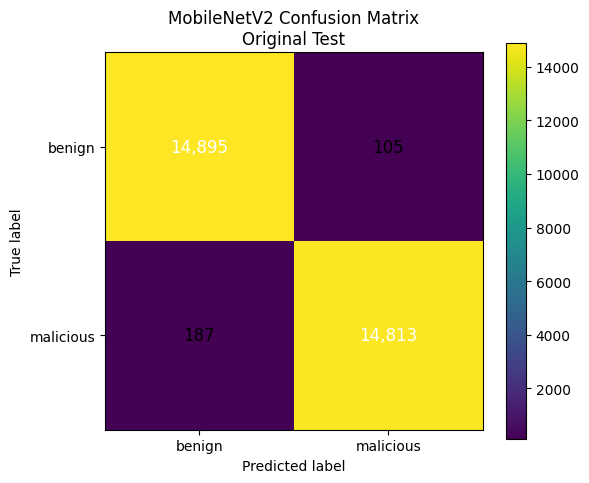

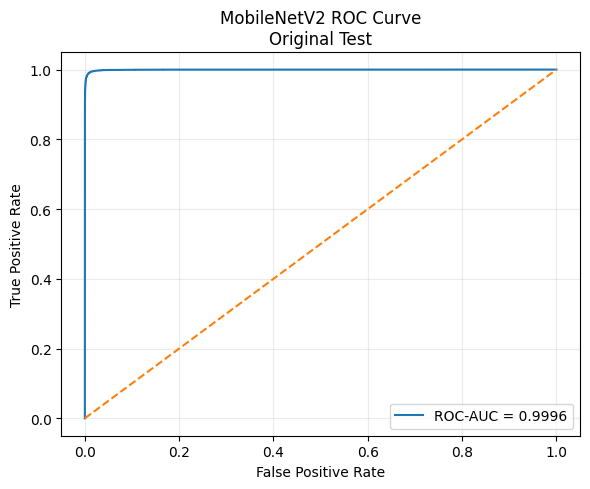

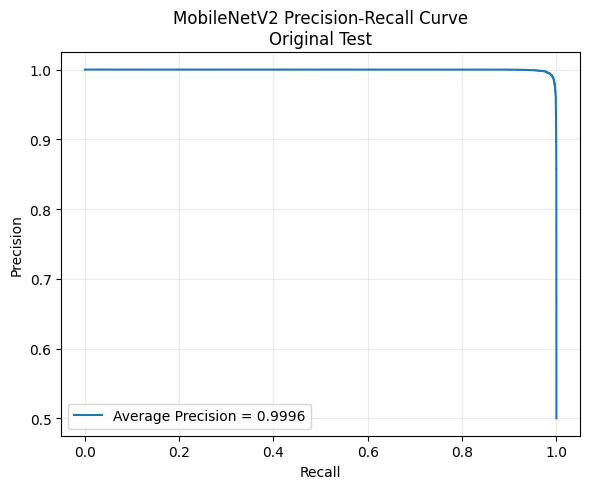


MOBILENETV2 EVALUATION: ORIGINAL_TEST
Samples: 30,000
Positive class: malicious
Averaging method: binary
Decision threshold: 0.5
ROC-AUC input: continuous probabilities

Confusion matrix:
[[14895   105]
 [  187 14813]]

Metrics:
accuracy              : 0.990267
precision             : 0.992962
recall                : 0.987533
f1_score              : 0.990240
roc_auc               : 0.999555
average_precision     : 0.999573
specificity           : 0.993000

Inference:
Total seconds: 19.410381
Seconds per image: 0.00064701
Images per second: 1545.56

Saved outputs:
Predictions: /content/qr_project/results/artifact_controlled_validation/mobilenetv2_reconstructed/final_evaluation/predictions/original_test_predictions.csv
Classification report: /content/qr_project/results/artifact_controlled_validation/mobilenetv2_reconstructed/final_evaluation/reports/original_test_classification_report.csv
Confusion matrix: /content/qr_project/results/artifact_controlled_validation/mobilenetv2_reconstruc

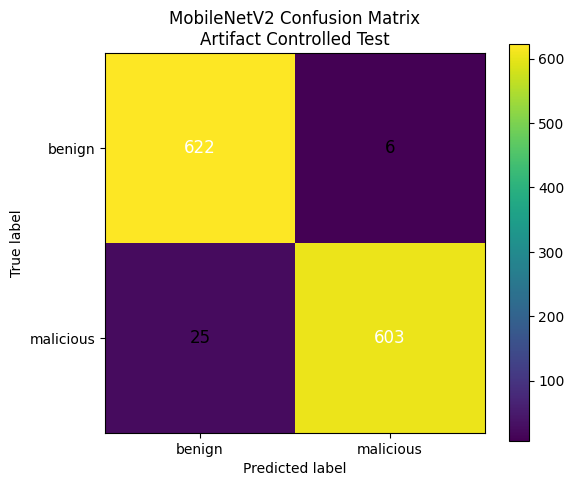

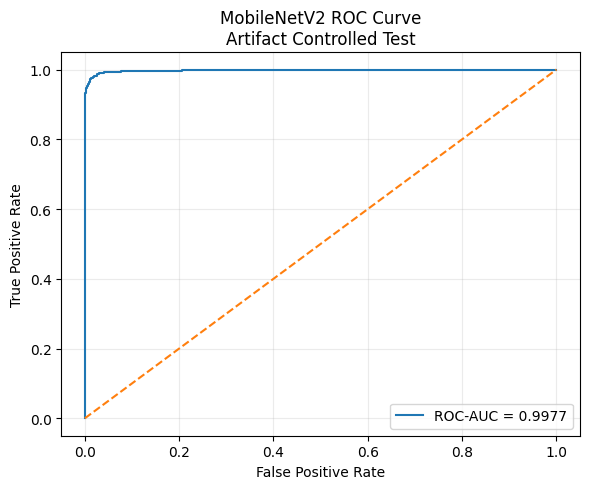

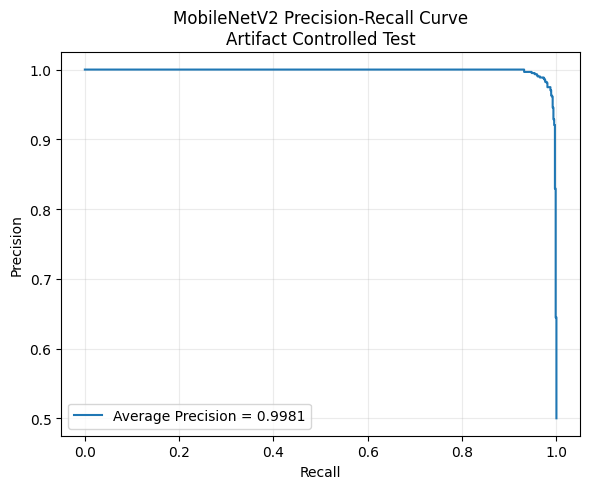


MOBILENETV2 EVALUATION: ARTIFACT_CONTROLLED_TEST
Samples: 1,256
Positive class: malicious
Averaging method: binary
Decision threshold: 0.5
ROC-AUC input: continuous probabilities

Confusion matrix:
[[622   6]
 [ 25 603]]

Metrics:
accuracy              : 0.975318
precision             : 0.990148
recall                : 0.960191
f1_score              : 0.974939
roc_auc               : 0.997723
average_precision     : 0.998110
specificity           : 0.990446

Inference:
Total seconds: 17.615637
Seconds per image: 0.01402519
Images per second: 71.30

Saved outputs:
Predictions: /content/qr_project/results/artifact_controlled_validation/mobilenetv2_reconstructed/final_evaluation/predictions/artifact_controlled_test_predictions.csv
Classification report: /content/qr_project/results/artifact_controlled_validation/mobilenetv2_reconstructed/final_evaluation/reports/artifact_controlled_test_classification_report.csv
Confusion matrix: /content/qr_project/results/artifact_controlled_validation/

,dataset,samples,accuracy,precision,recall,f1_score,roc_auc,true_negative,false_positive,false_negative,true_positive,inference_total_seconds,inference_seconds_per_image
0,original_test,30000,0.9903,0.9930,0.9875,0.9902,0.9996,14895,105,187,14813,19.410381,0.000647
1,artifact_controlled_test,1256,0.9753,0.9901,0.9602,0.9749,0.9977,622,6,25,603,17.615637,0.014025



Controlled-minus-original metric changes:
accuracy              : -0.014948
precision             : -0.002814
recall                : -0.027342
f1_score              : -0.015301
roc_auc               : -0.001832
average_precision     : -0.001463
specificity           : -0.002554

Saved comparison files:
/content/qr_project/results/artifact_controlled_validation/mobilenetv2_reconstructed/final_evaluation/mobilenetv2_original_vs_artifact_controlled_metrics.csv
/content/qr_project/results/artifact_controlled_validation/mobilenetv2_reconstructed/final_evaluation/mobilenetv2_original_vs_artifact_controlled_with_difference.csv
/content/qr_project/results/artifact_controlled_validation/mobilenetv2_reconstructed/final_evaluation/manuscript_mobilenetv2_artifact_validation_table.csv


In [14]:
# ============================================================
# 12) FINAL MOBILENETV2 EVALUATION ON BOTH TEST SETS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import time
import gc
from pathlib import Path


# ------------------------------------------------------------
# Load the final saved MobileNetV2 model
# ------------------------------------------------------------
FINAL_MOBILENET_MODEL_PATH = (
    MODELS_DIR
    / "final_mobilenetv2_qr_classifier.keras"
)

if not FINAL_MOBILENET_MODEL_PATH.exists():
    raise FileNotFoundError(
        "Final MobileNetV2 model not found:\n"
        f"{FINAL_MOBILENET_MODEL_PATH}"
    )

tf.keras.backend.clear_session()
gc.collect()

final_mobilenet_model = (
    tf.keras.models.load_model(
        FINAL_MOBILENET_MODEL_PATH,
        compile=False
    )
)

print(
    "Loaded model:",
    FINAL_MOBILENET_MODEL_PATH
)

print(
    "Input shape:",
    final_mobilenet_model.input_shape
)

print(
    "Output shape:",
    final_mobilenet_model.output_shape
)


# ------------------------------------------------------------
# Evaluation output directories
# ------------------------------------------------------------
EVALUATION_DIR = (
    MOBILENET_RESULTS_DIR
    / "final_evaluation"
)

PREDICTION_DIR = (
    EVALUATION_DIR
    / "predictions"
)

PLOT_DIR = (
    EVALUATION_DIR
    / "plots"
)

REPORT_DIR = (
    EVALUATION_DIR
    / "reports"
)

for folder in [
    EVALUATION_DIR,
    PREDICTION_DIR,
    PLOT_DIR,
    REPORT_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# Evaluation configuration
# ------------------------------------------------------------
DECISION_THRESHOLD = 0.50
POSITIVE_CLASS = 1
POSITIVE_CLASS_NAME = "malicious"

CLASS_NAMES = [
    "benign",
    "malicious"
]


# ------------------------------------------------------------
# Prediction helper
# ------------------------------------------------------------
def predict_probabilities(
    model,
    dataset,
    expected_samples,
    dataset_name
):
    start_time = time.perf_counter()

    probabilities = model.predict(
        dataset,
        verbose=1
    )

    elapsed_seconds = (
        time.perf_counter()
        - start_time
    )

    probabilities = (
        np.asarray(probabilities)
        .reshape(-1)
        .astype(np.float64)
    )

    if len(probabilities) != expected_samples:
        raise ValueError(
            f"{dataset_name}: predicted "
            f"{len(probabilities):,} samples, "
            f"but expected {expected_samples:,}."
        )

    return probabilities, elapsed_seconds


# ------------------------------------------------------------
# Complete evaluation function
# ------------------------------------------------------------
def evaluate_binary_dataset(
    model,
    dataset,
    manifest_df,
    dataset_name,
    threshold=0.50
):
    """
    Evaluate a binary QR-code classifier.

    Positive class:
        malicious = 1

    Threshold-dependent metrics:
        accuracy, precision, recall, F1

    Probability-based metrics:
        ROC-AUC, average precision
    """

    evaluation_df = (
        manifest_df
        .copy()
        .reset_index(drop=True)
    )

    required_columns = {
        "image_path",
        "label",
        "label_id"
    }

    missing_columns = (
        required_columns
        - set(evaluation_df.columns)
    )

    if missing_columns:
        raise KeyError(
            f"{dataset_name}: missing columns "
            f"{sorted(missing_columns)}"
        )

    y_true = (
        evaluation_df["label_id"]
        .astype(int)
        .to_numpy()
    )

    # --------------------------------------------------------
    # Generate continuous prediction probabilities
    # --------------------------------------------------------
    y_probability, inference_seconds = (
        predict_probabilities(
            model=model,
            dataset=dataset,
            expected_samples=len(
                evaluation_df
            ),
            dataset_name=dataset_name
        )
    )

    y_predicted = (
        y_probability
        >= threshold
    ).astype(int)

    # --------------------------------------------------------
    # Classification metrics
    # --------------------------------------------------------
    accuracy = accuracy_score(
        y_true,
        y_predicted
    )

    precision = precision_score(
        y_true,
        y_predicted,
        pos_label=POSITIVE_CLASS,
        average="binary",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_predicted,
        pos_label=POSITIVE_CLASS,
        average="binary",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_predicted,
        pos_label=POSITIVE_CLASS,
        average="binary",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_probability
    )

    average_precision = average_precision_score(
        y_true,
        y_probability
    )

    confusion = confusion_matrix(
        y_true,
        y_predicted,
        labels=[0, 1]
    )

    true_negative = int(
        confusion[0, 0]
    )

    false_positive = int(
        confusion[0, 1]
    )

    false_negative = int(
        confusion[1, 0]
    )

    true_positive = int(
        confusion[1, 1]
    )

    specificity = (
        true_negative
        / max(
            true_negative
            + false_positive,
            1
        )
    )

    negative_predictive_value = (
        true_negative
        / max(
            true_negative
            + false_negative,
            1
        )
    )

    false_positive_rate = (
        false_positive
        / max(
            false_positive
            + true_negative,
            1
        )
    )

    false_negative_rate = (
        false_negative
        / max(
            false_negative
            + true_positive,
            1
        )
    )

    inference_seconds_per_image = (
        inference_seconds
        / max(
            len(evaluation_df),
            1
        )
    )

    inference_images_per_second = (
        len(evaluation_df)
        / max(
            inference_seconds,
            1e-12
        )
    )

    # --------------------------------------------------------
    # Save per-sample predictions
    # --------------------------------------------------------
    prediction_df = evaluation_df.copy()

    prediction_df[
        "positive_class"
    ] = POSITIVE_CLASS_NAME

    prediction_df[
        "decision_threshold"
    ] = threshold

    prediction_df[
        "malicious_probability"
    ] = y_probability

    prediction_df[
        "predicted_label_id"
    ] = y_predicted

    prediction_df[
        "predicted_label"
    ] = np.where(
        y_predicted == 1,
        "malicious",
        "benign"
    )

    prediction_df[
        "correct_prediction"
    ] = (
        prediction_df["label_id"]
        == prediction_df[
            "predicted_label_id"
        ]
    )

    prediction_csv = (
        PREDICTION_DIR
        / f"{dataset_name}_predictions.csv"
    )

    prediction_df.to_csv(
        prediction_csv,
        index=False
    )

    # --------------------------------------------------------
    # Save classification report
    # --------------------------------------------------------
    report_dictionary = (
        classification_report(
            y_true,
            y_predicted,
            labels=[0, 1],
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0
        )
    )

    report_df = (
        pd.DataFrame(
            report_dictionary
        )
        .transpose()
        .reset_index()
        .rename(
            columns={
                "index": "class_or_average"
            }
        )
    )

    report_csv = (
        REPORT_DIR
        / f"{dataset_name}_classification_report.csv"
    )

    report_df.to_csv(
        report_csv,
        index=False
    )

    # --------------------------------------------------------
    # ROC curve data
    # --------------------------------------------------------
    roc_fpr, roc_tpr, roc_thresholds = (
        roc_curve(
            y_true,
            y_probability,
            pos_label=POSITIVE_CLASS
        )
    )

    roc_df = pd.DataFrame(
        {
            "false_positive_rate": roc_fpr,
            "true_positive_rate": roc_tpr,
            "threshold": roc_thresholds
        }
    )

    roc_csv = (
        REPORT_DIR
        / f"{dataset_name}_roc_curve_points.csv"
    )

    roc_df.to_csv(
        roc_csv,
        index=False
    )

    # --------------------------------------------------------
    # Precision-recall curve data
    # --------------------------------------------------------
    pr_precision, pr_recall, pr_thresholds = (
        precision_recall_curve(
            y_true,
            y_probability,
            pos_label=POSITIVE_CLASS
        )
    )

    pr_threshold_column = np.append(
        pr_thresholds,
        np.nan
    )

    pr_df = pd.DataFrame(
        {
            "precision": pr_precision,
            "recall": pr_recall,
            "threshold": pr_threshold_column
        }
    )

    pr_csv = (
        REPORT_DIR
        / (
            f"{dataset_name}_"
            "precision_recall_curve_points.csv"
        )
    )

    pr_df.to_csv(
        pr_csv,
        index=False
    )

    # --------------------------------------------------------
    # Plot confusion matrix
    # --------------------------------------------------------
    figure = plt.figure(
        figsize=(6, 5)
    )

    axis = figure.add_subplot(111)

    image = axis.imshow(
        confusion,
        interpolation="nearest"
    )

    figure.colorbar(
        image,
        ax=axis
    )

    axis.set(
        xticks=np.arange(2),
        yticks=np.arange(2),
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ylabel="True label",
        xlabel="Predicted label",
        title=(
            "MobileNetV2 Confusion Matrix\n"
            f"{dataset_name.replace('_', ' ').title()}"
        )
    )

    maximum_value = (
        confusion.max()
        if confusion.size
        else 1
    )

    text_threshold = (
        maximum_value / 2
    )

    for row_index in range(2):
        for column_index in range(2):
            axis.text(
                column_index,
                row_index,
                f"{confusion[row_index, column_index]:,}",
                horizontalalignment="center",
                verticalalignment="center",
                color=(
                    "white"
                    if confusion[
                        row_index,
                        column_index
                    ] > text_threshold
                    else "black"
                ),
                fontsize=12
            )

    figure.tight_layout()

    confusion_plot_path = (
        PLOT_DIR
        / f"{dataset_name}_confusion_matrix.png"
    )

    figure.savefig(
        confusion_plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(figure)

    # --------------------------------------------------------
    # Plot ROC curve
    # --------------------------------------------------------
    figure = plt.figure(
        figsize=(6, 5)
    )

    axis = figure.add_subplot(111)

    axis.plot(
        roc_fpr,
        roc_tpr,
        label=f"ROC-AUC = {roc_auc:.4f}"
    )

    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    axis.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title=(
            "MobileNetV2 ROC Curve\n"
            f"{dataset_name.replace('_', ' ').title()}"
        )
    )

    axis.legend(
        loc="lower right"
    )

    axis.grid(
        alpha=0.25
    )

    figure.tight_layout()

    roc_plot_path = (
        PLOT_DIR
        / f"{dataset_name}_roc_curve.png"
    )

    figure.savefig(
        roc_plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(figure)

    # --------------------------------------------------------
    # Plot precision-recall curve
    # --------------------------------------------------------
    figure = plt.figure(
        figsize=(6, 5)
    )

    axis = figure.add_subplot(111)

    axis.plot(
        pr_recall,
        pr_precision,
        label=(
            "Average Precision = "
            f"{average_precision:.4f}"
        )
    )

    axis.set(
        xlabel="Recall",
        ylabel="Precision",
        title=(
            "MobileNetV2 Precision-Recall Curve\n"
            f"{dataset_name.replace('_', ' ').title()}"
        )
    )

    axis.legend(
        loc="lower left"
    )

    axis.grid(
        alpha=0.25
    )

    figure.tight_layout()

    pr_plot_path = (
        PLOT_DIR
        / (
            f"{dataset_name}_"
            "precision_recall_curve.png"
        )
    )

    figure.savefig(
        pr_plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(figure)

    # --------------------------------------------------------
    # Build one-row summary
    # --------------------------------------------------------
    summary_row = {
        "model": "MobileNetV2",
        "dataset": dataset_name,
        "samples": int(
            len(evaluation_df)
        ),
        "benign_samples": int(
            np.sum(y_true == 0)
        ),
        "malicious_samples": int(
            np.sum(y_true == 1)
        ),
        "positive_class": (
            POSITIVE_CLASS_NAME
        ),
        "averaging_method": "binary",
        "decision_threshold": float(
            threshold
        ),
        "accuracy": float(
            accuracy
        ),
        "precision": float(
            precision
        ),
        "recall": float(
            recall
        ),
        "f1_score": float(
            f1
        ),
        "roc_auc": float(
            roc_auc
        ),
        "average_precision": float(
            average_precision
        ),
        "specificity": float(
            specificity
        ),
        "negative_predictive_value": float(
            negative_predictive_value
        ),
        "false_positive_rate": float(
            false_positive_rate
        ),
        "false_negative_rate": float(
            false_negative_rate
        ),
        "true_negative": (
            true_negative
        ),
        "false_positive": (
            false_positive
        ),
        "false_negative": (
            false_negative
        ),
        "true_positive": (
            true_positive
        ),
        "inference_total_seconds": float(
            inference_seconds
        ),
        "inference_seconds_per_image": float(
            inference_seconds_per_image
        ),
        "inference_images_per_second": float(
            inference_images_per_second
        ),
        "roc_auc_input": (
            "continuous malicious-class probabilities"
        )
    }

    print("\n" + "=" * 76)
    print(
        f"MOBILENETV2 EVALUATION: "
        f"{dataset_name.upper()}"
    )
    print("=" * 76)

    print(
        "Samples:",
        f"{len(evaluation_df):,}"
    )

    print(
        "Positive class:",
        POSITIVE_CLASS_NAME
    )

    print(
        "Averaging method:",
        "binary"
    )

    print(
        "Decision threshold:",
        threshold
    )

    print(
        "ROC-AUC input:",
        "continuous probabilities"
    )

    print("\nConfusion matrix:")
    print(confusion)

    print("\nMetrics:")

    for metric_name in [
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "average_precision",
        "specificity"
    ]:
        print(
            f"{metric_name:22s}: "
            f"{summary_row[metric_name]:.6f}"
        )

    print("\nInference:")

    print(
        "Total seconds:",
        f"{inference_seconds:.6f}"
    )

    print(
        "Seconds per image:",
        f"{inference_seconds_per_image:.8f}"
    )

    print(
        "Images per second:",
        f"{inference_images_per_second:.2f}"
    )

    print("\nSaved outputs:")

    print(
        "Predictions:",
        prediction_csv
    )

    print(
        "Classification report:",
        report_csv
    )

    print(
        "Confusion matrix:",
        confusion_plot_path
    )

    print(
        "ROC plot:",
        roc_plot_path
    )

    print(
        "Precision-recall plot:",
        pr_plot_path
    )

    return {
        "summary": summary_row,
        "predictions": prediction_df,
        "classification_report": report_df,
        "confusion_matrix": confusion,
        "roc_curve": roc_df,
        "precision_recall_curve": pr_df
    }


# ------------------------------------------------------------
# Evaluate on the full original test set
# ------------------------------------------------------------
original_test_result = (
    evaluate_binary_dataset(
        model=final_mobilenet_model,
        dataset=test_ds,
        manifest_df=test_df,
        dataset_name="original_test",
        threshold=DECISION_THRESHOLD
    )
)


# ------------------------------------------------------------
# Evaluate on the strict artifact-controlled subset
# ------------------------------------------------------------
controlled_test_result = (
    evaluate_binary_dataset(
        model=final_mobilenet_model,
        dataset=controlled_ds,
        manifest_df=controlled_df,
        dataset_name="artifact_controlled_test",
        threshold=DECISION_THRESHOLD
    )
)


# ------------------------------------------------------------
# Build direct comparison table
# ------------------------------------------------------------
comparison_df = pd.DataFrame(
    [
        original_test_result[
            "summary"
        ],
        controlled_test_result[
            "summary"
        ]
    ]
)

metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "average_precision",
    "specificity"
]

original_summary = (
    original_test_result[
        "summary"
    ]
)

controlled_summary = (
    controlled_test_result[
        "summary"
    ]
)

difference_row = {
    "model": "MobileNetV2",
    "dataset": (
        "controlled_minus_original"
    ),
    "samples": (
        controlled_summary["samples"]
        - original_summary["samples"]
    ),
    "benign_samples": (
        controlled_summary[
            "benign_samples"
        ]
        - original_summary[
            "benign_samples"
        ]
    ),
    "malicious_samples": (
        controlled_summary[
            "malicious_samples"
        ]
        - original_summary[
            "malicious_samples"
        ]
    ),
    "positive_class": (
        POSITIVE_CLASS_NAME
    ),
    "averaging_method": "binary",
    "decision_threshold": (
        DECISION_THRESHOLD
    )
}

for metric_name in metric_columns:
    difference_row[metric_name] = (
        controlled_summary[
            metric_name
        ]
        - original_summary[
            metric_name
        ]
    )

comparison_with_difference_df = (
    pd.concat(
        [
            comparison_df,
            pd.DataFrame(
                [difference_row]
            )
        ],
        ignore_index=True
    )
)


# ------------------------------------------------------------
# Save comparison tables
# ------------------------------------------------------------
MOBILENET_COMPARISON_CSV = (
    EVALUATION_DIR
    / (
        "mobilenetv2_original_vs_"
        "artifact_controlled_metrics.csv"
    )
)

MOBILENET_COMPARISON_WITH_DIFFERENCE_CSV = (
    EVALUATION_DIR
    / (
        "mobilenetv2_original_vs_"
        "artifact_controlled_with_difference.csv"
    )
)

comparison_df.to_csv(
    MOBILENET_COMPARISON_CSV,
    index=False
)

comparison_with_difference_df.to_csv(
    MOBILENET_COMPARISON_WITH_DIFFERENCE_CSV,
    index=False
)


# ------------------------------------------------------------
# Create clean manuscript-facing comparison
# ------------------------------------------------------------
manuscript_comparison_df = (
    comparison_df[
        [
            "dataset",
            "samples",
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "roc_auc",
            "true_negative",
            "false_positive",
            "false_negative",
            "true_positive",
            "inference_total_seconds",
            "inference_seconds_per_image"
        ]
    ]
    .copy()
)

manuscript_comparison_df[
    "accuracy"
] = manuscript_comparison_df[
    "accuracy"
].round(4)

manuscript_comparison_df[
    "precision"
] = manuscript_comparison_df[
    "precision"
].round(4)

manuscript_comparison_df[
    "recall"
] = manuscript_comparison_df[
    "recall"
].round(4)

manuscript_comparison_df[
    "f1_score"
] = manuscript_comparison_df[
    "f1_score"
].round(4)

manuscript_comparison_df[
    "roc_auc"
] = manuscript_comparison_df[
    "roc_auc"
].round(4)

MANUSCRIPT_MOBILENET_TABLE_CSV = (
    EVALUATION_DIR
    / (
        "manuscript_mobilenetv2_"
        "artifact_validation_table.csv"
    )
)

manuscript_comparison_df.to_csv(
    MANUSCRIPT_MOBILENET_TABLE_CSV,
    index=False
)


# ------------------------------------------------------------
# Final comparison report
# ------------------------------------------------------------
print("\n" + "=" * 76)
print(
    "MOBILENETV2 ORIGINAL VS "
    "ARTIFACT-CONTROLLED COMPARISON"
)
print("=" * 76)

display(
    manuscript_comparison_df
)

print("\nControlled-minus-original metric changes:")

for metric_name in metric_columns:
    metric_change = (
        controlled_summary[
            metric_name
        ]
        - original_summary[
            metric_name
        ]
    )

    print(
        f"{metric_name:22s}: "
        f"{metric_change:+.6f}"
    )

print("\nSaved comparison files:")

print(
    MOBILENET_COMPARISON_CSV
)

print(
    MOBILENET_COMPARISON_WITH_DIFFERENCE_CSV
)

print(
    MANUSCRIPT_MOBILENET_TABLE_CSV
)

## 13. Locate TabNet Features, Preprocessing Objects, and Checkpoints

The notebook searches the project workspace and Google Drive for the fused handcrafted-feature datasets, saved preprocessing objects, feature-column lists, and any previously trained TabNet checkpoint.

In [15]:
# ============================================================
# 13) DISCOVER TABNET FEATURES, PREPROCESSORS, AND CHECKPOINTS
# ============================================================

import os
from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# Search locations
# ------------------------------------------------------------
TABNET_SEARCH_ROOTS = [
    Path("/content/qr_project"),
    Path("/content/drive/MyDrive")
]

# File types likely to contain features, preprocessors, or models
SEARCH_EXTENSIONS = {
    ".csv",
    ".parquet",
    ".pkl",
    ".pickle",
    ".joblib",
    ".zip",
    ".npy",
    ".npz",
    ".json",
    ".pt",
    ".pth"
}

TABNET_TERMS = [
    "tabnet",
    "fused",
    "fusion",
    "feature",
    "structural",
    "statistical",
    "robust",
    "scaler",
    "imputer",
    "selected",
    "column",
    "train",
    "val",
    "test"
]

# ------------------------------------------------------------
# Discover candidate files
# ------------------------------------------------------------
candidate_rows = []

for root in TABNET_SEARCH_ROOTS:
    if not root.exists():
        continue

    print("Searching:", root)

    for path in root.rglob("*"):
        if not path.is_file():
            continue

        suffix = path.suffix.lower()

        if suffix not in SEARCH_EXTENSIONS:
            continue

        path_text = str(path).lower()

        matched_terms = [
            term
            for term in TABNET_TERMS
            if term in path_text
        ]

        if not matched_terms:
            continue

        try:
            size_mb = path.stat().st_size / (1024 ** 2)
            modified_time = path.stat().st_mtime
        except Exception:
            size_mb = np.nan
            modified_time = np.nan

        candidate_rows.append(
            {
                "path": str(path),
                "filename": path.name,
                "extension": suffix,
                "size_mb": size_mb,
                "matched_terms": ", ".join(matched_terms),
                "term_count": len(matched_terms),
                "modified_time": modified_time
            }
        )

candidate_files_df = pd.DataFrame(candidate_rows)

if candidate_files_df.empty:
    print("\nNo likely TabNet-related files were found.")

else:
    candidate_files_df["modified_datetime"] = pd.to_datetime(
        candidate_files_df["modified_time"],
        unit="s",
        errors="coerce"
    )

    candidate_files_df = (
        candidate_files_df
        .sort_values(
            ["term_count", "size_mb", "modified_time"],
            ascending=[False, False, False]
        )
        .reset_index(drop=True)
    )

    print("\n" + "=" * 78)
    print("TABNET-RELATED FILE CANDIDATES")
    print("=" * 78)

    display(
        candidate_files_df[
            [
                "path",
                "extension",
                "size_mb",
                "matched_terms",
                "modified_datetime"
            ]
        ].head(100)
    )


# ------------------------------------------------------------
# Inspect CSV and Parquet schemas without loading everything
# ------------------------------------------------------------
schema_rows = []

if not candidate_files_df.empty:

    structured_candidates = candidate_files_df[
        candidate_files_df["extension"].isin(
            [".csv", ".parquet"]
        )
    ].head(50)

    for row in structured_candidates.itertuples(index=False):
        path = Path(row.path)

        schema_record = {
            "path": str(path),
            "read_success": False,
            "rows": None,
            "columns": None,
            "first_columns": None,
            "contains_label": False,
            "contains_image_path": False,
            "error": None
        }

        try:
            if path.suffix.lower() == ".csv":
                sample_df = pd.read_csv(
                    path,
                    nrows=5
                )

                # Count rows quickly without full DataFrame loading
                with open(
                    path,
                    "r",
                    encoding="utf-8",
                    errors="ignore"
                ) as file_handle:
                    row_count = (
                        sum(1 for _ in file_handle) - 1
                    )

            else:
                sample_df = pd.read_parquet(
                    path
                )

                row_count = len(sample_df)

            columns = sample_df.columns.tolist()

            schema_record.update(
                {
                    "read_success": True,
                    "rows": int(row_count),
                    "columns": len(columns),
                    "first_columns": ", ".join(
                        columns[:20]
                    ),
                    "contains_label": any(
                        column.lower() in {
                            "label",
                            "label_id",
                            "target",
                            "class"
                        }
                        for column in columns
                    ),
                    "contains_image_path": any(
                        column.lower() in {
                            "image_path",
                            "image",
                            "path",
                            "filepath",
                            "file_path"
                        }
                        for column in columns
                    )
                }
            )

        except Exception as error:
            schema_record["error"] = (
                f"{type(error).__name__}: "
                f"{str(error)[:200]}"
            )

        schema_rows.append(schema_record)

schema_audit_df = pd.DataFrame(schema_rows)

if not schema_audit_df.empty:
    print("\n" + "=" * 78)
    print("FEATURE FILE SCHEMA AUDIT")
    print("=" * 78)

    display(schema_audit_df)


# ------------------------------------------------------------
# Separate likely categories
# ------------------------------------------------------------
def select_candidates(patterns):
    if candidate_files_df.empty:
        return pd.DataFrame()

    mask = candidate_files_df["path"].str.lower().apply(
        lambda text: any(
            pattern in text
            for pattern in patterns
        )
    )

    return candidate_files_df[mask].copy()


feature_candidates_df = select_candidates(
    [
        "fused",
        "feature",
        "structural",
        "statistical"
    ]
)

preprocessor_candidates_df = select_candidates(
    [
        "scaler",
        "imputer",
        "column",
        "selected",
        "preprocess"
    ]
)

model_candidates_df = select_candidates(
    [
        "tabnet",
        ".zip",
        ".pt",
        ".pth"
    ]
)


print("\n" + "=" * 78)
print("LIKELY FEATURE DATASETS")
print("=" * 78)

if feature_candidates_df.empty:
    print("None found.")
else:
    display(
        feature_candidates_df[
            [
                "path",
                "extension",
                "size_mb",
                "matched_terms"
            ]
        ].head(40)
    )


print("\n" + "=" * 78)
print("LIKELY PREPROCESSING OBJECTS")
print("=" * 78)

if preprocessor_candidates_df.empty:
    print("None found.")
else:
    display(
        preprocessor_candidates_df[
            [
                "path",
                "extension",
                "size_mb",
                "matched_terms"
            ]
        ].head(40)
    )


print("\n" + "=" * 78)
print("LIKELY TABNET CHECKPOINTS")
print("=" * 78)

if model_candidates_df.empty:
    print("None found.")
else:
    display(
        model_candidates_df[
            [
                "path",
                "extension",
                "size_mb",
                "matched_terms"
            ]
        ].head(40)
    )


# ------------------------------------------------------------
# Save discovery audit
# ------------------------------------------------------------
TABNET_DISCOVERY_CSV = (
    TABLES_DIR
    / "tabnet_file_discovery.csv"
)

TABNET_SCHEMA_AUDIT_CSV = (
    TABLES_DIR
    / "tabnet_feature_schema_audit.csv"
)

if not candidate_files_df.empty:
    candidate_files_df.to_csv(
        TABNET_DISCOVERY_CSV,
        index=False
    )

if not schema_audit_df.empty:
    schema_audit_df.to_csv(
        TABNET_SCHEMA_AUDIT_CSV,
        index=False
    )


print("\n" + "=" * 78)
print("TABNET DISCOVERY COMPLETE")
print("=" * 78)

print(
    "Candidate files found:",
    len(candidate_files_df)
)

print(
    "Structured files inspected:",
    len(schema_audit_df)
)

print(
    "Discovery audit:",
    TABNET_DISCOVERY_CSV
)

print(
    "Schema audit:",
    TABNET_SCHEMA_AUDIT_CSV
)

Searching: /content/qr_project
Searching: /content/drive/MyDrive

TABNET-RELATED FILE CANDIDATES


,path,extension,size_mb,matched_terms,modified_datetime
0,/content/drive/MyDrive/Currency/data/features/...,.csv,10.277595,"fused, feature, train",2026-06-29 20:03:56.000000000
1,/content/drive/MyDrive/Currency/data/features/...,.csv,4.325742,"feature, structural, train",2026-06-29 20:08:59.000000000
2,/content/drive/MyDrive/Currency/data/features/...,.csv,2.873199,"feature, statistical, train",2026-06-29 20:06:55.000000000
3,/content/drive/MyDrive/Currency/data/features/...,.csv,2.215668,"fused, feature, test",2026-06-29 20:04:26.000000000
4,/content/drive/MyDrive/Currency/data/features/...,.csv,2.205933,"fused, feature, val",2026-06-29 20:14:18.000000000
...,...,...,...,...,...
88,/content/drive/MyDrive/Currency/results/tables...,.csv,0.000224,test,2026-06-29 20:10:05.000000000
89,/content/drive/MyDrive/Currency/results/tables...,.csv,0.000224,val,2026-06-29 20:03:46.000000000
90,/content/qr_project/results/artifact_controlle...,.csv,0.000202,val,2026-08-01 15:57:27.774031162
91,/content/drive/MyDrive/Currency/data/features/...,.csv,0.000155,feature,2026-06-29 20:11:19.000000000



FEATURE FILE SCHEMA AUDIT


,path,read_success,rows,columns,first_columns,contains_label,contains_image_path,error
0,/content/drive/MyDrive/Currency/data/features/...,True,5078,120,"image_path, file_name, label, label_id, phash,...",True,True,None
1,/content/drive/MyDrive/Currency/data/features/...,True,5078,47,"image_path, file_name, label, label_id, phash,...",True,True,None
2,/content/drive/MyDrive/Currency/data/features/...,True,5078,33,"image_path, file_name, label, label_id, phash,...",True,True,None
3,/content/drive/MyDrive/Currency/data/features/...,True,1094,120,"image_path, file_name, label, label_id, phash,...",True,True,None
4,/content/drive/MyDrive/Currency/data/features/...,True,1088,120,"image_path, file_name, label, label_id, phash,...",True,True,None
5,/content/drive/MyDrive/Currency/data/features/...,True,1094,47,"image_path, file_name, label, label_id, phash,...",True,True,None
6,/content/drive/MyDrive/Currency/data/features/...,True,1088,47,"image_path, file_name, label, label_id, phash,...",True,True,None
7,/content/drive/MyDrive/Currency/data/features/...,True,1094,33,"image_path, file_name, label, label_id, phash,...",True,True,None
8,/content/drive/MyDrive/Currency/data/features/...,True,1088,33,"image_path, file_name, label, label_id, phash,...",True,True,None
9,/content/drive/MyDrive/Currency/data/features/...,True,5078,1286,"image_path, file_name, label, label_id, phash,...",True,True,None



LIKELY FEATURE DATASETS


...


LIKELY PREPROCESSING OBJECTS


,path,extension,size_mb,matched_terms
30,/content/drive/MyDrive/Currency/models/preproc...,.pkl,0.001620,"feature, selected"
31,/content/drive/MyDrive/Currency/models/preproc...,.pkl,0.001620,"feature, selected"
57,/content/drive/MyDrive/Currency/models/preproc...,.pkl,0.029931,imputer
58,/content/drive/MyDrive/Currency/models/preproc...,.pkl,0.029738,scaler
62,/content/drive/MyDrive/Currency/models/preproc...,.pkl,0.003744,imputer
63,/content/drive/MyDrive/Currency/models/preproc...,.pkl,0.003744,imputer
66,/content/drive/MyDrive/Currency/models/preproc...,.pkl,0.002109,scaler
67,/content/drive/MyDrive/Currency/models/preproc...,.pkl,0.002109,scaler



LIKELY TABNET CHECKPOINTS


,path,extension,size_mb,matched_terms
26,/content/qr_project/results/artifact_controlle...,.csv,0.132394,"tabnet, val"



TABNET DISCOVERY COMPLETE
Candidate files found: 93
Structured files inspected: 50
Discovery audit: /content/qr_project/results/artifact_controlled_validation/tables/tabnet_file_discovery.csv
Schema audit: /content/qr_project/results/artifact_controlled_validation/tables/tabnet_feature_schema_audit.csv


## 14. Verify the Exact QR Fused-Feature Splits

The TabNet branch uses the preprocessed fusion of statistical and structural QR-image features. This step verifies the exact train, validation, and test feature files expected by the original implementation and checks whether the artifact-controlled sample identifiers can be aligned with the test feature rows.

In [16]:
# ============================================================
# 14) VERIFY EXACT QR TABNET FEATURE FILES AND ALIGNMENT
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Exact paths from the original QR notebook
# ------------------------------------------------------------
RESULTS_DIR = Path("/content/qr_project/results")

TRAIN_FUSED_CSV = (
    RESULTS_DIR
    / "train_fused_preprocessed.csv"
)

VAL_FUSED_CSV = (
    RESULTS_DIR
    / "val_fused_preprocessed.csv"
)

TEST_FUSED_CSV = (
    RESULTS_DIR
    / "test_fused_preprocessed.csv"
)

CONTROLLED_MANIFEST_CSV = (
    RESULTS_DIR
    / "artifact_controlled_validation"
    / "tables"
    / "tabnet_artifact_controlled_subset.csv"
)

expected_files = [
    TRAIN_FUSED_CSV,
    VAL_FUSED_CSV,
    TEST_FUSED_CSV,
    CONTROLLED_MANIFEST_CSV
]

print("=" * 76)
print("EXACT QR TABNET FILE VERIFICATION")
print("=" * 76)

for path in expected_files:
    print(
        f"{path.name:45s}: "
        f"{'FOUND' if path.exists() else 'MISSING'}"
    )


# ------------------------------------------------------------
# Stop early if fused features do not exist
# ------------------------------------------------------------
missing_fused_files = [
    path
    for path in [
        TRAIN_FUSED_CSV,
        VAL_FUSED_CSV,
        TEST_FUSED_CSV
    ]
    if not path.exists()
]

if missing_fused_files:
    print("\nThe exact QR fused-feature files are unavailable.")

    print("\nMissing files:")
    for path in missing_fused_files:
        print(" -", path)

    print(
        "\nThe next step must rebuild the statistical and "
        "structural feature pipeline from the QR images."
    )

else:
    # --------------------------------------------------------
    # Load only when all exact feature files exist
    # --------------------------------------------------------
    train_fused_df = pd.read_csv(
        TRAIN_FUSED_CSV
    )

    val_fused_df = pd.read_csv(
        VAL_FUSED_CSV
    )

    test_fused_df = pd.read_csv(
        TEST_FUSED_CSV
    )

    controlled_manifest_df = pd.read_csv(
        CONTROLLED_MANIFEST_CSV
    )

    # --------------------------------------------------------
    # Standardize image identifier column
    # --------------------------------------------------------
    def standardize_fused_dataframe(
        dataframe,
        split_name
    ):
        dataframe = dataframe.copy()

        if "image" in dataframe.columns:
            image_column = "image"

        elif "image_path" in dataframe.columns:
            dataframe = dataframe.rename(
                columns={
                    "image_path": "image"
                }
            )
            image_column = "image"

        else:
            raise KeyError(
                f"{split_name}: neither 'image' nor "
                "'image_path' exists."
            )

        required_columns = {
            "image",
            "label",
            "label_id"
        }

        missing_columns = (
            required_columns
            - set(dataframe.columns)
        )

        if missing_columns:
            raise KeyError(
                f"{split_name}: missing columns "
                f"{sorted(missing_columns)}"
            )

        dataframe["image"] = (
            dataframe["image"]
            .astype(str)
            .str.strip()
        )

        dataframe["label"] = (
            dataframe["label"]
            .astype(str)
            .str.lower()
            .str.strip()
        )

        dataframe["label_id"] = (
            pd.to_numeric(
                dataframe["label_id"],
                errors="raise"
            )
            .astype(int)
        )

        return dataframe


    train_fused_df = (
        standardize_fused_dataframe(
            train_fused_df,
            "Training fused split"
        )
    )

    val_fused_df = (
        standardize_fused_dataframe(
            val_fused_df,
            "Validation fused split"
        )
    )

    test_fused_df = (
        standardize_fused_dataframe(
            test_fused_df,
            "Test fused split"
        )
    )


    # --------------------------------------------------------
    # Determine exact feature columns
    # --------------------------------------------------------
    metadata_columns = [
        "image",
        "label",
        "label_id"
    ]

    feature_columns = [
        column
        for column in train_fused_df.columns
        if column not in metadata_columns
    ]

    missing_in_validation = [
        column
        for column in feature_columns
        if column not in val_fused_df.columns
    ]

    missing_in_test = [
        column
        for column in feature_columns
        if column not in test_fused_df.columns
    ]

    if missing_in_validation:
        raise ValueError(
            "Validation split is missing feature columns: "
            f"{missing_in_validation[:20]}"
        )

    if missing_in_test:
        raise ValueError(
            "Test split is missing feature columns: "
            f"{missing_in_test[:20]}"
        )


    # --------------------------------------------------------
    # Align controlled samples using full image paths
    # --------------------------------------------------------
    controlled_manifest_df[
        "image_path"
    ] = (
        controlled_manifest_df[
            "image_path"
        ]
        .astype(str)
        .str.strip()
    )

    test_feature_lookup = (
        test_fused_df
        .set_index("image")
    )

    controlled_paths = (
        controlled_manifest_df[
            "image_path"
        ]
        .tolist()
    )

    matched_path_mask = (
        controlled_manifest_df[
            "image_path"
        ]
        .isin(
            test_feature_lookup.index
        )
    )

    matched_controlled_count = int(
        matched_path_mask.sum()
    )


    # --------------------------------------------------------
    # If exact paths differ, compare filenames as fallback
    # --------------------------------------------------------
    controlled_manifest_df[
        "file_name"
    ] = (
        controlled_manifest_df[
            "image_path"
        ]
        .map(
            lambda value: Path(value).name
        )
    )

    test_fused_df[
        "file_name"
    ] = (
        test_fused_df[
            "image"
        ]
        .map(
            lambda value: Path(value).name
        )
    )

    duplicate_test_filenames = int(
        test_fused_df[
            "file_name"
        ]
        .duplicated()
        .sum()
    )

    filename_match_count = int(
        controlled_manifest_df[
            "file_name"
        ]
        .isin(
            test_fused_df[
                "file_name"
            ]
        )
        .sum()
    )


    # --------------------------------------------------------
    # Numeric integrity checks
    # --------------------------------------------------------
    numeric_train = (
        train_fused_df[
            feature_columns
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
    )

    numeric_val = (
        val_fused_df[
            feature_columns
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
    )

    numeric_test = (
        test_fused_df[
            feature_columns
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
    )

    train_nan_count = int(
        numeric_train.isna().sum().sum()
    )

    val_nan_count = int(
        numeric_val.isna().sum().sum()
    )

    test_nan_count = int(
        numeric_test.isna().sum().sum()
    )

    train_inf_count = int(
        np.isinf(
            numeric_train.to_numpy(
                dtype=np.float64
            )
        ).sum()
    )

    val_inf_count = int(
        np.isinf(
            numeric_val.to_numpy(
                dtype=np.float64
            )
        ).sum()
    )

    test_inf_count = int(
        np.isinf(
            numeric_test.to_numpy(
                dtype=np.float64
            )
        ).sum()
    )


    # --------------------------------------------------------
    # Report
    # --------------------------------------------------------
    print("\n" + "=" * 76)
    print("QR FUSED-FEATURE SPLIT SUMMARY")
    print("=" * 76)

    print(
        "Training shape:",
        train_fused_df.shape
    )

    print(
        "Validation shape:",
        val_fused_df.shape
    )

    print(
        "Test shape:",
        test_fused_df.shape
    )

    print(
        "Feature count:",
        len(feature_columns)
    )

    print(
        "\nFirst 20 features:"
    )

    print(
        feature_columns[:20]
    )

    print(
        "\nTraining class distribution:"
    )

    print(
        train_fused_df[
            "label"
        ]
        .value_counts()
        .to_string()
    )

    print(
        "\nValidation class distribution:"
    )

    print(
        val_fused_df[
            "label"
        ]
        .value_counts()
        .to_string()
    )

    print(
        "\nTest class distribution:"
    )

    print(
        test_fused_df[
            "label"
        ]
        .value_counts()
        .to_string()
    )

    print("\nFeature integrity:")

    print(
        "Training NaN values:",
        train_nan_count
    )

    print(
        "Validation NaN values:",
        val_nan_count
    )

    print(
        "Test NaN values:",
        test_nan_count
    )

    print(
        "Training infinite values:",
        train_inf_count
    )

    print(
        "Validation infinite values:",
        val_inf_count
    )

    print(
        "Test infinite values:",
        test_inf_count
    )

    print("\nControlled-subset alignment:")

    print(
        "Controlled samples:",
        f"{len(controlled_manifest_df):,}"
    )

    print(
        "Exact full-path matches:",
        f"{matched_controlled_count:,}"
    )

    print(
        "Filename matches:",
        f"{filename_match_count:,}"
    )

    print(
        "Duplicate filenames in fused test set:",
        duplicate_test_filenames
    )

    # --------------------------------------------------------
    # Save verification summary
    # --------------------------------------------------------
    verification_summary_df = pd.DataFrame(
        [
            {
                "train_rows": len(
                    train_fused_df
                ),
                "validation_rows": len(
                    val_fused_df
                ),
                "test_rows": len(
                    test_fused_df
                ),
                "feature_count": len(
                    feature_columns
                ),
                "controlled_rows": len(
                    controlled_manifest_df
                ),
                "controlled_exact_path_matches": (
                    matched_controlled_count
                ),
                "controlled_filename_matches": (
                    filename_match_count
                ),
                "duplicate_test_filenames": (
                    duplicate_test_filenames
                ),
                "train_nan_count": (
                    train_nan_count
                ),
                "validation_nan_count": (
                    val_nan_count
                ),
                "test_nan_count": (
                    test_nan_count
                ),
                "train_inf_count": (
                    train_inf_count
                ),
                "validation_inf_count": (
                    val_inf_count
                ),
                "test_inf_count": (
                    test_inf_count
                )
            }
        ]
    )

    TABNET_VERIFICATION_CSV = (
        RESULTS_DIR
        / "artifact_controlled_validation"
        / "tables"
        / "exact_qr_tabnet_feature_verification.csv"
    )

    verification_summary_df.to_csv(
        TABNET_VERIFICATION_CSV,
        index=False
    )

    print(
        "\nVerification saved to:",
        TABNET_VERIFICATION_CSV
    )

EXACT QR TABNET FILE VERIFICATION
train_fused_preprocessed.csv                 : MISSING
val_fused_preprocessed.csv                   : MISSING
test_fused_preprocessed.csv                  : MISSING
tabnet_artifact_controlled_subset.csv        : FOUND

The exact QR fused-feature files are unavailable.

Missing files:
 - /content/qr_project/results/train_fused_preprocessed.csv
 - /content/qr_project/results/val_fused_preprocessed.csv
 - /content/qr_project/results/test_fused_preprocessed.csv

The next step must rebuild the statistical and structural feature pipeline from the QR images.


## 15. Reconstruct the Master QR Metadata Table

The existing train, validation, and test manifests are combined into one master table while preserving each sample’s original partition. This table is used as the common input for statistical and structural feature extraction.

In [17]:
# ============================================================
# 15) BUILD MASTER QR METADATA WITH FIXED SPLIT ASSIGNMENTS
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
RESULTS_DIR = Path("/content/qr_project/results")

TRAIN_CSV = RESULTS_DIR / "train.csv"
VAL_CSV = RESULTS_DIR / "val.csv"
TEST_CSV = RESULTS_DIR / "test.csv"

MASTER_METADATA_CSV = (
    RESULTS_DIR
    / "qr_master_metadata_with_splits.csv"
)

CLEANED_METADATA_CSV = (
    RESULTS_DIR
    / "cleaned_qr_metadata.csv"
)

QR_DATASET_CLEAN_CSV = (
    RESULTS_DIR
    / "qr_dataset_clean.csv"
)

for required_path in [
    TRAIN_CSV,
    VAL_CSV,
    TEST_CSV
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required split file not found: {required_path}"
        )


# ------------------------------------------------------------
# Load and standardize one split
# ------------------------------------------------------------
LABEL_MAP = {
    "benign": 0,
    "malicious": 1
}


def load_split(path, split_name):
    dataframe = pd.read_csv(path).copy()

    if "image_path" not in dataframe.columns:
        if "image" in dataframe.columns:
            dataframe = dataframe.rename(
                columns={"image": "image_path"}
            )
        else:
            raise KeyError(
                f"{split_name}: no image path column found."
            )

    if "label" not in dataframe.columns:
        raise KeyError(
            f"{split_name}: label column is missing."
        )

    dataframe["image_path"] = (
        dataframe["image_path"]
        .astype(str)
        .str.strip()
    )

    dataframe["label"] = (
        dataframe["label"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    if "label_id" not in dataframe.columns:
        dataframe["label_id"] = (
            dataframe["label"]
            .map(LABEL_MAP)
        )

    dataframe["label_id"] = pd.to_numeric(
        dataframe["label_id"],
        errors="coerce"
    )

    if dataframe["label_id"].isna().any():
        invalid_labels = dataframe.loc[
            dataframe["label_id"].isna(),
            "label"
        ].unique().tolist()

        raise ValueError(
            f"{split_name}: invalid labels found: "
            f"{invalid_labels}"
        )

    dataframe["label_id"] = (
        dataframe["label_id"]
        .astype(int)
    )

    dataframe["split"] = split_name

    return dataframe[
        [
            "image_path",
            "label",
            "label_id",
            "split"
        ]
    ]


# ------------------------------------------------------------
# Load fixed splits
# ------------------------------------------------------------
train_metadata = load_split(
    TRAIN_CSV,
    "train"
)

val_metadata = load_split(
    VAL_CSV,
    "validation"
)

test_metadata = load_split(
    TEST_CSV,
    "test"
)

# ------------------------------------------------------------
# Combine without changing row order inside each split
# ------------------------------------------------------------
master_df = pd.concat(
    [
        train_metadata,
        val_metadata,
        test_metadata
    ],
    ignore_index=True
)

# Stable global identifier
master_df["sample_id"] = [
    f"qr_{index:06d}"
    for index in range(len(master_df))
]

# Compatibility alias used by the original TabNet cells
master_df["image"] = master_df["image_path"]

# Put identifiers and metadata first
master_df = master_df[
    [
        "sample_id",
        "image",
        "image_path",
        "label",
        "label_id",
        "split"
    ]
]


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------
master_df["path_exists"] = (
    master_df["image_path"]
    .map(os.path.exists)
)

missing_paths = int(
    (~master_df["path_exists"]).sum()
)

duplicate_paths = int(
    master_df["image_path"]
    .duplicated()
    .sum()
)

split_overlap_count = int(
    master_df.groupby("image_path")[
        "split"
    ].nunique().gt(1).sum()
)

if missing_paths > 0:
    missing_examples = master_df.loc[
        ~master_df["path_exists"],
        "image_path"
    ].head(10).tolist()

    raise FileNotFoundError(
        f"{missing_paths:,} image paths are missing.\n"
        f"Examples: {missing_examples}"
    )

if duplicate_paths > 0:
    raise ValueError(
        f"Found {duplicate_paths:,} duplicate image paths."
    )

if split_overlap_count > 0:
    raise ValueError(
        f"Found {split_overlap_count:,} images appearing "
        "in more than one split."
    )

master_df = master_df.drop(
    columns=["path_exists"]
)


# ------------------------------------------------------------
# Save master and compatibility metadata files
# ------------------------------------------------------------
master_df.to_csv(
    MASTER_METADATA_CSV,
    index=False
)

# Structural extraction in the original notebook expects
# image_path, label, and label_id.
master_df[
    [
        "image_path",
        "label",
        "label_id"
    ]
].to_csv(
    CLEANED_METADATA_CSV,
    index=False
)

# Statistical extraction in the original notebook expects
# image, label, and label_id.
master_df[
    [
        "image",
        "label",
        "label_id"
    ]
].to_csv(
    QR_DATASET_CLEAN_CSV,
    index=False
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("=" * 76)
print("MASTER QR METADATA CREATED")
print("=" * 76)

print(
    "Total samples:",
    f"{len(master_df):,}"
)

print(
    "Unique image paths:",
    f"{master_df['image_path'].nunique():,}"
)

print(
    "Missing paths:",
    missing_paths
)

print(
    "Duplicate paths:",
    duplicate_paths
)

print(
    "Cross-split overlaps:",
    split_overlap_count
)

print("\nSplit distribution:")

display(
    pd.crosstab(
        master_df["split"],
        master_df["label"],
        margins=True
    )
)

print("\nSaved files:")

print(
    "Master metadata:",
    MASTER_METADATA_CSV
)

print(
    "Structural-compatible metadata:",
    CLEANED_METADATA_CSV
)

print(
    "Statistical-compatible metadata:",
    QR_DATASET_CLEAN_CSV
)

print("\nFirst records:")

display(
    master_df.head(10)
)

MASTER QR METADATA CREATED
Total samples: 200,000
Unique image paths: 200,000
Missing paths: 0
Duplicate paths: 0
Cross-split overlaps: 0

Split distribution:


label,benign,malicious,All
split,,,
test,15000,15000,30000
train,70000,70000,140000
validation,15000,15000,30000
All,100000,100000,200000



Saved files:
Master metadata: /content/qr_project/results/qr_master_metadata_with_splits.csv
Structural-compatible metadata: /content/qr_project/results/cleaned_qr_metadata.csv
Statistical-compatible metadata: /content/qr_project/results/qr_dataset_clean.csv

First records:


,sample_id,image,image_path,label,label_id,split
0,qr_000000,/content/qr_project/data/QR codes/benign/benig...,/content/qr_project/data/QR codes/benign/benig...,benign,0,train
1,qr_000001,/content/qr_project/data/QR codes/benign/benig...,/content/qr_project/data/QR codes/benign/benig...,benign,0,train
2,qr_000002,/content/qr_project/data/QR codes/benign/benig...,/content/qr_project/data/QR codes/benign/benig...,benign,0,train
3,qr_000003,/content/qr_project/data/QR codes/benign/benig...,/content/qr_project/data/QR codes/benign/benig...,benign,0,train
4,qr_000004,/content/qr_project/data/QR codes/benign/benig...,/content/qr_project/data/QR codes/benign/benig...,benign,0,train
5,qr_000005,/content/qr_project/data/QR codes/benign/benig...,/content/qr_project/data/QR codes/benign/benig...,benign,0,train
6,qr_000006,/content/qr_project/data/QR codes/benign/benig...,/content/qr_project/data/QR codes/benign/benig...,benign,0,train
7,qr_000007,/content/qr_project/data/QR codes/malicious/ma...,/content/qr_project/data/QR codes/malicious/ma...,malicious,1,train
8,qr_000008,/content/qr_project/data/QR codes/benign/benig...,/content/qr_project/data/QR codes/benign/benig...,benign,0,train
9,qr_000009,/content/qr_project/data/QR codes/benign/benig...,/content/qr_project/data/QR codes/benign/benig...,benign,0,train


## 16. Fast Combined Statistical and Structural Feature Extraction

Each QR image is read once and used to compute the same statistical and structural descriptors defined in the original TabNet pipeline. The two feature families are prefixed and fused directly into a single record. Incremental checkpoints permit extraction to resume after interruption.

In [18]:
# ============================================================
# 16) FAST ONE-PASS STATISTICAL + STRUCTURAL FEATURE EXTRACTION
# ============================================================

import os
import gc
import cv2
import time
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
RESULTS_DIR = Path("/content/qr_project/results")

MASTER_METADATA_CSV = (
    RESULTS_DIR
    / "qr_master_metadata_with_splits.csv"
)

FUSED_RAW_CSV = (
    RESULTS_DIR
    / "qr_fused_features_raw.csv"
)

EXTRACTION_CACHE_CSV = (
    RESULTS_DIR
    / "qr_fused_features_checkpoint.csv"
)

FAILURES_CSV = (
    RESULTS_DIR
    / "qr_fused_feature_failures.csv"
)

if not MASTER_METADATA_CSV.exists():
    raise FileNotFoundError(
        f"Master metadata not found: {MASTER_METADATA_CSV}"
    )

master_df = pd.read_csv(
    MASTER_METADATA_CSV
)

required_columns = {
    "sample_id",
    "image_path",
    "label",
    "label_id",
    "split"
}

missing_columns = (
    required_columns
    - set(master_df.columns)
)

if missing_columns:
    raise KeyError(
        "Missing master metadata columns: "
        f"{sorted(missing_columns)}"
    )

print(
    "Master records:",
    f"{len(master_df):,}"
)


# ------------------------------------------------------------
# Fast extraction settings
# ------------------------------------------------------------
MAX_WORKERS = min(
    16,
    max(
        4,
        os.cpu_count() or 4
    )
)

CHECKPOINT_EVERY = 5000

STRUCTURAL_GRID_SIZE = 8
QUIET_ZONE_FRACTION = 0.08
BORDER_FRACTION = 0.08
HISTOGRAM_BINS = 16

print(
    "Parallel workers:",
    MAX_WORKERS
)

print(
    "Checkpoint interval:",
    CHECKPOINT_EVERY
)


# ============================================================
# SHARED HELPERS
# ============================================================

def run_lengths_1d(array):
    if len(array) == 0:
        return []

    lengths = []
    current_value = array[0]
    current_length = 1

    for value in array[1:]:
        if value == current_value:
            current_length += 1
        else:
            lengths.append(
                current_length
            )

            current_value = value
            current_length = 1

    lengths.append(
        current_length
    )

    return lengths


def summarize_lengths(
    lengths,
    prefix
):
    if len(lengths) == 0:
        return {
            f"{prefix}_count": 0.0,
            f"{prefix}_mean": 0.0,
            f"{prefix}_std": 0.0,
            f"{prefix}_min": 0.0,
            f"{prefix}_max": 0.0,
            f"{prefix}_cv": 0.0
        }

    values = np.asarray(
        lengths,
        dtype=np.float32
    )

    mean_value = float(
        np.mean(values)
    )

    standard_deviation = float(
        np.std(values)
    )

    return {
        f"{prefix}_count": float(
            len(values)
        ),
        f"{prefix}_mean": mean_value,
        f"{prefix}_std": standard_deviation,
        f"{prefix}_min": float(
            np.min(values)
        ),
        f"{prefix}_max": float(
            np.max(values)
        ),
        f"{prefix}_cv": float(
            standard_deviation
            / (
                mean_value
                + 1e-8
            )
        )
    }


def safe_mean(array):
    return (
        float(np.mean(array))
        if array.size > 0
        else 0.0
    )


def compute_skewness(array):
    array = (
        array
        .astype(np.float32)
        .ravel()
    )

    if array.size == 0:
        return 0.0

    mean_value = np.mean(array)
    standard_deviation = np.std(array)

    if standard_deviation < 1e-8:
        return 0.0

    standardized = (
        array - mean_value
    ) / standard_deviation

    return float(
        np.mean(
            standardized ** 3
        )
    )


def compute_kurtosis(array):
    array = (
        array
        .astype(np.float32)
        .ravel()
    )

    if array.size == 0:
        return 0.0

    mean_value = np.mean(array)
    standard_deviation = np.std(array)

    if standard_deviation < 1e-8:
        return 0.0

    standardized = (
        array - mean_value
    ) / standard_deviation

    return float(
        np.mean(
            standardized ** 4
        )
    )


def compute_entropy_from_histogram(
    histogram
):
    histogram = histogram.astype(
        np.float64
    )

    histogram = (
        histogram
        / (
            histogram.sum()
            + 1e-12
        )
    )

    histogram = histogram[
        histogram > 0
    ]

    if histogram.size == 0:
        return 0.0

    return float(
        -np.sum(
            histogram
            * np.log2(histogram)
        )
    )


# ============================================================
# STRUCTURAL FEATURES
# Exact definitions from the original QR notebook
# ============================================================

def extract_structural_features_from_gray(
    gray_image,
    grid_size=8,
    quiet_fraction=0.08,
    border_fraction=0.08
):
    height, width = gray_image.shape

    _, binary = cv2.threshold(
        gray_image,
        0,
        1,
        cv2.THRESH_BINARY
        + cv2.THRESH_OTSU
    )

    # White = 1, black = 0
    black = 1 - binary

    features = {}

    # --------------------------------------------------------
    # A. Global occupancy
    # --------------------------------------------------------
    features[
        "global_black_ratio"
    ] = float(
        np.mean(black)
    )

    features[
        "global_white_ratio"
    ] = float(
        np.mean(binary)
    )

    # --------------------------------------------------------
    # B. Grid/block density
    # --------------------------------------------------------
    block_densities = []

    grid_height = max(
        1,
        height // grid_size
    )

    grid_width = max(
        1,
        width // grid_size
    )

    for row_index in range(
        grid_size
    ):
        for column_index in range(
            grid_size
        ):
            y1 = (
                row_index
                * grid_height
            )

            y2 = (
                (row_index + 1)
                * grid_height
                if row_index
                < grid_size - 1
                else height
            )

            x1 = (
                column_index
                * grid_width
            )

            x2 = (
                (column_index + 1)
                * grid_width
                if column_index
                < grid_size - 1
                else width
            )

            patch = black[
                y1:y2,
                x1:x2
            ]

            density = safe_mean(
                patch
            )

            block_densities.append(
                density
            )

            features[
                (
                    f"block_density_"
                    f"r{row_index}_"
                    f"c{column_index}"
                )
            ] = density

    block_density_array = np.asarray(
        block_densities,
        dtype=np.float32
    )

    block_density_mean = float(
        np.mean(
            block_density_array
        )
    )

    block_density_std = float(
        np.std(
            block_density_array
        )
    )

    features[
        "block_density_mean"
    ] = block_density_mean

    features[
        "block_density_std"
    ] = block_density_std

    features[
        "block_density_min"
    ] = float(
        np.min(
            block_density_array
        )
    )

    features[
        "block_density_max"
    ] = float(
        np.max(
            block_density_array
        )
    )

    features[
        "block_density_range"
    ] = float(
        np.max(
            block_density_array
        )
        - np.min(
            block_density_array
        )
    )

    features[
        "block_density_cv"
    ] = float(
        block_density_std
        / (
            block_density_mean
            + 1e-8
        )
    )

    # --------------------------------------------------------
    # C. Row/column projections
    # --------------------------------------------------------
    row_projection = np.mean(
        black,
        axis=1
    )

    column_projection = np.mean(
        black,
        axis=0
    )

    for prefix, projection in [
        (
            "row_proj",
            row_projection
        ),
        (
            "col_proj",
            column_projection
        )
    ]:
        features[
            f"{prefix}_mean"
        ] = float(
            np.mean(projection)
        )

        features[
            f"{prefix}_std"
        ] = float(
            np.std(projection)
        )

        features[
            f"{prefix}_min"
        ] = float(
            np.min(projection)
        )

        features[
            f"{prefix}_max"
        ] = float(
            np.max(projection)
        )

        features[
            f"{prefix}_range"
        ] = float(
            np.max(projection)
            - np.min(projection)
        )

        for percentile in [
            10,
            25,
            50,
            75,
            90
        ]:
            features[
                f"{prefix}_p{percentile}"
            ] = float(
                np.percentile(
                    projection,
                    percentile
                )
            )

    # --------------------------------------------------------
    # D. Transition features
    # Vectorized equivalent of the original row/column loops
    # --------------------------------------------------------
    row_transitions = np.sum(
        binary[:, :-1]
        != binary[:, 1:],
        axis=1
    ).astype(np.float32)

    column_transitions = np.sum(
        binary[:-1, :]
        != binary[1:, :],
        axis=0
    ).astype(np.float32)

    features[
        "row_transitions_mean"
    ] = float(
        np.mean(
            row_transitions
        )
    )

    features[
        "row_transitions_std"
    ] = float(
        np.std(
            row_transitions
        )
    )

    features[
        "row_transitions_min"
    ] = float(
        np.min(
            row_transitions
        )
    )

    features[
        "row_transitions_max"
    ] = float(
        np.max(
            row_transitions
        )
    )

    features[
        "row_transitions_p90"
    ] = float(
        np.percentile(
            row_transitions,
            90
        )
    )

    features[
        "col_transitions_mean"
    ] = float(
        np.mean(
            column_transitions
        )
    )

    features[
        "col_transitions_std"
    ] = float(
        np.std(
            column_transitions
        )
    )

    features[
        "col_transitions_min"
    ] = float(
        np.min(
            column_transitions
        )
    )

    features[
        "col_transitions_max"
    ] = float(
        np.max(
            column_transitions
        )
    )

    features[
        "col_transitions_p90"
    ] = float(
        np.percentile(
            column_transitions,
            90
        )
    )

    features[
        "row_col_transition_mean_diff"
    ] = float(
        np.mean(
            row_transitions
        )
        - np.mean(
            column_transitions
        )
    )

    # --------------------------------------------------------
    # E. Run-length features
    # --------------------------------------------------------
    all_row_runs = []

    for row_index in range(
        height
    ):
        all_row_runs.extend(
            run_lengths_1d(
                binary[
                    row_index,
                    :
                ].tolist()
            )
        )

    all_column_runs = []

    for column_index in range(
        width
    ):
        all_column_runs.extend(
            run_lengths_1d(
                binary[
                    :,
                    column_index
                ].tolist()
            )
        )

    features.update(
        summarize_lengths(
            all_row_runs,
            "row_run"
        )
    )

    features.update(
        summarize_lengths(
            all_column_runs,
            "col_run"
        )
    )

    # --------------------------------------------------------
    # F. Symmetry
    # --------------------------------------------------------
    vertical_flip = np.fliplr(
        black
    )

    horizontal_flip = np.flipud(
        black
    )

    vertical_symmetry = float(
        1.0
        - np.mean(
            np.abs(
                black
                - vertical_flip
            )
        )
    )

    horizontal_symmetry = float(
        1.0
        - np.mean(
            np.abs(
                black
                - horizontal_flip
            )
        )
    )

    features[
        "vertical_symmetry_score"
    ] = vertical_symmetry

    features[
        "horizontal_symmetry_score"
    ] = horizontal_symmetry

    features[
        "symmetry_diff"
    ] = float(
        vertical_symmetry
        - horizontal_symmetry
    )

    # --------------------------------------------------------
    # G. Quiet-zone features
    # --------------------------------------------------------
    quiet_height = max(
        1,
        int(
            height
            * quiet_fraction
        )
    )

    quiet_width = max(
        1,
        int(
            width
            * quiet_fraction
        )
    )

    quiet_values = [
        safe_mean(
            black[
                :quiet_height,
                :
            ]
        ),
        safe_mean(
            black[
                -quiet_height:,
                :
            ]
        ),
        safe_mean(
            black[
                :,
                :quiet_width
            ]
        ),
        safe_mean(
            black[
                :,
                -quiet_width:
            ]
        )
    ]

    features[
        "quiet_top_black_ratio"
    ] = quiet_values[0]

    features[
        "quiet_bottom_black_ratio"
    ] = quiet_values[1]

    features[
        "quiet_left_black_ratio"
    ] = quiet_values[2]

    features[
        "quiet_right_black_ratio"
    ] = quiet_values[3]

    features[
        "quiet_zone_mean_black_ratio"
    ] = float(
        np.mean(
            quiet_values
        )
    )

    features[
        "quiet_zone_std_black_ratio"
    ] = float(
        np.std(
            quiet_values
        )
    )

    # --------------------------------------------------------
    # H. Border versus interior
    # --------------------------------------------------------
    border_height = max(
        1,
        int(
            height
            * border_fraction
        )
    )

    border_width = max(
        1,
        int(
            width
            * border_fraction
        )
    )

    border_mask = np.zeros_like(
        black,
        dtype=np.uint8
    )

    border_mask[
        :border_height,
        :
    ] = 1

    border_mask[
        -border_height:,
        :
    ] = 1

    border_mask[
        :,
        :border_width
    ] = 1

    border_mask[
        :,
        -border_width:
    ] = 1

    inner_mask = (
        1
        - border_mask
    )

    border_mean = safe_mean(
        black[
            border_mask == 1
        ]
    )

    inner_mean = safe_mean(
        black[
            inner_mask == 1
        ]
    )

    features[
        "border_black_ratio"
    ] = border_mean

    features[
        "inner_black_ratio"
    ] = inner_mean

    features[
        "border_inner_black_ratio_diff"
    ] = float(
        border_mean
        - inner_mean
    )

    # --------------------------------------------------------
    # I. Central versus peripheral density
    # --------------------------------------------------------
    center_y1 = int(
        height
        * 0.25
    )

    center_y2 = int(
        height
        * 0.75
    )

    center_x1 = int(
        width
        * 0.25
    )

    center_x2 = int(
        width
        * 0.75
    )

    center = black[
        center_y1:center_y2,
        center_x1:center_x2
    ]

    peripheral_mask = np.ones_like(
        black,
        dtype=np.uint8
    )

    peripheral_mask[
        center_y1:center_y2,
        center_x1:center_x2
    ] = 0

    peripheral = black[
        peripheral_mask == 1
    ]

    center_mean = safe_mean(
        center
    )

    peripheral_mean = safe_mean(
        peripheral
    )

    features[
        "center_black_ratio"
    ] = center_mean

    features[
        "peripheral_black_ratio"
    ] = peripheral_mean

    features[
        "center_peripheral_black_ratio_diff"
    ] = float(
        center_mean
        - peripheral_mean
    )

    # --------------------------------------------------------
    # J. Finder-like corner regions
    # --------------------------------------------------------
    corner_height = max(
        1,
        int(
            height
            * 0.22
        )
    )

    corner_width = max(
        1,
        int(
            width
            * 0.22
        )
    )

    top_left = safe_mean(
        black[
            :corner_height,
            :corner_width
        ]
    )

    top_right = safe_mean(
        black[
            :corner_height,
            -corner_width:
        ]
    )

    bottom_left = safe_mean(
        black[
            -corner_height:,
            :corner_width
        ]
    )

    bottom_right = safe_mean(
        black[
            -corner_height:,
            -corner_width:
        ]
    )

    finder_corner_values = np.asarray(
        [
            top_left,
            top_right,
            bottom_left
        ],
        dtype=np.float32
    )

    finder_mean = float(
        np.mean(
            finder_corner_values
        )
    )

    features[
        "corner_tl_black_ratio"
    ] = top_left

    features[
        "corner_tr_black_ratio"
    ] = top_right

    features[
        "corner_bl_black_ratio"
    ] = bottom_left

    features[
        "corner_br_black_ratio"
    ] = bottom_right

    features[
        "finder_three_corner_mean"
    ] = finder_mean

    features[
        "finder_corner_std"
    ] = float(
        np.std(
            finder_corner_values
        )
    )

    features[
        "br_vs_finder_mean_diff"
    ] = float(
        bottom_right
        - finder_mean
    )

    # --------------------------------------------------------
    # K. Connected components
    # --------------------------------------------------------
    (
        number_of_labels,
        _,
        component_stats,
        _
    ) = cv2.connectedComponentsWithStats(
        black.astype(
            np.uint8
        ),
        connectivity=8
    )

    if number_of_labels > 1:
        areas = component_stats[
            1:,
            cv2.CC_STAT_AREA
        ].astype(np.float32)

        widths = component_stats[
            1:,
            cv2.CC_STAT_WIDTH
        ].astype(np.float32)

        heights = component_stats[
            1:,
            cv2.CC_STAT_HEIGHT
        ].astype(np.float32)

        features[
            "cc_count"
        ] = float(
            len(areas)
        )

        features[
            "cc_area_mean"
        ] = float(
            np.mean(areas)
        )

        features[
            "cc_area_std"
        ] = float(
            np.std(areas)
        )

        features[
            "cc_area_min"
        ] = float(
            np.min(areas)
        )

        features[
            "cc_area_max"
        ] = float(
            np.max(areas)
        )

        features[
            "cc_width_mean"
        ] = float(
            np.mean(widths)
        )

        features[
            "cc_height_mean"
        ] = float(
            np.mean(heights)
        )

        features[
            "largest_component_ratio"
        ] = float(
            np.max(areas)
            / (
                height
                * width
            )
        )

    else:
        for feature_name in [
            "cc_count",
            "cc_area_mean",
            "cc_area_std",
            "cc_area_min",
            "cc_area_max",
            "cc_width_mean",
            "cc_height_mean",
            "largest_component_ratio"
        ]:
            features[
                feature_name
            ] = 0.0

    # --------------------------------------------------------
    # L. Block consistency
    # --------------------------------------------------------
    block_matrix = (
        block_density_array
        .reshape(
            grid_size,
            grid_size
        )
    )

    row_block_std = np.std(
        block_matrix,
        axis=1
    )

    column_block_std = np.std(
        block_matrix,
        axis=0
    )

    features[
        "row_block_std_mean"
    ] = float(
        np.mean(
            row_block_std
        )
    )

    features[
        "row_block_std_std"
    ] = float(
        np.std(
            row_block_std
        )
    )

    features[
        "col_block_std_mean"
    ] = float(
        np.mean(
            column_block_std
        )
    )

    features[
        "col_block_std_std"
    ] = float(
        np.std(
            column_block_std
        )
    )

    # --------------------------------------------------------
    # M. Diagonal density
    # --------------------------------------------------------
    minimum_dimension = min(
        height,
        width
    )

    square = black[
        :minimum_dimension,
        :minimum_dimension
    ]

    main_diagonal = np.diag(
        square
    )

    anti_diagonal = np.diag(
        np.fliplr(
            square
        )
    )

    main_diagonal_mean = safe_mean(
        main_diagonal
    )

    anti_diagonal_mean = safe_mean(
        anti_diagonal
    )

    features[
        "main_diagonal_black_ratio"
    ] = main_diagonal_mean

    features[
        "anti_diagonal_black_ratio"
    ] = anti_diagonal_mean

    features[
        "diagonal_ratio_diff"
    ] = float(
        main_diagonal_mean
        - anti_diagonal_mean
    )

    return features


# ============================================================
# STATISTICAL FEATURES
# Exact fast definitions from the original QR notebook
# ============================================================

def extract_statistical_features_from_gray(
    gray_image,
    histogram_bins=16
):
    features = {}

    gray_float = (
        gray_image.astype(
            np.float32
        )
        / 255.0
    )

    flattened = gray_float.ravel()

    # --------------------------------------------------------
    # A. Global intensity statistics
    # --------------------------------------------------------
    percentile_25 = np.percentile(
        flattened,
        25
    )

    percentile_50 = np.percentile(
        flattened,
        50
    )

    percentile_75 = np.percentile(
        flattened,
        75
    )

    features[
        "intensity_mean"
    ] = float(
        np.mean(flattened)
    )

    features[
        "intensity_std"
    ] = float(
        np.std(flattened)
    )

    features[
        "intensity_median"
    ] = float(
        percentile_50
    )

    features[
        "intensity_iqr"
    ] = float(
        percentile_75
        - percentile_25
    )

    features[
        "intensity_skewness"
    ] = compute_skewness(
        flattened
    )

    features[
        "intensity_kurtosis"
    ] = compute_kurtosis(
        flattened
    )

    # --------------------------------------------------------
    # B. Histogram features
    # --------------------------------------------------------
    histogram = cv2.calcHist(
        [gray_image],
        [0],
        None,
        [histogram_bins],
        [0, 256]
    ).flatten().astype(
        np.float32
    )

    normalized_histogram = (
        histogram
        / (
            histogram.sum()
            + 1e-12
        )
    )

    for bin_index, value in enumerate(
        normalized_histogram
    ):
        features[
            f"hist_bin_{bin_index:02d}"
        ] = float(value)

    features[
        "hist_entropy"
    ] = compute_entropy_from_histogram(
        normalized_histogram
    )

    features[
        "hist_energy"
    ] = float(
        np.sum(
            normalized_histogram ** 2
        )
    )

    features[
        "hist_uniformity"
    ] = float(
        np.max(
            normalized_histogram
        )
    )

    # --------------------------------------------------------
    # C. Full image entropy
    # --------------------------------------------------------
    histogram_256 = cv2.calcHist(
        [gray_image],
        [0],
        None,
        [256],
        [0, 256]
    ).flatten()

    features[
        "image_entropy"
    ] = compute_entropy_from_histogram(
        histogram_256
    )

    # --------------------------------------------------------
    # D. Edge and gradient descriptors
    # --------------------------------------------------------
    edges = cv2.Canny(
        gray_image,
        100,
        200
    )

    edge_mask = (
        edges > 0
    ).astype(np.uint8)

    features[
        "edge_density"
    ] = float(
        np.mean(
            edge_mask
        )
    )

    sobel_x = cv2.Sobel(
        gray_float,
        cv2.CV_32F,
        1,
        0,
        ksize=3
    )

    sobel_y = cv2.Sobel(
        gray_float,
        cv2.CV_32F,
        0,
        1,
        ksize=3
    )

    gradient_magnitude = cv2.magnitude(
        sobel_x,
        sobel_y
    )

    features[
        "gradient_mean"
    ] = float(
        np.mean(
            gradient_magnitude
        )
    )

    features[
        "gradient_std"
    ] = float(
        np.std(
            gradient_magnitude
        )
    )

    # --------------------------------------------------------
    # E. Binary occupancy descriptors
    # --------------------------------------------------------
    _, binary = cv2.threshold(
        gray_image,
        0,
        1,
        cv2.THRESH_BINARY
        + cv2.THRESH_OTSU
    )

    black = 1 - binary

    features[
        "black_ratio"
    ] = float(
        np.mean(black)
    )

    features[
        "white_ratio"
    ] = float(
        np.mean(binary)
    )

    row_density = np.mean(
        black,
        axis=1
    )

    column_density = np.mean(
        black,
        axis=0
    )

    features[
        "row_density_std"
    ] = float(
        np.std(
            row_density
        )
    )

    features[
        "col_density_std"
    ] = float(
        np.std(
            column_density
        )
    )

    return features


# ============================================================
# ONE IMAGE -> BOTH FEATURE FAMILIES
# ============================================================

def process_one_image(record):
    sample_id = str(
        record["sample_id"]
    )

    image_path = str(
        record["image_path"]
    )

    result = {
        "sample_id": sample_id,
        "image": image_path,
        "image_path": image_path,
        "label": str(
            record["label"]
        ),
        "label_id": int(
            record["label_id"]
        ),
        "split": str(
            record["split"]
        ),
        "extraction_error": None
    }

    try:
        gray_image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        if gray_image is None:
            result[
                "extraction_error"
            ] = "unreadable_image"

            return result

        if (
            gray_image.ndim != 2
            or gray_image.size == 0
        ):
            result[
                "extraction_error"
            ] = "invalid_grayscale_image"

            return result

        structural_features = (
            extract_structural_features_from_gray(
                gray_image,
                grid_size=(
                    STRUCTURAL_GRID_SIZE
                ),
                quiet_fraction=(
                    QUIET_ZONE_FRACTION
                ),
                border_fraction=(
                    BORDER_FRACTION
                )
            )
        )

        statistical_features = (
            extract_statistical_features_from_gray(
                gray_image,
                histogram_bins=(
                    HISTOGRAM_BINS
                )
            )
        )

        result.update(
            {
                (
                    f"struct_{name}"
                ): value
                for name, value
                in structural_features.items()
            }
        )

        result.update(
            {
                (
                    f"stat_{name}"
                ): value
                for name, value
                in statistical_features.items()
            }
        )

    except Exception as error:
        result[
            "extraction_error"
        ] = (
            f"{type(error).__name__}: "
            f"{str(error)[:180]}"
        )

    return result


# ============================================================
# RESUME FROM CHECKPOINT
# ============================================================

if EXTRACTION_CACHE_CSV.exists():
    extracted_df = pd.read_csv(
        EXTRACTION_CACHE_CSV
    )

    completed_sample_ids = set(
        extracted_df[
            "sample_id"
        ].astype(str)
    )

    print(
        "Loaded checkpoint rows:",
        f"{len(extracted_df):,}"
    )

else:
    extracted_df = pd.DataFrame()
    completed_sample_ids = set()

    print(
        "No extraction checkpoint found."
    )


pending_df = master_df[
    ~master_df[
        "sample_id"
    ]
    .astype(str)
    .isin(
        completed_sample_ids
    )
].copy()

pending_records = pending_df[
    [
        "sample_id",
        "image_path",
        "label",
        "label_id",
        "split"
    ]
].to_dict(
    "records"
)

print(
    "Images remaining:",
    f"{len(pending_records):,}"
)


# ============================================================
# PARALLEL EXTRACTION
# ============================================================

if pending_records:
    extraction_start = time.perf_counter()

    new_rows = []

    with ThreadPoolExecutor(
        max_workers=MAX_WORKERS
    ) as executor:
        future_to_sample = {
            executor.submit(
                process_one_image,
                record
            ): record["sample_id"]
            for record in pending_records
        }

        progress_bar = tqdm(
            total=len(
                future_to_sample
            ),
            desc=(
                "Extracting fused QR features"
            ),
            unit="image"
        )

        for future in as_completed(
            future_to_sample
        ):
            sample_id = (
                future_to_sample[
                    future
                ]
            )

            try:
                row = future.result()

            except Exception as error:
                row = {
                    "sample_id": sample_id,
                    "extraction_error": (
                        f"worker_error:"
                        f"{type(error).__name__}"
                    )
                }

            new_rows.append(
                row
            )

            progress_bar.update(
                1
            )

            if (
                len(new_rows)
                >= CHECKPOINT_EVERY
            ):
                extracted_df = pd.concat(
                    [
                        extracted_df,
                        pd.DataFrame(
                            new_rows
                        )
                    ],
                    ignore_index=True
                )

                extracted_df = (
                    extracted_df
                    .drop_duplicates(
                        subset=[
                            "sample_id"
                        ],
                        keep="last"
                    )
                    .sort_values(
                        "sample_id"
                    )
                    .reset_index(
                        drop=True
                    )
                )

                extracted_df.to_csv(
                    EXTRACTION_CACHE_CSV,
                    index=False
                )

                new_rows = []

                gc.collect()

        progress_bar.close()

    if new_rows:
        extracted_df = pd.concat(
            [
                extracted_df,
                pd.DataFrame(
                    new_rows
                )
            ],
            ignore_index=True
        )

    extracted_df = (
        extracted_df
        .drop_duplicates(
            subset=["sample_id"],
            keep="last"
        )
        .sort_values(
            "sample_id"
        )
        .reset_index(
            drop=True
        )
    )

    extracted_df.to_csv(
        EXTRACTION_CACHE_CSV,
        index=False
    )

    extraction_seconds = (
        time.perf_counter()
        - extraction_start
    )

    print(
        "\nExtraction time:",
        f"{extraction_seconds / 60:.2f} minutes"
    )

else:
    print(
        "All images were already extracted."
    )


# ============================================================
# FINALIZE RAW FUSED TABLE
# ============================================================

extracted_df = pd.read_csv(
    EXTRACTION_CACHE_CSV
)

failure_mask = (
    extracted_df[
        "extraction_error"
    ].notna()
    if "extraction_error"
    in extracted_df.columns
    else pd.Series(
        False,
        index=extracted_df.index
    )
)

failure_df = extracted_df[
    failure_mask
].copy()

successful_df = extracted_df[
    ~failure_mask
].copy()

if (
    "extraction_error"
    in successful_df.columns
):
    successful_df = (
        successful_df.drop(
            columns=[
                "extraction_error"
            ]
        )
    )

# Preserve original master order
master_order = (
    master_df[
        [
            "sample_id"
        ]
    ]
    .reset_index()
    .rename(
        columns={
            "index": (
                "_master_order"
            )
        }
    )
)

successful_df = (
    successful_df.merge(
        master_order,
        on="sample_id",
        how="left"
    )
    .sort_values(
        "_master_order"
    )
    .drop(
        columns=[
            "_master_order"
        ]
    )
    .reset_index(
        drop=True
    )
)

successful_df.to_csv(
    FUSED_RAW_CSV,
    index=False
)

failure_df.to_csv(
    FAILURES_CSV,
    index=False
)


# ============================================================
# INTEGRITY REPORT
# ============================================================

structural_feature_columns = [
    column
    for column in successful_df.columns
    if column.startswith(
        "struct_"
    )
]

statistical_feature_columns = [
    column
    for column in successful_df.columns
    if column.startswith(
        "stat_"
    )
]

all_feature_columns = (
    structural_feature_columns
    + statistical_feature_columns
)

numeric_features = successful_df[
    all_feature_columns
].apply(
    pd.to_numeric,
    errors="coerce"
)

nan_count = int(
    numeric_features
    .isna()
    .sum()
    .sum()
)

infinite_count = int(
    np.isinf(
        numeric_features.to_numpy(
            dtype=np.float64
        )
    ).sum()
)

print("\n" + "=" * 78)
print("FUSED FEATURE EXTRACTION COMPLETE")
print("=" * 78)

print(
    "Master images:",
    f"{len(master_df):,}"
)

print(
    "Successfully extracted:",
    f"{len(successful_df):,}"
)

print(
    "Failures:",
    f"{len(failure_df):,}"
)

print(
    "Structural feature count:",
    len(
        structural_feature_columns
    )
)

print(
    "Statistical feature count:",
    len(
        statistical_feature_columns
    )
)

print(
    "Total fused feature count:",
    len(
        all_feature_columns
    )
)

print(
    "NaN feature values:",
    nan_count
)

print(
    "Infinite feature values:",
    infinite_count
)

print("\nRows by split:")

display(
    pd.crosstab(
        successful_df["split"],
        successful_df["label"],
        margins=True
    )
)

print("\nSaved files:")

print(
    "Raw fused features:",
    FUSED_RAW_CSV
)

print(
    "Checkpoint:",
    EXTRACTION_CACHE_CSV
)

print(
    "Failures:",
    FAILURES_CSV
)

print("\nFirst extracted records:")

preview_columns = (
    [
        "sample_id",
        "image_path",
        "label",
        "label_id",
        "split"
    ]
    + structural_feature_columns[
        :5
    ]
    + statistical_feature_columns[
        :5
    ]
)

display(
    successful_df[
        preview_columns
    ].head()
)

Master records: 200,000
Parallel workers: 12
Checkpoint interval: 5000
No extraction checkpoint found.
Images remaining: 200,000


Extracting fused QR features:   0%|          | 0/200000 [00:00<?, ?image/s]


Extraction time: 113.78 minutes

FUSED FEATURE EXTRACTION COMPLETE
Master images: 200,000
Successfully extracted: 200,000
Failures: 0
Structural feature count: 152
Statistical feature count: 33
Total fused feature count: 185
NaN feature values: 0
Infinite feature values: 0

Rows by split:


label,benign,malicious,All
split,,,
test,15000,15000,30000
train,70000,70000,140000
validation,15000,15000,30000
All,100000,100000,200000



Saved files:
Raw fused features: /content/qr_project/results/qr_fused_features_raw.csv
Checkpoint: /content/qr_project/results/qr_fused_features_checkpoint.csv
Failures: /content/qr_project/results/qr_fused_feature_failures.csv

First extracted records:


,sample_id,image_path,label,label_id,split,struct_global_black_ratio,struct_global_white_ratio,struct_block_density_r0_c0,struct_block_density_r0_c1,struct_block_density_r0_c2,stat_intensity_mean,stat_intensity_std,stat_intensity_median,stat_intensity_iqr,stat_intensity_skewness
0,qr_000000,/content/qr_project/data/QR codes/benign/benig...,benign,0,train,0.427127,0.572873,0.246444,0.327182,0.304114,0.572873,0.494661,1.0,1.0,-0.294639
1,qr_000001,/content/qr_project/data/QR codes/benign/benig...,benign,0,train,0.408090,0.591910,0.246444,0.319493,0.283737,0.591910,0.491480,1.0,1.0,-0.374012
2,qr_000002,/content/qr_project/data/QR codes/benign/benig...,benign,0,train,0.428316,0.571684,0.246444,0.334102,0.327951,0.571684,0.494835,1.0,1.0,-0.289727
3,qr_000003,/content/qr_project/data/QR codes/benign/benig...,benign,0,train,0.417609,0.582391,0.246444,0.334102,0.397155,0.582391,0.493165,1.0,1.0,-0.334134
4,qr_000004,/content/qr_project/data/QR codes/benign/benig...,benign,0,train,0.417609,0.582391,0.246444,0.334102,0.351019,0.582391,0.493165,1.0,1.0,-0.334134


## 17. Training-Only Feature Preprocessing and Controlled-Subset Alignment

Median imputation, near-zero-variance removal, correlation filtering, and RobustScaler normalization are fitted exclusively on the training split. The fitted transformations are then applied unchanged to the validation set, complete test set, and strict artifact-controlled subset.

In [19]:
# ============================================================
# 17) TRAINING-ONLY PREPROCESSING FOR TABNET FEATURES
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import RobustScaler

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
RESULTS_DIR = Path("/content/qr_project/results")

FUSED_RAW_CSV = (
    RESULTS_DIR
    / "qr_fused_features_raw.csv"
)

CONTROLLED_MANIFEST_CSV = (
    RESULTS_DIR
    / "artifact_controlled_validation"
    / "tables"
    / "tabnet_artifact_controlled_subset.csv"
)

PREPROCESSING_DIR = (
    RESULTS_DIR
    / "artifact_controlled_validation"
    / "tabnet_reconstructed"
    / "preprocessing"
)

PREPROCESSED_DIR = (
    RESULTS_DIR
    / "artifact_controlled_validation"
    / "tabnet_reconstructed"
    / "preprocessed_features"
)

PREPROCESSING_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PREPROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_PREPROCESSED_CSV = (
    PREPROCESSED_DIR
    / "train_fused_preprocessed.csv"
)

VAL_PREPROCESSED_CSV = (
    PREPROCESSED_DIR
    / "validation_fused_preprocessed.csv"
)

TEST_PREPROCESSED_CSV = (
    PREPROCESSED_DIR
    / "test_fused_preprocessed.csv"
)

CONTROLLED_PREPROCESSED_CSV = (
    PREPROCESSED_DIR
    / "artifact_controlled_fused_preprocessed.csv"
)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
VARIANCE_THRESHOLD = 1e-8
CORRELATION_THRESHOLD = 0.90

METADATA_COLUMNS = [
    "sample_id",
    "image",
    "image_path",
    "label",
    "label_id",
    "split"
]

# ------------------------------------------------------------
# Load raw fused features
# ------------------------------------------------------------
if not FUSED_RAW_CSV.exists():
    raise FileNotFoundError(
        f"Raw fused feature file not found: {FUSED_RAW_CSV}"
    )

if not CONTROLLED_MANIFEST_CSV.exists():
    raise FileNotFoundError(
        "Controlled TabNet manifest not found:\n"
        f"{CONTROLLED_MANIFEST_CSV}"
    )

fused_df = pd.read_csv(
    FUSED_RAW_CSV
)

controlled_manifest_df = pd.read_csv(
    CONTROLLED_MANIFEST_CSV
)

print(
    "Loaded fused rows:",
    f"{len(fused_df):,}"
)

print(
    "Loaded controlled rows:",
    f"{len(controlled_manifest_df):,}"
)

# ------------------------------------------------------------
# Identify feature columns
# ------------------------------------------------------------
feature_columns = [
    column
    for column in fused_df.columns
    if column.startswith("struct_")
    or column.startswith("stat_")
]

if not feature_columns:
    raise RuntimeError(
        "No structural or statistical feature columns found."
    )

print(
    "Initial fused feature count:",
    len(feature_columns)
)

# ------------------------------------------------------------
# Split fixed partitions
# ------------------------------------------------------------
train_raw_df = (
    fused_df[
        fused_df["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_raw_df = (
    fused_df[
        fused_df["split"] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_raw_df = (
    fused_df[
        fused_df["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(train_raw_df) == 140000
assert len(validation_raw_df) == 30000
assert len(test_raw_df) == 30000

# ------------------------------------------------------------
# Prepare numeric matrices
# ------------------------------------------------------------
X_train_raw = (
    train_raw_df[
        feature_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .to_numpy(
        dtype=np.float64
    )
)

X_validation_raw = (
    validation_raw_df[
        feature_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .to_numpy(
        dtype=np.float64
    )
)

X_test_raw = (
    test_raw_df[
        feature_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .to_numpy(
        dtype=np.float64
    )
)

# Replace infinite values with NaN before imputation
X_train_raw[
    ~np.isfinite(X_train_raw)
] = np.nan

X_validation_raw[
    ~np.isfinite(X_validation_raw)
] = np.nan

X_test_raw[
    ~np.isfinite(X_test_raw)
] = np.nan

# ============================================================
# A. MEDIAN IMPUTATION — FIT ON TRAINING ONLY
# ============================================================
imputer = SimpleImputer(
    strategy="median"
)

X_train_imputed = imputer.fit_transform(
    X_train_raw
)

X_validation_imputed = imputer.transform(
    X_validation_raw
)

X_test_imputed = imputer.transform(
    X_test_raw
)

imputed_feature_names = list(
    feature_columns
)

print(
    "\nAfter median imputation:",
    X_train_imputed.shape
)

# ============================================================
# B. NEAR-ZERO-VARIANCE FILTER — FIT ON TRAINING ONLY
# ============================================================
variance_selector = VarianceThreshold(
    threshold=VARIANCE_THRESHOLD
)

X_train_variance = (
    variance_selector.fit_transform(
        X_train_imputed
    )
)

X_validation_variance = (
    variance_selector.transform(
        X_validation_imputed
    )
)

X_test_variance = (
    variance_selector.transform(
        X_test_imputed
    )
)

variance_mask = (
    variance_selector.get_support()
)

variance_selected_features = [
    feature_name
    for feature_name, keep
    in zip(
        imputed_feature_names,
        variance_mask
    )
    if keep
]

variance_removed_features = [
    feature_name
    for feature_name, keep
    in zip(
        imputed_feature_names,
        variance_mask
    )
    if not keep
]

print(
    "Features after variance filtering:",
    len(variance_selected_features)
)

print(
    "Features removed by variance filter:",
    len(variance_removed_features)
)

# ============================================================
# C. CORRELATION FILTER — CALCULATED ON TRAINING ONLY
# ============================================================
train_variance_df = pd.DataFrame(
    X_train_variance,
    columns=variance_selected_features
)

correlation_matrix = (
    train_variance_df
    .corr()
    .abs()
)

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(
            correlation_matrix.shape
        ),
        k=1
    ).astype(bool)
)

correlation_removed_features = [
    column
    for column in upper_triangle.columns
    if (
        upper_triangle[column]
        > CORRELATION_THRESHOLD
    ).any()
]

correlation_selected_features = [
    column
    for column in variance_selected_features
    if column not in correlation_removed_features
]

selected_indices = [
    variance_selected_features.index(
        column
    )
    for column in correlation_selected_features
]

X_train_selected = X_train_variance[
    :,
    selected_indices
]

X_validation_selected = X_validation_variance[
    :,
    selected_indices
]

X_test_selected = X_test_variance[
    :,
    selected_indices
]

print(
    "Features removed by correlation filter:",
    len(correlation_removed_features)
)

print(
    "Final selected feature count:",
    len(correlation_selected_features)
)

# ============================================================
# D. ROBUST SCALING — FIT ON TRAINING ONLY
# ============================================================
robust_scaler = RobustScaler()

X_train_scaled = robust_scaler.fit_transform(
    X_train_selected
)

X_validation_scaled = robust_scaler.transform(
    X_validation_selected
)

X_test_scaled = robust_scaler.transform(
    X_test_selected
)

X_train_scaled = X_train_scaled.astype(
    np.float32
)

X_validation_scaled = X_validation_scaled.astype(
    np.float32
)

X_test_scaled = X_test_scaled.astype(
    np.float32
)

# ------------------------------------------------------------
# Build preprocessed split DataFrames
# ------------------------------------------------------------
def build_preprocessed_dataframe(
    metadata_df,
    scaled_matrix,
    selected_features
):
    feature_df = pd.DataFrame(
        scaled_matrix,
        columns=selected_features
    )

    metadata_output = (
        metadata_df[
            [
                "sample_id",
                "image",
                "image_path",
                "label",
                "label_id",
                "split"
            ]
        ]
        .reset_index(drop=True)
    )

    return pd.concat(
        [
            metadata_output,
            feature_df
        ],
        axis=1
    )


train_preprocessed_df = (
    build_preprocessed_dataframe(
        train_raw_df,
        X_train_scaled,
        correlation_selected_features
    )
)

validation_preprocessed_df = (
    build_preprocessed_dataframe(
        validation_raw_df,
        X_validation_scaled,
        correlation_selected_features
    )
)

test_preprocessed_df = (
    build_preprocessed_dataframe(
        test_raw_df,
        X_test_scaled,
        correlation_selected_features
    )
)

# ------------------------------------------------------------
# Align the exact 1,256 controlled samples by image path
# ------------------------------------------------------------
controlled_manifest_df[
    "image_path"
] = (
    controlled_manifest_df[
        "image_path"
    ]
    .astype(str)
    .str.strip()
)

test_preprocessed_df[
    "image_path"
] = (
    test_preprocessed_df[
        "image_path"
    ]
    .astype(str)
    .str.strip()
)

duplicate_test_paths = int(
    test_preprocessed_df[
        "image_path"
    ]
    .duplicated()
    .sum()
)

if duplicate_test_paths > 0:
    raise ValueError(
        f"Test feature table contains "
        f"{duplicate_test_paths} duplicate paths."
    )

controlled_preprocessed_df = (
    controlled_manifest_df[
        [
            "pair_id",
            "sample_id",
            "image_path",
            "label",
            "label_id"
        ]
    ]
    .merge(
        test_preprocessed_df[
            [
                "image_path",
                "sample_id",
                "image",
                "split"
            ]
            + correlation_selected_features
        ],
        on="image_path",
        how="left",
        suffixes=(
            "_controlled",
            "_feature"
        ),
        validate="one_to_one"
    )
)

missing_controlled_features = int(
    controlled_preprocessed_df[
        correlation_selected_features
    ]
    .isna()
    .all(axis=1)
    .sum()
)

if missing_controlled_features > 0:
    raise RuntimeError(
        f"{missing_controlled_features} controlled samples "
        "could not be aligned with the test features."
    )

# Preserve the controlled manifest identifiers
controlled_preprocessed_df = (
    controlled_preprocessed_df.rename(
        columns={
            "sample_id_controlled": (
                "controlled_sample_id"
            ),
            "sample_id_feature": (
                "feature_sample_id"
            )
        }
    )
)

controlled_preprocessed_df = (
    controlled_preprocessed_df
    .sort_values(
        [
            "pair_id",
            "label_id"
        ]
    )
    .reset_index(drop=True)
)

assert len(
    controlled_preprocessed_df
) == 1256

assert (
    controlled_preprocessed_df[
        "pair_id"
    ]
    .value_counts()
    .eq(2)
    .all()
)

assert (
    controlled_preprocessed_df[
        "label_id"
    ]
    .value_counts()
    .to_dict()
    == {
        0: 628,
        1: 628
    }
)

# ------------------------------------------------------------
# Save preprocessed datasets
# ------------------------------------------------------------
train_preprocessed_df.to_csv(
    TRAIN_PREPROCESSED_CSV,
    index=False
)

validation_preprocessed_df.to_csv(
    VAL_PREPROCESSED_CSV,
    index=False
)

test_preprocessed_df.to_csv(
    TEST_PREPROCESSED_CSV,
    index=False
)

controlled_preprocessed_df.to_csv(
    CONTROLLED_PREPROCESSED_CSV,
    index=False
)

# ------------------------------------------------------------
# Save preprocessing objects
# ------------------------------------------------------------
IMPUTER_PATH = (
    PREPROCESSING_DIR
    / "median_imputer.joblib"
)

VARIANCE_SELECTOR_PATH = (
    PREPROCESSING_DIR
    / "variance_selector.joblib"
)

ROBUST_SCALER_PATH = (
    PREPROCESSING_DIR
    / "robust_scaler.joblib"
)

SELECTED_FEATURES_PATH = (
    PREPROCESSING_DIR
    / "selected_feature_columns.json"
)

REMOVED_FEATURES_PATH = (
    PREPROCESSING_DIR
    / "removed_feature_columns.json"
)

joblib.dump(
    imputer,
    IMPUTER_PATH
)

joblib.dump(
    variance_selector,
    VARIANCE_SELECTOR_PATH
)

joblib.dump(
    robust_scaler,
    ROBUST_SCALER_PATH
)

with open(
    SELECTED_FEATURES_PATH,
    "w",
    encoding="utf-8"
) as file_handle:
    json.dump(
        correlation_selected_features,
        file_handle,
        indent=2
    )

with open(
    REMOVED_FEATURES_PATH,
    "w",
    encoding="utf-8"
) as file_handle:
    json.dump(
        {
            "variance_removed": (
                variance_removed_features
            ),
            "correlation_removed": (
                correlation_removed_features
            )
        },
        file_handle,
        indent=2
    )

# ------------------------------------------------------------
# Final integrity checks
# ------------------------------------------------------------
def count_invalid_values(
    dataframe,
    columns
):
    matrix = dataframe[
        columns
    ].to_numpy(
        dtype=np.float64
    )

    return {
        "nan": int(
            np.isnan(matrix).sum()
        ),
        "infinite": int(
            np.isinf(matrix).sum()
        )
    }


train_invalid = count_invalid_values(
    train_preprocessed_df,
    correlation_selected_features
)

validation_invalid = count_invalid_values(
    validation_preprocessed_df,
    correlation_selected_features
)

test_invalid = count_invalid_values(
    test_preprocessed_df,
    correlation_selected_features
)

controlled_invalid = count_invalid_values(
    controlled_preprocessed_df,
    correlation_selected_features
)

# ------------------------------------------------------------
# Preprocessing summary
# ------------------------------------------------------------
summary_df = pd.DataFrame(
    [
        {
            "initial_features": len(
                feature_columns
            ),
            "variance_removed": len(
                variance_removed_features
            ),
            "after_variance_filter": len(
                variance_selected_features
            ),
            "correlation_removed": len(
                correlation_removed_features
            ),
            "final_features": len(
                correlation_selected_features
            ),
            "variance_threshold": (
                VARIANCE_THRESHOLD
            ),
            "correlation_threshold": (
                CORRELATION_THRESHOLD
            )
        }
    ]
)

PREPROCESSING_SUMMARY_CSV = (
    PREPROCESSING_DIR
    / "preprocessing_summary.csv"
)

summary_df.to_csv(
    PREPROCESSING_SUMMARY_CSV,
    index=False
)

print("\n" + "=" * 78)
print("TABNET FEATURE PREPROCESSING COMPLETE")
print("=" * 78)

print(
    "Initial fused features:",
    len(feature_columns)
)

print(
    "Removed by variance filtering:",
    len(variance_removed_features)
)

print(
    "Removed by correlation filtering:",
    len(correlation_removed_features)
)

print(
    "Final TabNet features:",
    len(correlation_selected_features)
)

print("\nPreprocessed dataset shapes:")

print(
    "Train:",
    train_preprocessed_df.shape
)

print(
    "Validation:",
    validation_preprocessed_df.shape
)

print(
    "Full test:",
    test_preprocessed_df.shape
)

print(
    "Controlled test:",
    controlled_preprocessed_df.shape
)

print("\nControlled subset:")

print(
    "Samples:",
    f"{len(controlled_preprocessed_df):,}"
)

print(
    "Pairs:",
    f"{controlled_preprocessed_df['pair_id'].nunique():,}"
)

print(
    "Benign:",
    f"{(controlled_preprocessed_df['label_id'] == 0).sum():,}"
)

print(
    "Malicious:",
    f"{(controlled_preprocessed_df['label_id'] == 1).sum():,}"
)

print("\nInvalid-value audit:")

print(
    "Train:",
    train_invalid
)

print(
    "Validation:",
    validation_invalid
)

print(
    "Full test:",
    test_invalid
)

print(
    "Controlled:",
    controlled_invalid
)

print("\nSaved preprocessed files:")

print(
    TRAIN_PREPROCESSED_CSV
)

print(
    VAL_PREPROCESSED_CSV
)

print(
    TEST_PREPROCESSED_CSV
)

print(
    CONTROLLED_PREPROCESSED_CSV
)

print("\nSaved preprocessing objects:")

print(
    IMPUTER_PATH
)

print(
    VARIANCE_SELECTOR_PATH
)

print(
    ROBUST_SCALER_PATH
)

print(
    SELECTED_FEATURES_PATH
)

display(summary_df)

display(
    controlled_preprocessed_df[
        [
            "pair_id",
            "controlled_sample_id",
            "feature_sample_id",
            "image_path",
            "label",
            "label_id"
        ]
        + correlation_selected_features[:5]
    ].head(10)
)

Loaded fused rows: 200,000
Loaded controlled rows: 1,256
Initial fused feature count: 185

After median imputation: (140000, 185)
Features after variance filtering: 161
Features removed by variance filter: 24
Features removed by correlation filter: 45
Final selected feature count: 116

TABNET FEATURE PREPROCESSING COMPLETE
Initial fused features: 185
Removed by variance filtering: 24
Removed by correlation filtering: 45
Final TabNet features: 116

Preprocessed dataset shapes:
Train: (140000, 122)
Validation: (30000, 122)
Full test: (30000, 122)
Controlled test: (1256, 124)

Controlled subset:
Samples: 1,256
Pairs: 628
Benign: 628
Malicious: 628

Invalid-value audit:
Train: {'nan': 0, 'infinite': 0}
Validation: {'nan': 0, 'infinite': 0}
Full test: {'nan': 0, 'infinite': 0}
Controlled: {'nan': 0, 'infinite': 0}

Saved preprocessed files:
/content/qr_project/results/artifact_controlled_validation/tabnet_reconstructed/preprocessed_features/train_fused_preprocessed.csv
/content/qr_project/r

,initial_features,variance_removed,after_variance_filter,correlation_removed,final_features,variance_threshold,correlation_threshold
0,185,24,161,45,116,1.000000e-08,0.9


,pair_id,controlled_sample_id,feature_sample_id,image_path,label,label_id,struct_global_black_ratio,struct_block_density_r0_c0,struct_block_density_r0_c1,struct_block_density_r0_c2,struct_block_density_r0_c3
0,refined_pair_00000,test_02066,qr_172066,/content/qr_project/data/QR codes/benign/benig...,benign,0,-1.012471,-0.030943,1.671824,-1.009866,-0.253204
1,refined_pair_00000,test_17345,qr_187345,/content/qr_project/data/QR codes/malicious/ma...,malicious,1,0.085145,-0.030943,1.671824,-0.347986,1.126617
2,refined_pair_00001,test_23971,qr_193971,/content/qr_project/data/QR codes/benign/benig...,benign,0,-1.890565,-0.030943,1.671824,-0.972044,0.018874
3,refined_pair_00001,test_03662,qr_173662,/content/qr_project/data/QR codes/malicious/ma...,malicious,1,-2.878420,-0.030943,1.671824,-1.444816,-0.466978
4,refined_pair_00002,test_04225,qr_174225,/content/qr_project/data/QR codes/benign/benig...,benign,0,-1.396637,-0.030943,1.671824,-0.499273,-1.360947
5,refined_pair_00002,test_05147,qr_175147,/content/qr_project/data/QR codes/malicious/ma...,malicious,1,-0.079497,-0.030943,1.671824,-0.820758,0.252083
6,refined_pair_00003,test_08357,qr_178357,/content/qr_project/data/QR codes/benign/benig...,benign,0,-0.628306,-0.030943,1.671824,-1.198975,0.154912
7,refined_pair_00003,test_12066,qr_182066,/content/qr_project/data/QR codes/malicious/ma...,malicious,1,-1.286876,-0.030943,1.671824,-1.198975,-0.913962
8,refined_pair_00004,test_02260,qr_172260,/content/qr_project/data/QR codes/benign/benig...,benign,0,-1.561280,-0.030943,1.671824,-0.499273,-0.952831
9,refined_pair_00004,test_27406,qr_197406,/content/qr_project/data/QR codes/malicious/ma...,malicious,1,-0.847829,-0.030943,1.671824,-0.026501,-0.972265


## Backup Results and Checkpoints to Google Drive

All generated results, preprocessing objects, prediction files, plots, manifests, and saved model checkpoints are copied to Google Drive for persistent storage.

In [20]:
# ============================================================
# BACKUP ALL RESULTS AND CHECKPOINTS TO GOOGLE DRIVE
# ============================================================

import os
import shutil
import hashlib
from pathlib import Path
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Source folders
# ------------------------------------------------------------
PROJECT_DIR = Path("/content/qr_project")

SOURCE_FOLDERS = [
    PROJECT_DIR / "results",
    PROJECT_DIR / "saved_models"
]

# ------------------------------------------------------------
# Destination folder on Google Drive
# ------------------------------------------------------------
DRIVE_BACKUP_ROOT = Path(
    "/content/drive/MyDrive/QR_Artifact_Controlled_Validation_Backup"
)

DRIVE_BACKUP_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
OVERWRITE_CHANGED_FILES = True
VERIFY_FILE_SIZES = True

# Skip very large source dataset images
# Only results, features, checkpoints, tables, plots, and models
# are copied.
EXCLUDED_SUFFIXES = {
    ".tmp"
}


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def files_are_same(source_path, destination_path):
    if not destination_path.exists():
        return False

    try:
        if source_path.stat().st_size != destination_path.stat().st_size:
            return False

        # Size equality is enough for fast backup in most cases.
        return True

    except Exception:
        return False


def collect_backup_files(source_folders):
    collected_files = []

    for source_folder in source_folders:
        if not source_folder.exists():
            print(
                "Warning: source folder does not exist:",
                source_folder
            )
            continue

        for file_path in source_folder.rglob("*"):
            if not file_path.is_file():
                continue

            if file_path.suffix.lower() in EXCLUDED_SUFFIXES:
                continue

            collected_files.append(file_path)

    return collected_files


# ------------------------------------------------------------
# Collect files
# ------------------------------------------------------------
backup_files = collect_backup_files(
    SOURCE_FOLDERS
)

print("=" * 78)
print("QR PROJECT DRIVE BACKUP")
print("=" * 78)

print(
    "Files discovered:",
    f"{len(backup_files):,}"
)

total_size_bytes = sum(
    file_path.stat().st_size
    for file_path in backup_files
)

print(
    "Total source size:",
    f"{total_size_bytes / (1024 ** 3):.3f} GB"
)

print(
    "Destination:",
    DRIVE_BACKUP_ROOT
)


# ------------------------------------------------------------
# Copy files
# ------------------------------------------------------------
copied_files = 0
skipped_files = 0
failed_files = []

copied_bytes = 0

for source_path in tqdm(
    backup_files,
    desc="Backing up QR results",
    unit="file"
):
    try:
        relative_path = source_path.relative_to(
            PROJECT_DIR
        )

        destination_path = (
            DRIVE_BACKUP_ROOT
            / relative_path
        )

        destination_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        if files_are_same(
            source_path,
            destination_path
        ):
            skipped_files += 1
            continue

        if (
            destination_path.exists()
            and not OVERWRITE_CHANGED_FILES
        ):
            skipped_files += 1
            continue

        shutil.copy2(
            source_path,
            destination_path
        )

        if VERIFY_FILE_SIZES:
            if (
                source_path.stat().st_size
                != destination_path.stat().st_size
            ):
                raise IOError(
                    "Copied file size does not match source."
                )

        copied_files += 1
        copied_bytes += source_path.stat().st_size

    except Exception as error:
        failed_files.append(
            {
                "source": str(source_path),
                "error": (
                    f"{type(error).__name__}: "
                    f"{str(error)}"
                )
            }
        )


# ------------------------------------------------------------
# Save backup manifest
# ------------------------------------------------------------
manifest_rows = []

for source_path in backup_files:
    relative_path = source_path.relative_to(
        PROJECT_DIR
    )

    destination_path = (
        DRIVE_BACKUP_ROOT
        / relative_path
    )

    manifest_rows.append(
        {
            "source_path": str(source_path),
            "relative_path": str(relative_path),
            "destination_path": str(destination_path),
            "size_bytes": source_path.stat().st_size,
            "size_mb": (
                source_path.stat().st_size
                / (1024 ** 2)
            ),
            "destination_exists": destination_path.exists(),
            "size_verified": (
                destination_path.exists()
                and source_path.stat().st_size
                == destination_path.stat().st_size
            )
        }
    )

backup_manifest_df = pd.DataFrame(
    manifest_rows
)

BACKUP_MANIFEST_CSV = (
    DRIVE_BACKUP_ROOT
    / "backup_manifest.csv"
)

backup_manifest_df.to_csv(
    BACKUP_MANIFEST_CSV,
    index=False
)

FAILED_FILES_CSV = (
    DRIVE_BACKUP_ROOT
    / "backup_failures.csv"
)

pd.DataFrame(
    failed_files
).to_csv(
    FAILED_FILES_CSV,
    index=False
)


# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------
verified_files = int(
    backup_manifest_df[
        "size_verified"
    ].sum()
)

missing_destination_files = int(
    (
        ~backup_manifest_df[
            "destination_exists"
        ]
    ).sum()
)

print("\n" + "=" * 78)
print("BACKUP COMPLETE")
print("=" * 78)

print(
    "Copied files:",
    f"{copied_files:,}"
)

print(
    "Skipped unchanged files:",
    f"{skipped_files:,}"
)

print(
    "Failed files:",
    f"{len(failed_files):,}"
)

print(
    "Verified destination files:",
    f"{verified_files:,}"
)

print(
    "Missing destination files:",
    f"{missing_destination_files:,}"
)

print(
    "Copied data:",
    f"{copied_bytes / (1024 ** 3):.3f} GB"
)

print(
    "\nBackup root:",
    DRIVE_BACKUP_ROOT
)

print(
    "Backup manifest:",
    BACKUP_MANIFEST_CSV
)

print(
    "Failure log:",
    FAILED_FILES_CSV
)

if failed_files:
    print("\nFailed-file examples:")

    display(
        pd.DataFrame(
            failed_files
        ).head(20)
    )

if (
    len(failed_files) == 0
    and missing_destination_files == 0
):
    print(
        "\nAll result files and checkpoints "
        "were backed up successfully."
    )

QR PROJECT DRIVE BACKUP
Files discovered: 64
Total source size: 1.617 GB
Destination: /content/drive/MyDrive/QR_Artifact_Controlled_Validation_Backup


Backing up QR results:   0%|          | 0/64 [00:00<?, ?file/s]


BACKUP COMPLETE
Copied files: 64
Skipped unchanged files: 0
Failed files: 0
Verified destination files: 64
Missing destination files: 0
Copied data: 1.617 GB

Backup root: /content/drive/MyDrive/QR_Artifact_Controlled_Validation_Backup
Backup manifest: /content/drive/MyDrive/QR_Artifact_Controlled_Validation_Backup/backup_manifest.csv
Failure log: /content/drive/MyDrive/QR_Artifact_Controlled_Validation_Backup/backup_failures.csv

All result files and checkpoints were backed up successfully.


## 18. Train and Save the Reconstructed TabNet Model

TabNet is trained once on the 140,000-image training split, with early stopping based on validation ROC-AUC. The configuration follows the original fused-feature implementation: decision and attention dimensions of 48, five decision steps, Entmax masking, Adam optimization, and StepLR scheduling.

In [21]:
# ============================================================
# 18) TRAIN AND SAVE TABNET ON THE RECONSTRUCTED FUSED FEATURES
# ============================================================

# Install only when unavailable
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
except ImportError:
    !pip install -q pytorch-tabnet
    from pytorch_tabnet.tab_model import TabNetClassifier

import os
import gc
import json
import time
import random
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
RESULTS_DIR = Path("/content/qr_project/results")

TABNET_ROOT = (
    RESULTS_DIR
    / "artifact_controlled_validation"
    / "tabnet_reconstructed"
)

PREPROCESSED_DIR = (
    TABNET_ROOT
    / "preprocessed_features"
)

PREPROCESSING_DIR = (
    TABNET_ROOT
    / "preprocessing"
)

TRAINING_DIR = (
    TABNET_ROOT
    / "training"
)

MODEL_DIR = (
    TABNET_ROOT
    / "models"
)

TRAINING_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_CSV = (
    PREPROCESSED_DIR
    / "train_fused_preprocessed.csv"
)

VAL_CSV = (
    PREPROCESSED_DIR
    / "validation_fused_preprocessed.csv"
)

TEST_CSV = (
    PREPROCESSED_DIR
    / "test_fused_preprocessed.csv"
)

CONTROLLED_CSV = (
    PREPROCESSED_DIR
    / "artifact_controlled_fused_preprocessed.csv"
)

SELECTED_FEATURES_PATH = (
    PREPROCESSING_DIR
    / "selected_feature_columns.json"
)

for required_path in [
    TRAIN_CSV,
    VAL_CSV,
    TEST_CSV,
    CONTROLLED_CSV,
    SELECTED_FEATURES_PATH
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required file not found: {required_path}"
        )

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
train_df = pd.read_csv(
    TRAIN_CSV
)

validation_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)

controlled_df = pd.read_csv(
    CONTROLLED_CSV
)

with open(
    SELECTED_FEATURES_PATH,
    "r",
    encoding="utf-8"
) as file_handle:
    feature_columns = json.load(
        file_handle
    )

if not feature_columns:
    raise RuntimeError(
        "The selected feature list is empty."
    )

# ------------------------------------------------------------
# Verify feature consistency
# ------------------------------------------------------------
for split_name, dataframe in [
    ("training", train_df),
    ("validation", validation_df),
    ("test", test_df),
    ("controlled", controlled_df)
]:
    missing_features = [
        column
        for column in feature_columns
        if column not in dataframe.columns
    ]

    if missing_features:
        raise KeyError(
            f"{split_name} data is missing "
            f"{len(missing_features)} features: "
            f"{missing_features[:10]}"
        )

    if "label_id" not in dataframe.columns:
        raise KeyError(
            f"{split_name} data has no label_id column."
        )

# ------------------------------------------------------------
# Prepare matrices
# ------------------------------------------------------------
def prepare_tabnet_matrix(
    dataframe,
    selected_features,
    split_name
):
    X = (
        dataframe[
            selected_features
        ]
        .to_numpy(
            dtype=np.float32,
            copy=True
        )
    )

    y = (
        dataframe[
            "label_id"
        ]
        .to_numpy(
            dtype=np.int64,
            copy=True
        )
    )

    nan_count = int(
        np.isnan(X).sum()
    )

    infinite_count = int(
        np.isinf(X).sum()
    )

    if nan_count > 0:
        raise ValueError(
            f"{split_name} contains "
            f"{nan_count:,} NaN values."
        )

    if infinite_count > 0:
        raise ValueError(
            f"{split_name} contains "
            f"{infinite_count:,} infinite values."
        )

    if not set(np.unique(y)).issubset(
        {0, 1}
    ):
        raise ValueError(
            f"{split_name} contains invalid labels: "
            f"{np.unique(y)}"
        )

    return X, y


X_train, y_train = prepare_tabnet_matrix(
    train_df,
    feature_columns,
    "Training"
)

X_validation, y_validation = (
    prepare_tabnet_matrix(
        validation_df,
        feature_columns,
        "Validation"
    )
)

X_test, y_test = prepare_tabnet_matrix(
    test_df,
    feature_columns,
    "Test"
)

X_controlled, y_controlled = (
    prepare_tabnet_matrix(
        controlled_df,
        feature_columns,
        "Artifact-controlled test"
    )
)

# ------------------------------------------------------------
# Configuration from the original fused TabNet implementation
# ------------------------------------------------------------
TABNET_CONFIG = {
    "seed": SEED,
    "n_d": 48,
    "n_a": 48,
    "n_steps": 5,
    "gamma": 1.5,
    "n_independent": 2,
    "n_shared": 2,
    "lambda_sparse": 1e-4,
    "learning_rate": 8e-3,
    "mask_type": "entmax",
    "scheduler": "StepLR",
    "scheduler_step_size": 15,
    "scheduler_gamma": 0.9,
    "max_epochs": 150,
    "patience": 25,
    "batch_size": 2048,
    "virtual_batch_size": 256,
    "num_workers": 0,
    "drop_last": False,
    "evaluation_metric": "auc",
    "feature_count": len(
        feature_columns
    ),
    "positive_class": "malicious",
    "positive_class_id": 1
}

CONFIG_PATH = (
    TRAINING_DIR
    / "tabnet_training_configuration.json"
)

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file_handle:
    json.dump(
        TABNET_CONFIG,
        file_handle,
        indent=2
    )

# ------------------------------------------------------------
# Environment summary
# ------------------------------------------------------------
print("=" * 78)
print("TABNET TRAINING SETUP")
print("=" * 78)

print(
    "PyTorch version:",
    torch.__version__
)

print(
    "CUDA available:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print(
    "\nFeature count:",
    len(feature_columns)
)

print(
    "Training shape:",
    X_train.shape
)

print(
    "Validation shape:",
    X_validation.shape
)

print(
    "Full test shape:",
    X_test.shape
)

print(
    "Controlled test shape:",
    X_controlled.shape
)

print("\nClass distributions:")

print(
    "Train:",
    np.bincount(y_train)
)

print(
    "Validation:",
    np.bincount(y_validation)
)

print(
    "Test:",
    np.bincount(y_test)
)

print(
    "Controlled:",
    np.bincount(y_controlled)
)

# ------------------------------------------------------------
# Build TabNet
# ------------------------------------------------------------
tabnet_model = TabNetClassifier(
    n_d=TABNET_CONFIG["n_d"],
    n_a=TABNET_CONFIG["n_a"],
    n_steps=TABNET_CONFIG["n_steps"],
    gamma=TABNET_CONFIG["gamma"],
    n_independent=(
        TABNET_CONFIG[
            "n_independent"
        ]
    ),
    n_shared=(
        TABNET_CONFIG[
            "n_shared"
        ]
    ),
    lambda_sparse=(
        TABNET_CONFIG[
            "lambda_sparse"
        ]
    ),
    optimizer_fn=torch.optim.Adam,
    optimizer_params={
        "lr": (
            TABNET_CONFIG[
                "learning_rate"
            ]
        )
    },
    mask_type=(
        TABNET_CONFIG[
            "mask_type"
        ]
    ),
    scheduler_fn=(
        torch.optim.lr_scheduler.StepLR
    ),
    scheduler_params={
        "step_size": (
            TABNET_CONFIG[
                "scheduler_step_size"
            ]
        ),
        "gamma": (
            TABNET_CONFIG[
                "scheduler_gamma"
            ]
        )
    },
    seed=SEED,
    verbose=1,
    device_name="auto"
)

# ------------------------------------------------------------
# Train once using validation ROC-AUC for early stopping
# ------------------------------------------------------------
print("\nStarting TabNet training...")

training_start = time.perf_counter()

tabnet_model.fit(
    X_train=X_train,
    y_train=y_train,

    eval_set=[
        (
            X_train,
            y_train
        ),
        (
            X_validation,
            y_validation
        )
    ],

    eval_name=[
        "train",
        "validation"
    ],

    eval_metric=[
        "auc"
    ],

    max_epochs=(
        TABNET_CONFIG[
            "max_epochs"
        ]
    ),

    patience=(
        TABNET_CONFIG[
            "patience"
        ]
    ),

    batch_size=(
        TABNET_CONFIG[
            "batch_size"
        ]
    ),

    virtual_batch_size=(
        TABNET_CONFIG[
            "virtual_batch_size"
        ]
    ),

    num_workers=(
        TABNET_CONFIG[
            "num_workers"
        ]
    ),

    drop_last=(
        TABNET_CONFIG[
            "drop_last"
        ]
    )
)

training_seconds = (
    time.perf_counter()
    - training_start
)

# ------------------------------------------------------------
# Save model
# pytorch-tabnet automatically appends .zip
# ------------------------------------------------------------
MODEL_BASE_PATH = (
    MODEL_DIR
    / "final_tabnet_fused_classifier"
)

saved_model_path = tabnet_model.save_model(
    str(MODEL_BASE_PATH)
)

MODEL_ZIP_PATH = Path(
    str(MODEL_BASE_PATH)
    + ".zip"
)

if not MODEL_ZIP_PATH.exists():
    raise FileNotFoundError(
        "TabNet model archive was not created."
    )

# ------------------------------------------------------------
# Save training history
# ------------------------------------------------------------
history_object = (
    tabnet_model.history.history
)

history_df = pd.DataFrame(
    history_object
)

history_df.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(history_df) + 1
    )
)

HISTORY_CSV = (
    TRAINING_DIR
    / "tabnet_training_history.csv"
)

history_df.to_csv(
    HISTORY_CSV,
    index=False
)

# ------------------------------------------------------------
# Identify best epoch
# ------------------------------------------------------------
validation_auc_column = None

for candidate_column in [
    "validation_auc",
    "val_auc"
]:
    if candidate_column in history_df.columns:
        validation_auc_column = (
            candidate_column
        )
        break

if validation_auc_column is not None:
    best_row_index = int(
        history_df[
            validation_auc_column
        ].idxmax()
    )

    best_epoch = int(
        history_df.loc[
            best_row_index,
            "epoch"
        ]
    )

    best_validation_auc = float(
        history_df.loc[
            best_row_index,
            validation_auc_column
        ]
    )

else:
    best_epoch = None
    best_validation_auc = None

# ------------------------------------------------------------
# Validation predictions from the saved best model state
# ------------------------------------------------------------
validation_prediction = (
    tabnet_model.predict(
        X_validation
    )
    .astype(int)
)

validation_probability = (
    tabnet_model.predict_proba(
        X_validation
    )[:, 1]
    .astype(np.float64)
)

validation_confusion = confusion_matrix(
    y_validation,
    validation_prediction,
    labels=[0, 1]
)

validation_metrics = {
    "dataset": "validation",
    "samples": int(
        len(y_validation)
    ),
    "positive_class": "malicious",
    "averaging_method": "binary",
    "accuracy": float(
        accuracy_score(
            y_validation,
            validation_prediction
        )
    ),
    "precision": float(
        precision_score(
            y_validation,
            validation_prediction,
            pos_label=1,
            average="binary",
            zero_division=0
        )
    ),
    "recall": float(
        recall_score(
            y_validation,
            validation_prediction,
            pos_label=1,
            average="binary",
            zero_division=0
        )
    ),
    "f1_score": float(
        f1_score(
            y_validation,
            validation_prediction,
            pos_label=1,
            average="binary",
            zero_division=0
        )
    ),
    "roc_auc": float(
        roc_auc_score(
            y_validation,
            validation_probability
        )
    ),
    "true_negative": int(
        validation_confusion[0, 0]
    ),
    "false_positive": int(
        validation_confusion[0, 1]
    ),
    "false_negative": int(
        validation_confusion[1, 0]
    ),
    "true_positive": int(
        validation_confusion[1, 1]
    ),
    "roc_auc_input": (
        "continuous malicious-class probabilities"
    )
}

VALIDATION_METRICS_CSV = (
    TRAINING_DIR
    / "tabnet_validation_metrics.csv"
)

pd.DataFrame(
    [validation_metrics]
).to_csv(
    VALIDATION_METRICS_CSV,
    index=False
)

# ------------------------------------------------------------
# Save validation predictions
# ------------------------------------------------------------
validation_predictions_df = (
    validation_df[
        [
            "sample_id",
            "image_path",
            "label",
            "label_id"
        ]
    ]
    .copy()
)

validation_predictions_df[
    "malicious_probability"
] = validation_probability

validation_predictions_df[
    "predicted_label_id"
] = validation_prediction

validation_predictions_df[
    "predicted_label"
] = np.where(
    validation_prediction == 1,
    "malicious",
    "benign"
)

validation_predictions_df[
    "correct_prediction"
] = (
    validation_predictions_df[
        "label_id"
    ]
    == validation_predictions_df[
        "predicted_label_id"
    ]
)

VALIDATION_PREDICTIONS_CSV = (
    TRAINING_DIR
    / "tabnet_validation_predictions.csv"
)

validation_predictions_df.to_csv(
    VALIDATION_PREDICTIONS_CSV,
    index=False
)

# ------------------------------------------------------------
# Save classification report
# ------------------------------------------------------------
VALIDATION_REPORT_TXT = (
    TRAINING_DIR
    / "tabnet_validation_classification_report.txt"
)

validation_report_text = (
    classification_report(
        y_validation,
        validation_prediction,
        target_names=[
            "benign",
            "malicious"
        ],
        digits=6,
        zero_division=0
    )
)

with open(
    VALIDATION_REPORT_TXT,
    "w",
    encoding="utf-8"
) as file_handle:
    file_handle.write(
        validation_report_text
    )

# ------------------------------------------------------------
# Save training summary
# ------------------------------------------------------------
TRAINING_SUMMARY_CSV = (
    TRAINING_DIR
    / "tabnet_training_summary.csv"
)

training_summary = {
    "training_samples": int(
        len(y_train)
    ),
    "validation_samples": int(
        len(y_validation)
    ),
    "feature_count": int(
        len(feature_columns)
    ),
    "epochs_completed": int(
        len(history_df)
    ),
    "best_epoch": best_epoch,
    "best_validation_auc_from_history": (
        best_validation_auc
    ),
    "training_seconds": float(
        training_seconds
    ),
    "training_minutes": float(
        training_seconds / 60
    ),
    "device": str(
        tabnet_model.device
    ),
    "model_path": str(
        MODEL_ZIP_PATH
    ),
    **{
        f"validation_{key}": value
        for key, value
        in validation_metrics.items()
        if key not in {
            "dataset",
            "samples",
            "positive_class",
            "averaging_method",
            "roc_auc_input"
        }
    }
}

pd.DataFrame(
    [training_summary]
).to_csv(
    TRAINING_SUMMARY_CSV,
    index=False
)

# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------
print("\n" + "=" * 78)
print("TABNET TRAINING COMPLETE")
print("=" * 78)

print(
    "Epochs completed:",
    len(history_df)
)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Training time:",
    f"{training_seconds / 60:.2f} minutes"
)

print(
    "Training device:",
    tabnet_model.device
)

print(
    "Saved model:",
    MODEL_ZIP_PATH
)

print(
    "Model exists:",
    MODEL_ZIP_PATH.exists()
)

print("\nValidation confusion matrix:")

print(
    validation_confusion
)

print("\nValidation metrics:")

for metric_name in [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc"
]:
    print(
        f"{metric_name:12s}: "
        f"{validation_metrics[metric_name]:.6f}"
    )

print("\nSaved outputs:")

print(
    "Configuration:",
    CONFIG_PATH
)

print(
    "Training history:",
    HISTORY_CSV
)

print(
    "Training summary:",
    TRAINING_SUMMARY_CSV
)

print(
    "Validation metrics:",
    VALIDATION_METRICS_CSV
)

print(
    "Validation predictions:",
    VALIDATION_PREDICTIONS_CSV
)

print(
    "Validation report:",
    VALIDATION_REPORT_TXT
)

print("\nTraining history:")

display(
    history_df
)

print("\nValidation classification report:")

print(
    validation_report_text
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.2 MB/s eta 0:00:00
TABNET TRAINING SETUP
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB

Feature count: 116
Training shape: (140000, 116)
Validation shape: (30000, 116)
Full test shape: (30000, 116)
Controlled test shape: (1256, 116)

Class distributions:
Train: [70000 70000]
Validation: [15000 15000]
Test: [15000 15000]
Controlled: [628 628]

Starting TabNet training...
epoch 0  | loss: 0.78199 | train_auc: 0.79443 | validation_auc: 0.79211 |  0:00:08s
epoch 1  | loss: 0.49502 | train_auc: 0.90547 | validation_auc: 0.90379 |  0:00:16s
epoch 2  | loss: 0.35166 | train_auc: 0.94307 | validation_auc: 0.9408  |  0:00:24s
epoch 3  | loss: 0.29396 | train_auc: 0.9565  | validation_auc: 0.95529 |  0:00:32s
epoch 4  | loss: 0.25514 | train_auc: 0.97008 | validation_auc: 0.9688  |  0:00:40s
epoch 5  | loss: 0.21629 | train_auc: 0.97612 | validation_auc: 0.97449 |  0:00:48s
epoch 6  | loss: 0.2023  | train

,epoch,loss,lr,train_auc,validation_auc
0,1,0.781991,0.008000,0.794430,0.792113
1,2,0.495024,0.008000,0.905470,0.903787
2,3,0.351663,0.008000,0.943065,0.940796
3,4,0.293958,0.008000,0.956497,0.955292
4,5,0.255137,0.008000,0.970081,0.968796
...,...,...,...,...,...
76,77,0.020064,0.004724,0.999917,0.997773
77,78,0.020552,0.004724,0.999920,0.998030
78,79,0.017726,0.004724,0.999945,0.997967
79,80,0.014113,0.004724,0.999921,0.997841



Validation classification report:
              precision    recall  f1-score   support

      benign   0.983615  0.984533  0.984074     15000
   malicious   0.984519  0.983600  0.984059     15000

    accuracy                       0.984067     30000
   macro avg   0.984067  0.984067  0.984067     30000
weighted avg   0.984067  0.984067  0.984067     30000



## 19. Evaluate TabNet on the Original and Artifact-Controlled Test Sets

The saved TabNet checkpoint is evaluated without retraining on the complete original test set and on the strict artifact-controlled subset. Malicious QR codes are treated as the positive class. Precision, recall, and F1-score use binary averaging, while ROC-AUC is calculated from continuous malicious-class probabilities.

TABNET FINAL EVALUATION SETUP
Loaded model: /content/qr_project/results/artifact_controlled_validation/tabnet_reconstructed/models/final_tabnet_fused_classifier.zip
Feature count: 116
Original test shape: (30000, 116)
Controlled test shape: (1256, 116)


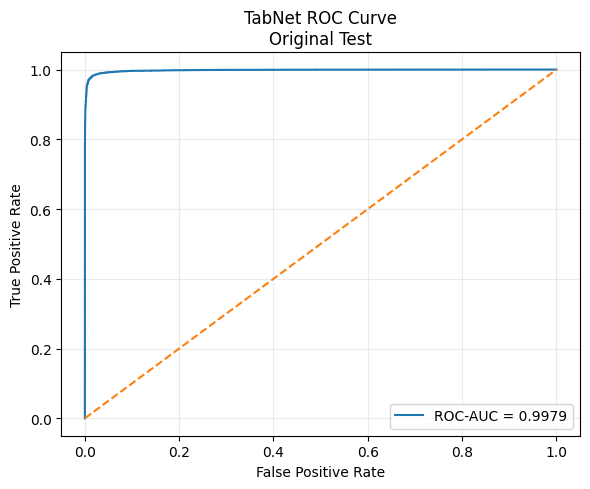

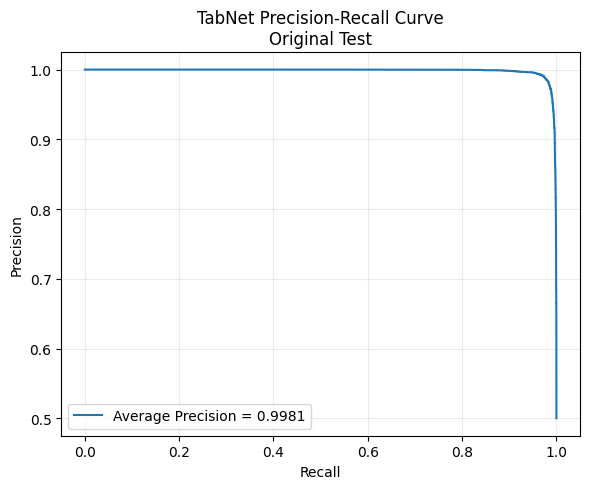

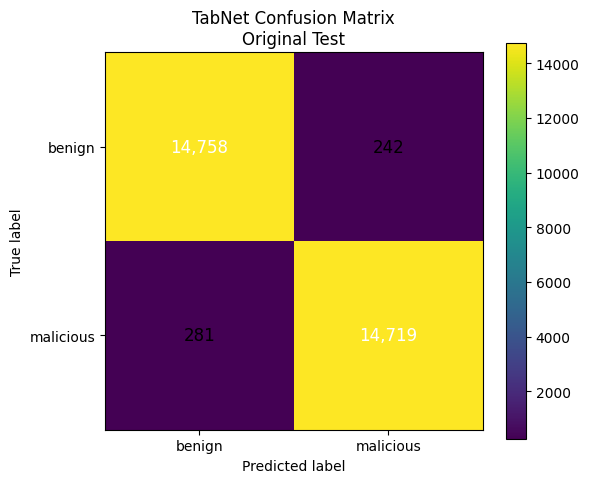


TABNET EVALUATION: ORIGINAL_TEST
Samples: 30,000
Positive class: malicious
Averaging method: binary
ROC-AUC input: continuous probabilities

Confusion matrix:
[[14758   242]
 [  281 14719]]

Metrics:
accuracy              : 0.982567
precision             : 0.983825
recall                : 0.981267
f1_score              : 0.982544
roc_auc               : 0.997937
average_precision     : 0.998146
specificity           : 0.983867

Inference:
Total seconds: 0.949419
Seconds per image: 0.00003165
Images per second: 31598.28


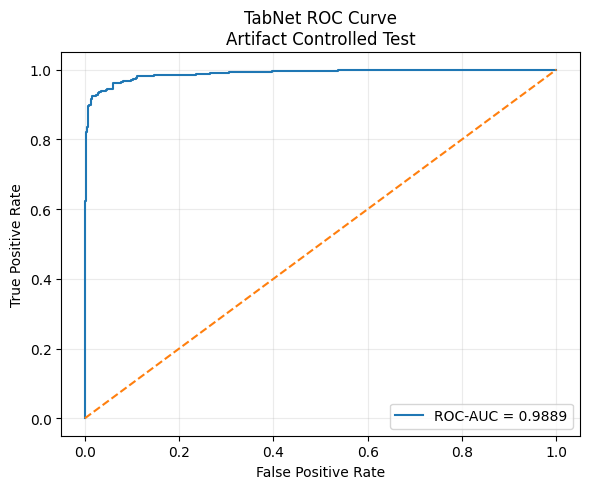

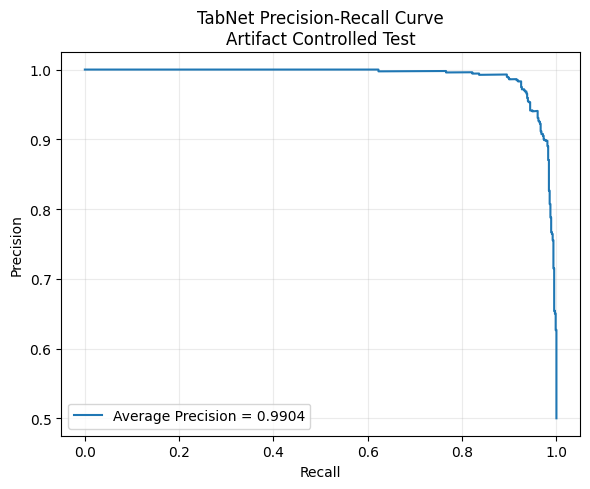

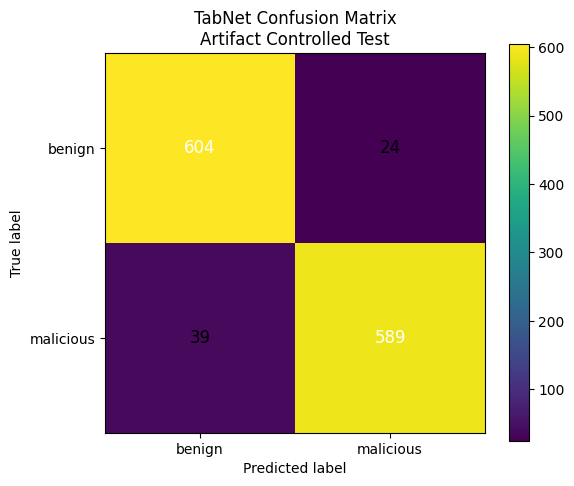


TABNET EVALUATION: ARTIFACT_CONTROLLED_TEST
Samples: 1,256
Positive class: malicious
Averaging method: binary
ROC-AUC input: continuous probabilities

Confusion matrix:
[[604  24]
 [ 39 589]]

Metrics:
accuracy              : 0.949841
precision             : 0.960848
recall                : 0.937898
f1_score              : 0.949234
roc_auc               : 0.988854
average_precision     : 0.990445
specificity           : 0.961783

Inference:
Total seconds: 0.051437
Seconds per image: 0.00004095
Images per second: 24417.99

TABNET ORIGINAL VS ARTIFACT-CONTROLLED COMPARISON


,dataset,samples,accuracy,precision,recall,f1_score,roc_auc,true_negative,false_positive,false_negative,true_positive
0,original_test,30000,0.9826,0.9838,0.9813,0.9825,0.9979,14758,242,281,14719
1,artifact_controlled_test,1256,0.9498,0.9608,0.9379,0.9492,0.9889,604,24,39,589



Controlled-minus-original metric changes:
accuracy              : -0.032726
precision             : -0.022976
recall                : -0.043369
f1_score              : -0.033309
roc_auc               : -0.009084
average_precision     : -0.007701
specificity           : -0.022083

Saved files:
/content/qr_project/results/artifact_controlled_validation/tabnet_reconstructed/final_evaluation/tabnet_original_vs_artifact_controlled_metrics.csv
/content/qr_project/results/artifact_controlled_validation/tabnet_reconstructed/final_evaluation/tabnet_original_vs_artifact_controlled_with_difference.csv
/content/qr_project/results/artifact_controlled_validation/tabnet_reconstructed/final_evaluation/manuscript_tabnet_artifact_validation_table.csv


In [25]:
# ============================================================
# 19) FINAL TABNET EVALUATION ON ORIGINAL AND CONTROLLED TESTS
# ============================================================

try:
    from pytorch_tabnet.tab_model import TabNetClassifier
except ImportError:
    !pip install -q pytorch-tabnet
    from pytorch_tabnet.tab_model import TabNetClassifier

import gc
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score,
#     average_precision_score,
#     specificity_score
#     if False else confusion_matrix,
#     classification_report,
#     roc_curve,
#     precision_recall_curve
#)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
RESULTS_DIR = Path("/content/qr_project/results")

TABNET_ROOT = (
    RESULTS_DIR
    / "artifact_controlled_validation"
    / "tabnet_reconstructed"
)

PREPROCESSED_DIR = (
    TABNET_ROOT
    / "preprocessed_features"
)

PREPROCESSING_DIR = (
    TABNET_ROOT
    / "preprocessing"
)

MODEL_DIR = (
    TABNET_ROOT
    / "models"
)

EVALUATION_DIR = (
    TABNET_ROOT
    / "final_evaluation"
)

PREDICTION_DIR = (
    EVALUATION_DIR
    / "predictions"
)

REPORT_DIR = (
    EVALUATION_DIR
    / "reports"
)

PLOT_DIR = (
    EVALUATION_DIR
    / "plots"
)

for folder in [
    EVALUATION_DIR,
    PREDICTION_DIR,
    REPORT_DIR,
    PLOT_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

TEST_CSV = (
    PREPROCESSED_DIR
    / "test_fused_preprocessed.csv"
)

CONTROLLED_CSV = (
    PREPROCESSED_DIR
    / "artifact_controlled_fused_preprocessed.csv"
)

FEATURES_JSON = (
    PREPROCESSING_DIR
    / "selected_feature_columns.json"
)

MODEL_ZIP_PATH = (
    MODEL_DIR
    / "final_tabnet_fused_classifier.zip"
)

for required_path in [
    TEST_CSV,
    CONTROLLED_CSV,
    FEATURES_JSON,
    MODEL_ZIP_PATH
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required file not found: {required_path}"
        )

# ------------------------------------------------------------
# Load data and selected features
# ------------------------------------------------------------
test_df = pd.read_csv(
    TEST_CSV
)

controlled_df = pd.read_csv(
    CONTROLLED_CSV
)

with open(
    FEATURES_JSON,
    "r",
    encoding="utf-8"
) as file_handle:
    feature_columns = json.load(
        file_handle
    )

X_test = (
    test_df[
        feature_columns
    ]
    .to_numpy(
        dtype=np.float32,
        copy=True
    )
)

y_test = (
    test_df[
        "label_id"
    ]
    .to_numpy(
        dtype=np.int64,
        copy=True
    )
)

X_controlled = (
    controlled_df[
        feature_columns
    ]
    .to_numpy(
        dtype=np.float32,
        copy=True
    )
)

y_controlled = (
    controlled_df[
        "label_id"
    ]
    .to_numpy(
        dtype=np.int64,
        copy=True
    )
)

# ------------------------------------------------------------
# Reload saved TabNet model
# ------------------------------------------------------------
tabnet_model = TabNetClassifier()

tabnet_model.load_model(
    str(MODEL_ZIP_PATH)
)

print("=" * 78)
print("TABNET FINAL EVALUATION SETUP")
print("=" * 78)

print(
    "Loaded model:",
    MODEL_ZIP_PATH
)

print(
    "Feature count:",
    len(feature_columns)
)

print(
    "Original test shape:",
    X_test.shape
)

print(
    "Controlled test shape:",
    X_controlled.shape
)

# ------------------------------------------------------------
# Evaluation function
# ------------------------------------------------------------
def evaluate_tabnet_dataset(
    model,
    X,
    y_true,
    manifest_df,
    dataset_name
):
    start_time = time.perf_counter()

    y_probability = (
        model.predict_proba(X)[:, 1]
        .astype(np.float64)
    )

    y_predicted = (
        y_probability >= 0.5
    ).astype(int)

    inference_seconds = (
        time.perf_counter()
        - start_time
    )

    confusion = confusion_matrix(
        y_true,
        y_predicted,
        labels=[0, 1]
    )

    tn = int(confusion[0, 0])
    fp = int(confusion[0, 1])
    fn = int(confusion[1, 0])
    tp = int(confusion[1, 1])

    accuracy = accuracy_score(
        y_true,
        y_predicted
    )

    precision = precision_score(
        y_true,
        y_predicted,
        pos_label=1,
        average="binary",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_predicted,
        pos_label=1,
        average="binary",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_predicted,
        pos_label=1,
        average="binary",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_probability
    )

    average_precision = (
        average_precision_score(
            y_true,
            y_probability
        )
    )

    specificity = (
        tn
        / max(
            tn + fp,
            1
        )
    )

    # --------------------------------------------------------
    # Save per-sample predictions
    # --------------------------------------------------------
    prediction_df = (
        manifest_df
        .copy()
        .reset_index(drop=True)
    )

    prediction_df[
        "positive_class"
    ] = "malicious"

    prediction_df[
        "decision_threshold"
    ] = 0.5

    prediction_df[
        "malicious_probability"
    ] = y_probability

    prediction_df[
        "predicted_label_id"
    ] = y_predicted

    prediction_df[
        "predicted_label"
    ] = np.where(
        y_predicted == 1,
        "malicious",
        "benign"
    )

    prediction_df[
        "correct_prediction"
    ] = (
        prediction_df["label_id"]
        == prediction_df[
            "predicted_label_id"
        ]
    )

    prediction_path = (
        PREDICTION_DIR
        / f"{dataset_name}_predictions.csv"
    )

    prediction_df.to_csv(
        prediction_path,
        index=False
    )

    # --------------------------------------------------------
    # Classification report
    # --------------------------------------------------------
    report_dict = classification_report(
        y_true,
        y_predicted,
        labels=[0, 1],
        target_names=[
            "benign",
            "malicious"
        ],
        output_dict=True,
        zero_division=0
    )

    report_df = (
        pd.DataFrame(
            report_dict
        )
        .transpose()
        .reset_index()
        .rename(
            columns={
                "index": "class_or_average"
            }
        )
    )

    report_path = (
        REPORT_DIR
        / f"{dataset_name}_classification_report.csv"
    )

    report_df.to_csv(
        report_path,
        index=False
    )

    # --------------------------------------------------------
    # ROC points and plot
    # --------------------------------------------------------
    fpr, tpr, roc_thresholds = roc_curve(
        y_true,
        y_probability,
        pos_label=1
    )

    roc_points_df = pd.DataFrame(
        {
            "false_positive_rate": fpr,
            "true_positive_rate": tpr,
            "threshold": roc_thresholds
        }
    )

    roc_points_path = (
        REPORT_DIR
        / f"{dataset_name}_roc_curve_points.csv"
    )

    roc_points_df.to_csv(
        roc_points_path,
        index=False
    )

    figure = plt.figure(
        figsize=(6, 5)
    )

    axis = figure.add_subplot(111)

    axis.plot(
        fpr,
        tpr,
        label=f"ROC-AUC = {roc_auc:.4f}"
    )

    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    axis.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title=(
            "TabNet ROC Curve\n"
            f"{dataset_name.replace('_', ' ').title()}"
        )
    )

    axis.legend(
        loc="lower right"
    )

    axis.grid(
        alpha=0.25
    )

    figure.tight_layout()

    roc_plot_path = (
        PLOT_DIR
        / f"{dataset_name}_roc_curve.png"
    )

    figure.savefig(
        roc_plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(figure)

    # --------------------------------------------------------
    # PR points and plot
    # --------------------------------------------------------
    pr_precision, pr_recall, pr_thresholds = (
        precision_recall_curve(
            y_true,
            y_probability,
            pos_label=1
        )
    )

    pr_points_df = pd.DataFrame(
        {
            "precision": pr_precision,
            "recall": pr_recall,
            "threshold": np.append(
                pr_thresholds,
                np.nan
            )
        }
    )

    pr_points_path = (
        REPORT_DIR
        / (
            f"{dataset_name}_"
            "precision_recall_curve_points.csv"
        )
    )

    pr_points_df.to_csv(
        pr_points_path,
        index=False
    )

    figure = plt.figure(
        figsize=(6, 5)
    )

    axis = figure.add_subplot(111)

    axis.plot(
        pr_recall,
        pr_precision,
        label=(
            "Average Precision = "
            f"{average_precision:.4f}"
        )
    )

    axis.set(
        xlabel="Recall",
        ylabel="Precision",
        title=(
            "TabNet Precision-Recall Curve\n"
            f"{dataset_name.replace('_', ' ').title()}"
        )
    )

    axis.legend(
        loc="lower left"
    )

    axis.grid(
        alpha=0.25
    )

    figure.tight_layout()

    pr_plot_path = (
        PLOT_DIR
        / (
            f"{dataset_name}_"
            "precision_recall_curve.png"
        )
    )

    figure.savefig(
        pr_plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(figure)

    # --------------------------------------------------------
    # Confusion matrix plot
    # --------------------------------------------------------
    figure = plt.figure(
        figsize=(6, 5)
    )

    axis = figure.add_subplot(111)

    image = axis.imshow(
        confusion,
        interpolation="nearest"
    )

    figure.colorbar(
        image,
        ax=axis
    )

    axis.set(
        xticks=np.arange(2),
        yticks=np.arange(2),
        xticklabels=[
            "benign",
            "malicious"
        ],
        yticklabels=[
            "benign",
            "malicious"
        ],
        xlabel="Predicted label",
        ylabel="True label",
        title=(
            "TabNet Confusion Matrix\n"
            f"{dataset_name.replace('_', ' ').title()}"
        )
    )

    threshold_value = (
        confusion.max() / 2
    )

    for row_index in range(2):
        for column_index in range(2):
            axis.text(
                column_index,
                row_index,
                f"{confusion[row_index, column_index]:,}",
                ha="center",
                va="center",
                color=(
                    "white"
                    if confusion[
                        row_index,
                        column_index
                    ] > threshold_value
                    else "black"
                ),
                fontsize=12
            )

    figure.tight_layout()

    confusion_plot_path = (
        PLOT_DIR
        / f"{dataset_name}_confusion_matrix.png"
    )

    figure.savefig(
        confusion_plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(figure)

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------
    summary = {
        "model": "TabNet",
        "dataset": dataset_name,
        "samples": int(
            len(y_true)
        ),
        "benign_samples": int(
            np.sum(
                y_true == 0
            )
        ),
        "malicious_samples": int(
            np.sum(
                y_true == 1
            )
        ),
        "positive_class": "malicious",
        "averaging_method": "binary",
        "decision_threshold": 0.5,
        "accuracy": float(
            accuracy
        ),
        "precision": float(
            precision
        ),
        "recall": float(
            recall
        ),
        "f1_score": float(
            f1
        ),
        "roc_auc": float(
            roc_auc
        ),
        "average_precision": float(
            average_precision
        ),
        "specificity": float(
            specificity
        ),
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
        "inference_total_seconds": float(
            inference_seconds
        ),
        "inference_seconds_per_image": float(
            inference_seconds
            / len(y_true)
        ),
        "inference_images_per_second": float(
            len(y_true)
            / max(
                inference_seconds,
                1e-12
            )
        ),
        "roc_auc_input": (
            "continuous malicious-class probabilities"
        )
    }

    print("\n" + "=" * 78)
    print(
        f"TABNET EVALUATION: "
        f"{dataset_name.upper()}"
    )
    print("=" * 78)

    print(
        "Samples:",
        f"{len(y_true):,}"
    )

    print(
        "Positive class:",
        "malicious"
    )

    print(
        "Averaging method:",
        "binary"
    )

    print(
        "ROC-AUC input:",
        "continuous probabilities"
    )

    print("\nConfusion matrix:")
    print(confusion)

    print("\nMetrics:")

    for metric_name in [
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "average_precision",
        "specificity"
    ]:
        print(
            f"{metric_name:22s}: "
            f"{summary[metric_name]:.6f}"
        )

    print("\nInference:")

    print(
        "Total seconds:",
        f"{inference_seconds:.6f}"
    )

    print(
        "Seconds per image:",
        f"{summary['inference_seconds_per_image']:.8f}"
    )

    print(
        "Images per second:",
        f"{summary['inference_images_per_second']:.2f}"
    )

    return {
        "summary": summary,
        "predictions": prediction_df,
        "classification_report": report_df,
        "confusion_matrix": confusion,
        "roc_curve": roc_points_df,
        "precision_recall_curve": pr_points_df
    }

# ------------------------------------------------------------
# Evaluate original full test
# ------------------------------------------------------------
original_result = evaluate_tabnet_dataset(
    model=tabnet_model,
    X=X_test,
    y_true=y_test,
    manifest_df=test_df,
    dataset_name="original_test"
)

# ------------------------------------------------------------
# Evaluate strict controlled test
# ------------------------------------------------------------
controlled_result = evaluate_tabnet_dataset(
    model=tabnet_model,
    X=X_controlled,
    y_true=y_controlled,
    manifest_df=controlled_df,
    dataset_name="artifact_controlled_test"
)

# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------
comparison_df = pd.DataFrame(
    [
        original_result[
            "summary"
        ],
        controlled_result[
            "summary"
        ]
    ]
)

metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "average_precision",
    "specificity"
]

difference_row = {
    "model": "TabNet",
    "dataset": (
        "controlled_minus_original"
    ),
    "samples": (
        controlled_result[
            "summary"
        ]["samples"]
        - original_result[
            "summary"
        ]["samples"]
    ),
    "benign_samples": (
        controlled_result[
            "summary"
        ]["benign_samples"]
        - original_result[
            "summary"
        ]["benign_samples"]
    ),
    "malicious_samples": (
        controlled_result[
            "summary"
        ]["malicious_samples"]
        - original_result[
            "summary"
        ]["malicious_samples"]
    ),
    "positive_class": "malicious",
    "averaging_method": "binary",
    "decision_threshold": 0.5
}

for metric_name in metric_columns:
    difference_row[
        metric_name
    ] = (
        controlled_result[
            "summary"
        ][metric_name]
        - original_result[
            "summary"
        ][metric_name]
    )

comparison_with_difference_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame(
            [difference_row]
        )
    ],
    ignore_index=True
)

COMPARISON_CSV = (
    EVALUATION_DIR
    / (
        "tabnet_original_vs_"
        "artifact_controlled_metrics.csv"
    )
)

COMPARISON_WITH_DIFFERENCE_CSV = (
    EVALUATION_DIR
    / (
        "tabnet_original_vs_"
        "artifact_controlled_with_difference.csv"
    )
)

comparison_df.to_csv(
    COMPARISON_CSV,
    index=False
)

comparison_with_difference_df.to_csv(
    COMPARISON_WITH_DIFFERENCE_CSV,
    index=False
)

# ------------------------------------------------------------
# Manuscript-facing table
# ------------------------------------------------------------
manuscript_df = (
    comparison_df[
        [
            "dataset",
            "samples",
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "roc_auc",
            "true_negative",
            "false_positive",
            "false_negative",
            "true_positive"
        ]
    ]
    .copy()
)

for column in [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc"
]:
    manuscript_df[
        column
    ] = manuscript_df[
        column
    ].round(4)

MANUSCRIPT_TABLE_CSV = (
    EVALUATION_DIR
    / (
        "manuscript_tabnet_"
        "artifact_validation_table.csv"
    )
)

manuscript_df.to_csv(
    MANUSCRIPT_TABLE_CSV,
    index=False
)

# ------------------------------------------------------------
# Final report
# ------------------------------------------------------------
print("\n" + "=" * 78)
print(
    "TABNET ORIGINAL VS "
    "ARTIFACT-CONTROLLED COMPARISON"
)
print("=" * 78)

display(
    manuscript_df
)

print(
    "\nControlled-minus-original metric changes:"
)

for metric_name in metric_columns:
    metric_change = (
        controlled_result[
            "summary"
        ][metric_name]
        - original_result[
            "summary"
        ][metric_name]
    )

    print(
        f"{metric_name:22s}: "
        f"{metric_change:+.6f}"
    )

print("\nSaved files:")

print(
    COMPARISON_CSV
)

print(
    COMPARISON_WITH_DIFFERENCE_CSV
)

print(
    MANUSCRIPT_TABLE_CSV
)